# Model overview

Refer to the paper and the [Model Overview](../index.qmd) section for a conceptual overview of the model.

# Detect computing environment

If using Google Colab, mount the drive and set the base directory to the working folder. If using local, set the base directory.

In [1]:
import os       # Operating system utilities
import sys

# Detect environment
def is_colab():
    """Returns True if running in Google Colab, False otherwise."""
    try:
        import google.colab
        return True
    except ImportError:
        return False

# Set up environment-specific configurations
if is_colab():

    # Colab-specific setup
    !pip install rasterio
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/GitHub/deepSSF/Python')

    # for saving plots etc
    base_path = '/content/drive/MyDrive/GitHub/deepSSF'
    print("Running in Google Colab environment")

else:

    # Local environment setup
    base_path = '..'
    print("Running in local environment")

# Now you can use base_path regardless of environment
print(f"Using base path: {base_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab environment
Using base path: /content/drive/MyDrive/GitHub/deepSSF


## Import packages

In [2]:
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import mpmath as mp                                     # Math library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                   # Neural network modules
import os                                               # Operating system utilities
import glob                                             # Pattern matching
import imageio.v2 as imageio                            # Image manipulation - for creating GIFs
from IPython.display import Image, display              # For plotting GIFs
import pandas as pd                                     # Data manipulation
import rasterio                                         # Geospatial raster data

from torch.utils.data import Dataset, DataLoader        # Dataset and batch data loading
from datetime import datetime, timedelta                # Date/time utilities
from rasterio.plot import show                           # Plot raster data

import deepSSF_utils                                    # deepSSF utility functions

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')
print(today_date)

# Set random seed for reproducibility
# seed = 42

3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
2025-05-01


# Select individual and create directory to save model weights and outputs

In [3]:
# select the id to train the model on
buffalo_id = 2005
# in our case the actual dataset will be slightly smaller due to steps being removed that were outside the extent
n_samples = 10297

### Create a directory to save the outputs

If we have already run this code today, we will add update index to create a new folder

In [4]:
# Count existing directories with similar pattern
pattern = f'{base_path}/Python/outputs/model_training/id{buffalo_id}_polar_fcn_mixture_*_{today_date}'
existing_dirs = glob.glob(pattern)
dir_index = len(existing_dirs) + 1

# Create directory with index
output_dir = f'{base_path}/Python/outputs/model_training/id{buffalo_id}_polar_fcn_mixture_{dir_index}_{today_date}'
os.makedirs(output_dir, exist_ok=True)

print(f"Created directory: {output_dir}")

# To use an existing directory for loading trained model
# output_dir = f'{base_path}/Python/outputs/model_training/id2005_polar_fcn_mixture_1_2025-04-28'
# print(f"Using directory: {output_dir}")

Created directory: /content/drive/MyDrive/GitHub/deepSSF/Python/outputs/model_training/id2005_polar_fcn_mixture_7_2025-05-01


## Set paths to data

In [5]:
# Specify the path to CSV file
# csv_file_path = f'{base_path}/buffalo_local_data_id/buffalo_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'
csv_file_path = f'{base_path}/buffalo_local_data_id/buffalo_temporal_cont_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'

# Path to your TIF file
ndvi_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_ndvi_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
canopy_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_canopy_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
herby_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_herby_cent101x101_lag_1hr_n{n_samples}.tif'
# Path to your TIF file
slope_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_slope_cent101x101_lag_1hr_n{n_samples}.tif'

# Path to your TIF file
# pres_path = f'{base_path}/buffalo_local_layers_id/buffalo_{buffalo_id}_pres_cent101x101_lag_1hr_n{n_samples}.tif'
pres_path = f'{base_path}/buffalo_local_layers_id/fixed_buffalo_{buffalo_id}_pres_cent101x101_lag_1hr_n{n_samples}.tif'
# pres_path = f'{base_path}/buffalo_local_layers_id/within_cell_buffalo_{buffalo_id}_pres_cent101x101_lag_1hr_n{n_samples}.tif'

## Read buffalo data

In [6]:
# Read the CSV file into a DataFrame
buffalo_df = pd.read_csv(csv_file_path)
print(buffalo_df.shape)

# Lag the values in column 'A' by one index to get the bearing of the previous step
buffalo_df['bearing_tm1'] = buffalo_df['bearing'].shift(1)
# Pad the missing value with a specified value, e.g., 0
buffalo_df['bearing_tm1'] = buffalo_df['bearing_tm1'].fillna(0)

# Display the first few rows of the DataFrame
# print(buffalo_df.head())

# Add hour_t2 sin and cosine columns
buffalo_df['hour_t2_sin1'] = np.sin(2 * np.pi * (buffalo_df['hour_t2'] / 24))
buffalo_df['hour_t2_cos1'] = np.cos(2 * np.pi * (buffalo_df['hour_t2'] / 24))
buffalo_df['hour_t2_sin2'] = np.sin(4 * np.pi * (buffalo_df['hour_t2'] / 24))
buffalo_df['hour_t2_cos2'] = np.cos(4 * np.pi * (buffalo_df['hour_t2'] / 24))
buffalo_df['hour_t2_sin3'] = np.sin(6 * np.pi * (buffalo_df['hour_t2'] / 24))
buffalo_df['hour_t2_cos3'] = np.cos(6 * np.pi * (buffalo_df['hour_t2'] / 24))

# Show the more interactive DataFrame in Jupyter Notebook
buffalo_df

(10103, 43)


,x_,y_,t_,id,x1_,y1_,x2_,y2_,x2_cent,y2_cent,...,x_max,y_min,y_max,bearing_tm1,hour_t2_sin1,hour_t2_cos1,hour_t2_sin2,hour_t2_cos2,hour_t2_sin3,hour_t2_cos3
0,41969.310875,-1.435671e+06,2018-07-25T01:04:23Z,2005,41969.310875,-1.435671e+06,41921.521939,-1.435654e+06,-47.788936,16.857110,...,43231.810875,-1.436934e+06,-1.434409e+06,0.000000,-0.018325,-0.999832,0.036644,0.999328,-0.054950,-0.998489
1,41921.521939,-1.435654e+06,2018-07-25T02:04:39Z,2005,41921.521939,-1.435654e+06,41779.439594,-1.435601e+06,-142.082345,53.568427,...,43184.021939,-1.436917e+06,-1.434392e+06,2.802478,-0.276476,-0.961021,0.531399,0.847122,-0.744894,-0.667183
2,41779.439594,-1.435601e+06,2018-07-25T03:04:17Z,2005,41779.439594,-1.435601e+06,41841.203272,-1.435635e+06,61.763677,-34.322938,...,43041.939594,-1.436863e+06,-1.434338e+06,2.781049,-0.515786,-0.856718,0.883766,0.467930,-0.998489,0.054950
3,41841.203272,-1.435635e+06,2018-07-25T04:04:39Z,2005,41841.203272,-1.435635e+06,41655.463332,-1.435604e+06,-185.739939,31.003534,...,43103.703272,-1.436898e+06,-1.434373e+06,-0.507220,-0.719946,-0.694030,0.999328,-0.036644,-0.667183,0.744894
4,41655.463332,-1.435604e+06,2018-07-25T05:04:27Z,2005,41655.463332,-1.435604e+06,41618.651923,-1.435608e+06,-36.811409,-4.438037,...,42917.963332,-1.436867e+06,-1.434342e+06,2.976198,-0.875042,-0.484046,0.847122,-0.531399,0.054950,0.998489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10098,42188.462885,-1.436637e+06,2019-10-31T16:55:30Z,2005,42188.462885,-1.436637e+06,42183.410380,-1.436642e+06,-5.052505,-4.882310,...,43450.962885,-1.437900e+06,-1.435375e+06,-2.615171,0.852640,0.522499,0.891007,-0.453990,0.078459,-0.996917
10099,42183.410380,-1.436642e+06,2019-10-31T17:54:32Z,2005,42183.410380,-1.436642e+06,42190.117488,-1.436641e+06,6.707107,1.627287,...,43445.910380,-1.437905e+06,-1.435380e+06,-2.373324,0.960294,0.278991,0.535827,-0.844328,-0.661312,-0.750111
10100,42190.117488,-1.436641e+06,2019-10-31T18:55:36Z,2005,42190.117488,-1.436641e+06,42195.941372,-1.436634e+06,5.823885,6.775817,...,43452.617488,-1.437903e+06,-1.435378e+06,0.238022,0.999781,0.020942,0.041876,-0.999123,-0.998027,-0.062791
10101,42195.941372,-1.436634e+06,2019-10-31T19:55:03Z,2005,42195.941372,-1.436634e+06,42189.368382,-1.436888e+06,-6.572990,-254.371767,...,43458.441372,-1.437896e+06,-1.435371e+06,0.860807,0.972370,-0.233445,-0.453990,-0.891007,-0.760406,0.649448


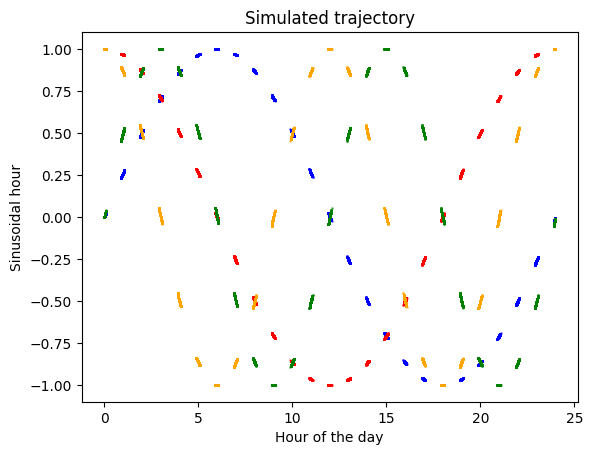

In [7]:
# Plot with jittered x values
plt.scatter(buffalo_df['hour_t2'], buffalo_df['hour_t2_sin1'], c='blue', s=1, alpha=0.5)
plt.scatter(buffalo_df['hour_t2'], buffalo_df['hour_t2_cos1'], c='red', s=1, alpha=0.5)
plt.scatter(buffalo_df['hour_t2'], buffalo_df['hour_t2_sin2'], c='green', s=1, alpha=0.5)
plt.scatter(buffalo_df['hour_t2'], buffalo_df['hour_t2_cos2'], c='orange', s=1, alpha=0.5)
plt.xlabel('Hour of the day')
plt.ylabel('Sinusoidal hour')
plt.title('Simulated trajectory')
plt.show()

# Spatial data

## NDVI

In [8]:
# Using rasterio
with rasterio.open(ndvi_path) as ndvi:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    ndvi_stack = ndvi.read([i for i in range(1, ndvi.count + 1)])

print(ndvi_stack.shape)

(10103, 101, 101)


### Normalise the layers

In [9]:
# Replace NaNs in the original array with -1, which represents water
ndvi_stack = np.nan_to_num(ndvi_stack, nan=-1.0)

# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
ndvi_tens = torch.from_numpy(ndvi_stack)

# Print the shape of the PyTorch tensor
print(ndvi_tens.shape)

# Print the mean, max, and min values of the NDVI tensor
ndvi_mean = torch.mean(ndvi_tens)
ndvi_max = torch.max(ndvi_tens)
ndvi_min = torch.min(ndvi_tens)
print("Mean = ", ndvi_mean)
print("Max = ", ndvi_max)
print("Min = ", ndvi_min)

# Normalizing the data
ndvi_tens_norm = (ndvi_tens - ndvi_min) / (ndvi_max - ndvi_min)
print("Mean = ", torch.mean(ndvi_tens_norm))
print("Max = ", torch.max(ndvi_tens_norm))
print("Min = ", torch.min(ndvi_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.3039)
Max =  tensor(0.8220)
Min =  tensor(-0.2772)
Mean =  tensor(0.5287)
Max =  tensor(1.)
Min =  tensor(0.)


Plot a single NDVI layer

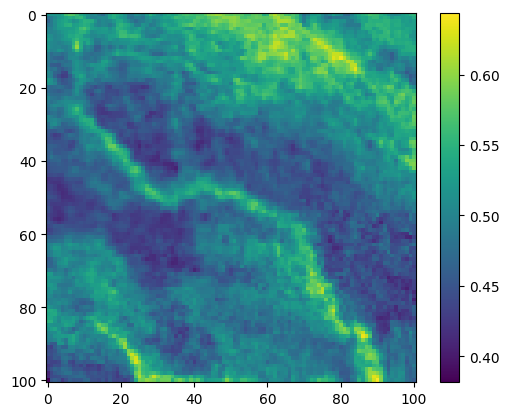

In [10]:
for i in range(0, 1):
    plt.imshow(ndvi_tens_norm[i].numpy())
    plt.colorbar()
    plt.show()

## Canopy cover

In [11]:
# Using rasterio
with rasterio.open(canopy_path) as canopy:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    canopy_stack = canopy.read([i for i in range(1, canopy.count + 1)])

print(canopy_stack.shape)

(10103, 101, 101)


In [12]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
canopy_tens = torch.from_numpy(canopy_stack)
print(canopy_tens.shape)

# Print the mean, max, and min values of the canopy tensor
print("Mean = ", torch.mean(canopy_tens))
canopy_max = torch.max(canopy_tens)
canopy_min = torch.min(canopy_tens)
print("Max = ", canopy_max)
print("Min = ", canopy_min)

# Normalizing the data
canopy_tens_norm = (canopy_tens - canopy_min) / (canopy_max - canopy_min)
print("Mean = ", torch.mean(canopy_tens_norm))
print("Max = ", torch.max(canopy_tens_norm))
print("Min = ", torch.min(canopy_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(44.3548)
Max =  tensor(82.5000)
Min =  tensor(0.)
Mean =  tensor(0.5376)
Max =  tensor(1.)
Min =  tensor(0.)


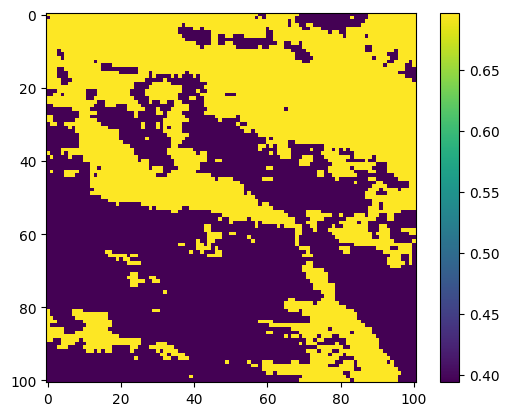

In [13]:
for i in range(0, 1):
    plt.imshow(canopy_tens_norm[i].numpy())
    plt.colorbar()
    plt.show()

## Herbaceous vegetation

In [14]:
# Using rasterio
with rasterio.open(herby_path) as herby:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    herby_stack = herby.read([i for i in range(1, herby.count + 1)])

print(herby_stack.shape)

(10103, 101, 101)


In [15]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
herby_tens = torch.from_numpy(herby_stack)
print(herby_tens.shape)

# Print the mean, max, and min values of the herby tensor
print("Mean = ", torch.mean(herby_tens))
herby_max = torch.max(herby_tens)
herby_min = torch.min(herby_tens)
print("Max = ", herby_max)
print("Min = ", herby_min)

# Normalizing the data
herby_tens_norm = (herby_tens - herby_min) / (herby_max - herby_min)
print("Mean = ", torch.mean(herby_tens_norm))
print("Max = ", torch.max(herby_tens_norm))
print("Min = ", torch.min(herby_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.8069)
Max =  tensor(1.)
Min =  tensor(0.)
Mean =  tensor(0.8069)
Max =  tensor(1.)
Min =  tensor(0.)


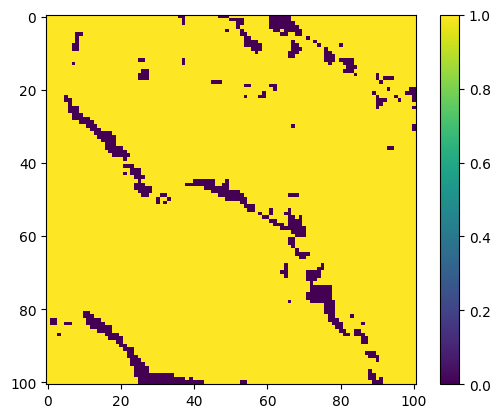

In [16]:
for i in range(0, 1):
    plt.imshow(herby_tens_norm[i])
    plt.colorbar()
    plt.show()

## Slope

In [17]:
# Using rasterio
with rasterio.open(slope_path) as slope:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    slope_stack = slope.read([i for i in range(1, slope.count + 1)])

print(slope_stack.shape)

(10103, 101, 101)


In [18]:
# Convert the numpy array to a PyTorch tensor, which is the format required for training the model
slope_tens = torch.from_numpy(slope_stack)
print(slope_tens.shape)

# Print the mean, max, and min values of the slope tensor
print("Mean = ", torch.mean(slope_tens))
slope_max = torch.max(slope_tens)
slope_min = torch.min(slope_tens)
print("Max = ", slope_max)
print("Min = ", slope_min)

# Normalizing the data
slope_tens_norm = (slope_tens - slope_min) / (slope_max - slope_min)
print("Mean = ", torch.mean(slope_tens_norm))
print("Max = ", torch.max(slope_tens_norm))
print("Min = ", torch.min(slope_tens_norm))

torch.Size([10103, 101, 101])
Mean =  tensor(0.7779)
Max =  tensor(12.2981)
Min =  tensor(0.0006)
Mean =  tensor(0.0632)
Max =  tensor(1.)
Min =  tensor(0.)


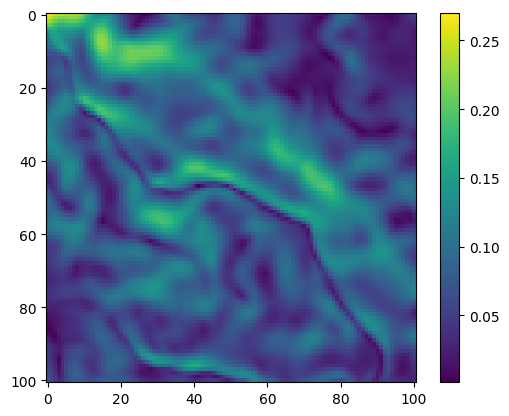

In [19]:
for i in range(0, 1):
    plt.imshow(slope_tens_norm[i])
    plt.colorbar()
    plt.show()

## Presence records - target of model

This is what the model is trying to predict, which is the location of the next step.

In [20]:
# Using rasterio
with rasterio.open(pres_path) as pres:
    # Read all layers/channels into a single numpy array
    # rasterio indexes channels starting from 1, hence the range is 1 to src.count + 1
    pres_stack = pres.read([i for i in range(1, pres.count + 1)])

print(pres_stack.shape)

(10103, 101, 101)


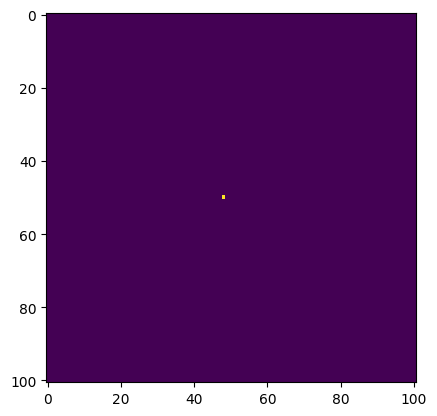

In [21]:
for i in range(0, 1):
    plt.imshow(pres_stack[i])
    plt.show()

In [22]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using {device} device")

Using cuda device


### Combine the spatial layers into channels

In [23]:
# Stack the channels along a new axis; here, 1 is commonly used for the channel axis in PyTorch
combined_stack = torch.stack([ndvi_tens_norm,
                              canopy_tens_norm,
                              herby_tens_norm,
                              slope_tens_norm],
                              dim=1)

print(combined_stack.shape)

torch.Size([10103, 4, 101, 101])


From the size we can see that there are 10103 samples (steps), 4 channels (layers = covariates) and 101x101 pixels.

# Defining data sets and data loaders

### Creating a dataset class

This custom PyTorch Dataset organizes all your input (spatial data, scalar covariates, bearing, and target) in a single object, allowing you to neatly manage how samples are accessed. The `__init__` method prepares and stores all the data, `__len__` returns the total number of samples, and `__getitem__` retrieves a single sample by index—enabling straightforward batching and iteration when used with a DataLoader.


![](../figures/model_diagram_inputs.png)

In [24]:
class buffalo_data(Dataset):

    def __init__(self):
        # data loading. Here we are just using the combined_stack as the spatial covariates
        self.spatial_data_x = combined_stack

        # # the scalar data that will be converted to spatial data and added as channels to the spatial covariates
        # self.scalar_data_x = torch.from_numpy(buffalo_df[['hour_t2_sin',
        #                                                   'hour_t2_cos',
        #                                                   'yday_t2_sin',
        #                                                   'yday_t2_cos']].values).float()

        # the scalar data that will be converted to spatial data and added as channels to the spatial covariates
        self.scalar_data_x = torch.from_numpy(buffalo_df[['hour_t2_sin1',
                                                          'hour_t2_cos1',
                                                          'hour_t2_sin2',
                                                          'hour_t2_cos2']].values).float()

        # # the scalar data that will be converted to spatial data and added as channels to the spatial covariates
        # self.scalar_data_x = torch.from_numpy(buffalo_df[['hour_t2_sin1',
        #                                                   'hour_t2_cos1',
        #                                                   'hour_t2_sin2',
        #                                                   'hour_t2_cos2',
        #                                                   'yday_t2_sin',
        #                                                   'yday_t2_cos']].values).float()

        # the bearing data that will be added as a channel to the spatial covariates
        self.bearing_prev = torch.from_numpy(buffalo_df[['bearing_tm1']].values).float()

        # the target data for habitat - which is a grid with a 1 at the observed next step and 0 elsewhere
        self.habitat_target = torch.tensor(pres_stack)

        # movement targets - step length and turning angle
        self.step_length = torch.from_numpy(buffalo_df[['sl']].values).float()
        self.turn_angle = torch.from_numpy(buffalo_df[['ta']].values).float()

        # number of samples
        self.n_samples = self.spatial_data_x.shape[0]

    def __len__(self):
        # allows for the use of len() function
        return self.n_samples

    def __getitem__(self, index):
        # allows for indexing of the dataset

        # Targets - keep as separate elements
        targets = [
            self.habitat_target[index],
            self.step_length[index],
            self.turn_angle[index]
        ]

        return self.spatial_data_x[index], self.scalar_data_x[index], self.bearing_prev[index], targets

Now we can create an instance of the dataset class and check that is working as expected.

In [25]:
# Create an instance of our custom buffalo_data Dataset:
dataset = buffalo_data()

# Print the total number of samples loaded (determined by n_samples in the dataset):
n_samples_loaded = dataset.n_samples
print(n_samples_loaded)

# Retrieve *all* samples (using the slice dataset[:] invokes __getitem__ on all indices).
# This returns a tuple of (spatial data, scalar-to-grid data, bearing data, target labels).
features1, features2, features3, targets = dataset[:]

# Examine the dimensions of each returned tensor for verification:

# Spatial data
print(features1.shape)
# Scalar-to-grid data
print(features2.shape)
# print(features2[range(10), :])
# Bearing data
print(features3.shape)

# Habitat target
print(targets[0].shape)
# Step length target
print(targets[1].shape)
# Turning angle target
print(targets[2].shape)

10103
torch.Size([10103, 4, 101, 101])
torch.Size([10103, 4])
torch.Size([10103, 1])
torch.Size([10103, 101, 101])
torch.Size([10103, 1])
torch.Size([10103, 1])


### Split into training, validation and test sets

Uncomment either the random split or the sequential split to use the one you prefer. A sequential split requires more of an extrapolation, as the individual could have encountered a different environmental region in the latter part of the time series, or it could be from a different time period, such as part of a season that isn't in the training data.

For testing we will therefore use the sequential split as more of a test for the model.

In [26]:
training_split = 0.8 # 80% of the data will be used for training
validation_split = 0.1 # 10% of the data will be used for validation (deciding when to stop training)
test_split = 0.1 # 10% of the data will be used for testing (model evaluation)

To split the samples randomly we can use the `random_split` function from PyTorch

In [27]:
dataset_train, dataset_val, dataset_test = torch.utils.data.random_split(dataset, [training_split, validation_split, test_split])

To split the data sequentially, we can use the `Subset` function from PyTorch, which allows us to select a subset of the data based on the indices we provide.

In [28]:
# # For sequential split (need integers)
# n_samples = len(dataset)
# n_train = int(training_split * n_samples)
# n_val = int(validation_split * n_samples)
# n_test = n_samples - n_train - n_val  # Ensure they sum to total number of samples

# # Get the start and end indices for each split
# train_end = int(training_split * n_samples)
# val_end = int((training_split + validation_split) * n_samples)

# train_indices = list(range(0, train_end))
# val_indices = list(range(train_end, val_end))
# test_indices = list(range(val_end, len(dataset)))

# # to split the samples sequentially
# dataset_train = torch.utils.data.Subset(dataset, train_indices)
# dataset_val = torch.utils.data.Subset(dataset, val_indices)
# dataset_test = torch.utils.data.Subset(dataset, test_indices)

print("Number of training samples: ",   len(dataset_train))
print("Number of validation samples: ", len(dataset_val))
print("Number of testing samples: ",    len(dataset_test))

Number of training samples:  8083
Number of validation samples:  1010
Number of testing samples:  1010


### Create dataloaders

The DataLoader in PyTorch wraps an iterable around the Dataset to enable easy access to the samples.

In [29]:
# Define the batch size for how many samples to process at once in each step:
batch_size = 32

# Create a DataLoader for the training dataset with a batch size of batch_size, and shuffle samples
# so that the model doesn't see data in the same order each epoch.
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

# Create a DataLoader for the validation dataset, also with a batch size of batch_size and shuffling.
# Even though it's not always mandatory to shuffle validation data, some users keep the same setting.
dataloader_val = DataLoader(dataset=dataset_val,
                            batch_size=batch_size,
                            shuffle=True)

# Create a DataLoader for the test dataset, likewise with a batch size of batch_size and shuffling.
# As we want to index the testing data for plotting, we will not shuffle the test data.
dataloader_test = DataLoader(dataset=dataset_test,
                             batch_size=batch_size,
                             shuffle=False)


Check that the data loader is working as expected.

In [30]:
# Display image and label.
# next(iter(dataloader_train)) returns the next batch of the training data
features1, features2, features3, labels = next(iter(dataloader_train))
print(f"Feature 1 batch shape:              {features1.size()}")
print(f"Feature 2 batch shape:              {features2.size()}")
print(f"Feature 3 batch shape:              {features3.size()}")

habitat_target, step_length_target, turn_angle_target = labels
print(f"Habitat target batch shape:         {habitat_target.size()}")
print(f"Step length target batch shape:     {step_length_target.size()}")
print(f"Turn angle target batch shape:      {turn_angle_target.size()}")

Feature 1 batch shape:              torch.Size([32, 4, 101, 101])
Feature 2 batch shape:              torch.Size([32, 4])
Feature 3 batch shape:              torch.Size([32, 1])
Habitat target batch shape:         torch.Size([32, 101, 101])
Step length target batch shape:     torch.Size([32, 1])
Turn angle target batch shape:      torch.Size([32, 1])


# Define the model

Deep learning can be considered as a sequence of **blocks**, each of which perform some (typically nonlinear) transformation on input data to produce some output. Providing each block has the appropriate inputs, they can be combined to build a larger network that is capable of achieving complex and abstract transformations and can be used to represent complex processes.

A block is modular component of a neural network, in our case defined as a Python class (type of object with certain functionality described by its definition) inheriting from `torch.nn.Module` in PyTorch. A block encapsulates a sequence of operations, including layers (such as fully connected layers or convolutional layers) and activation functions, to process input data. Each block has a forward method (i.e. instructions) that defines the data flow through the network during inference or training.

## Convolutional block for the habitat selection subnetwork

This block is a convolutional layer that takes in the spatial covariates (including the layers created from the scalar values such as time), goes through a series of convolution operations and ReLU activation functions and outputs a feature map, which is the habitat selection probability surface.

![](../figures/model_diagram_hab.png){width=50%}

In [31]:
class Conv2d_block_spatial(nn.Module):
    def __init__(self, params):
        super(Conv2d_block_spatial, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.input_channels = params.input_channels
        self.output_channels = params.output_channels
        self.kernel_size = params.kernel_size
        self.stride = params.stride
        self.padding = params.padding
        self.image_dim = params.image_dim
        self.device = params.device

        # define the layers - nn.Sequential allows for the definition of layers in a sequential manner
        self.conv2d = nn.Sequential(

        # convolutional layer 1
        nn.Conv2d(in_channels=self.input_channels,
                  out_channels=self.output_channels,
                  kernel_size=self.kernel_size,
                  stride=self.stride,
                  padding=self.padding),
        # ReLU activation function
        nn.ReLU(),

        # convolutional layer 2
        nn.Conv2d(in_channels=self.output_channels,
                  out_channels=self.output_channels,
                  kernel_size=self.kernel_size,
                  stride=self.stride,
                  padding=self.padding),
        # ReLU activation function
        nn.ReLU(),

        # convolutional layer 3, which outputs a single layer, which is the habitat selection map
        nn.Conv2d(in_channels=self.output_channels,
                  out_channels=1,
                  kernel_size=self.kernel_size,
                  stride=self.stride,
                  padding=self.padding)
        )

    # define the forward pass of the model, i.e. how the data flows through the model
    def forward(self, x):

        # self.conv2d(x) passes the input through the convolutional layers, and the squeeze function removes the channel dimension, resulting in a 2D tensor (habitat selection map)
        # print("Shape before squeeze:", self.conv2d(x).shape) # Debugging print
        conv2d_spatial = self.conv2d(x).squeeze(dim = 1)

        # normalise to sum to 1
        # print("Shape before logsumexp:", conv2d_spatial.shape) # Debugging print
        conv2d_spatial = conv2d_spatial - torch.logsumexp(conv2d_spatial, dim = (1, 2), keepdim = True)

        # output the habitat selection map
        return conv2d_spatial


## Convolutional block for the movement subnetwork

This block is also convolutional layer, with the same inputs, but this block also has max pooling layers to reduce the spatial resolution of the feature maps whilst preserving the most prominent features in the feature maps, and outputs a 'flattened' feature map. A flattened feature map is a 1D tensor (a vector) that can be used as input to a fully connected layer.

![](../figures/model_diagram_move.png)

In [32]:
class Conv2d_block_toFC(nn.Module):
    def __init__(self, params):
        super(Conv2d_block_toFC, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.input_channels = params.input_channels
        self.output_channels = params.output_channels
        self.kernel_size = params.kernel_size
        self.stride = params.stride
        self.kernel_size_mp = params.kernel_size_mp
        self.stride_mp = params.stride_mp
        self.padding = params.padding
        self.image_dim = params.image_dim
        self.device = params.device

        # define the layers - nn.Sequential allows for the definition of layers in a sequential manner
        self.conv2d = nn.Sequential(

        # convolutional layer 1
        nn.Conv2d(in_channels=self.input_channels,
                  out_channels=self.output_channels,
                  kernel_size=self.kernel_size,
                  stride=self.stride,
                  padding=self.padding),
        # ReLU activation function
        nn.ReLU(),

        # max pooling layer 1 (reduces the spatial dimensions of the data whilst retaining the most important features)
        nn.MaxPool2d(kernel_size=self.kernel_size_mp,
                     stride=self.stride_mp),

        # convolutional layer 2
        nn.Conv2d(in_channels=self.output_channels,
                  out_channels=self.output_channels,
                  kernel_size=self.kernel_size,
                  stride=self.stride,
                  padding=self.padding),
        # ReLU activation function
        nn.ReLU(),

        # max pooling layer 2
        nn.MaxPool2d(kernel_size=self.kernel_size_mp,
                     stride=self.stride_mp),

        # flatten the data to pass through the fully connected layer
        nn.Flatten())

    def forward(self, x):

        # self.conv2d(x) passes the input through the convolutional layers, and outputs a 1D tensor
        return self.conv2d(x)


## Fully connected block for the movement subnetwork

This block takes in the flattened feature map from the previous block, passes through several fully connected layers, which extracts information from the spatial covariates that is relevant for movement, and outputs the parameters that define the movement kernel.

In [110]:
class FCN_block_all_movement(nn.Module):
    def __init__(self, params):
        super(FCN_block_all_movement, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.dense_dim_in_all = params.dense_dim_in_all
        self.dense_dim_hidden = params.dense_dim_hidden
        self.image_dim = params.image_dim
        self.device = params.device
        self.num_movement_params = params.num_movement_params
        self.dropout = params.dropout

        # define the layers - nn.Sequential allows for the definition of layers in a sequential manner
        self.ffn = nn.Sequential(

            # fully connected layer 1 (the dense_dim_in_all is the number of input features,
            # and should match the output of the Conv2d_block_toFC block).
            # the dense_dim_hidden is the number of neurons in the hidden layer, and doesn't need to be the same as the input features
            nn.Linear(self.dense_dim_in_all, self.dense_dim_hidden),
            # dropout layer (helps to reduce overfitting)
            nn.Dropout(self.dropout),
            # ReLU activation function
            nn.ReLU(),

            # fully connected layer 2
            # the number of input neurons should match the output from the previous layer
            nn.Linear(self.dense_dim_hidden, self.dense_dim_hidden),
            # dropout layer
            nn.Dropout(self.dropout),
            # ReLU activation function
            nn.ReLU(),

            # fully connected layer 3
            # the number of input neurons should match the output from the previous layer
            nn.Linear(self.dense_dim_hidden, self.dense_dim_hidden),
            # dropout layer
            nn.Dropout(self.dropout),
            # ReLU activation function
            nn.ReLU(),

            # # fully connected layer 4
            # # the number of input neurons should match the output from the previous layer
            # nn.Linear(self.dense_dim_hidden, self.dense_dim_hidden),
            # # dropout layer
            # nn.Dropout(self.dropout),
            # # ReLU activation function
            # nn.ReLU(),

            # # fully connected layer 5
            # # the number of input neurons should match the output from the previous layer
            # nn.Linear(self.dense_dim_hidden, self.dense_dim_hidden),
            # # dropout layer
            # nn.Dropout(self.dropout),
            # # ReLU activation function
            # nn.ReLU(),

            # fully connected layer 6
            # the number of input neurons should match the output from the previous layer,
            # and the number of output neurons should match the number of movement parameters
            nn.Linear(self.dense_dim_hidden, self.num_movement_params)

            # # For linear model ONLY
            # nn.Linear(self.dense_dim_in_all, self.num_movement_params)

        )

    def forward(self, x):

        # self.ffn(x) passes the input through the fully connected layers, and outputs a 1D tensor (vector of movement parameters)
        return self.ffn(x)


## Block to convert the movement parameters to a probability distribution

### What the block does

This block is a bit longer and more involved, but there are no parameters in here that need to be learned (estimated). It is just a series of operations that are applied to the movement parameters to convert them to a probability distribution.

This block takes in the movement parameters and converts them to a probability distribution. This essentially just applies the appropriate density functions using the parameter values predicted by the movement blocks, which in our case is a finite mixture of Gamma distributions and a finite mixture of von Mises distributions.

The formulation of predicting parameters and converting them to a movement kernel ensures that the movement kernel is very flexible, and can be any combination of distributions, which need not all be the same (e.g., a step length distribution may be combination of a Gamma and a log-normal distribution).

### Constraints

One constraint to ensure that we can perform backpropagation is that the entire forward pass, including the block below that produces the density functions, must be differentiable with respect to the parameters of the model. PyTorch’s torch.distributions module and its special functions (e.g., torch.special) provide differentiable implementations for many common distributions. Examples are the

- Gamma function for the (log) Gamma distribution, `torch.lgamma()`
- The modified Bessel function of the first kind of order 0 for the von Mises distribution, `torch.special.i0()`

Some of the movement parameters, such as the shape and scale of the Gamma distribution, must be positive. We therefore exponentiate them in this block to ensure that they are positive. This means that the model is actually learning the log of the shape and scale parameters. For the von Mises `mu` parameters however, they can be any value, so we do not need to exponentiate them. We could constrain them to be between -pi and pi, but this is not necessary as the von Mises distribution is periodic, so any value will be equivalent to another value that is within the range -pi to pi.

### Notes

To help with identifiability, it is possible to fix certain parameter values, such as the mu parameters in the mixture of von Mises distributions to pi and -pi for instance (one would then reduce the number of predicted parameters by the previous block, as these no longer need to be predicted).

We can also transform certain parameters such that they are being estimated in a similar range (analagous to standardising variables in linear regression). In our case we know that the scale parameter of one of the Gamma distributions is around 500. What we can then do after exponentiating is multiply the scale parameter by 500, so the model is learning the log of the scale parameter divided by 500. This will ensure that this parameter is in a similar range to the other parameters, and can help with convergence. To do this we:

Pull out the relevant parameters from the input tensor (output of previous block)
- `gamma_scale2 = torch.exp(x[:, 4]).unsqueeze(0).unsqueeze(0)`

Multiply the scale parameter by 500, so the model is learning the log of the scale parameter divided by 500
- `gamma_scale2 = gamma_scale2 * 500`

### Consideration for the centre cell

As the centre cell has a distance of exactly 0 (using the distance layer we created), this can cause numerical issues for the gamma distribution, as when the shape parameter is less than one the mode approaches infinity. To avoid this, we can add a small value to the central cell of the distance layer, so that the distance is never exactly 0.

To get the value to use in the central cell, we will calculate the average distance from the very centre to any point in the cell (assuming that the distance within the cell is continuous). This comes out to be:

$\int_{-0.5}^{0.5} \int_{-0.5}^{0.5} \sqrt{x^2 + y^2} \, dx \, dy$

We calculate a constant numerically below:

In [34]:
def integrand(x, y):
    return mp.sqrt(x**2 + y**2)

val = mp.quad(lambda Y:
              mp.quad(lambda X: integrand(X, Y),
                      [-0.5, 0.5]),
                      [-0.5, 0.5])

print(val)

0.382597668656132


In [35]:
class Params_to_Grid_Block(nn.Module):
    def __init__(self, params):
        super(Params_to_Grid_Block, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.image_dim = params.image_dim
        self.pixel_size = params.pixel_size

        # create distance and bearing layers
        # determine the distance of each pixel from the centre of the image
        self.center = self.image_dim // 2
        y, x = np.indices((self.image_dim, self.image_dim))
        self.distance_layer = torch.from_numpy(np.sqrt((self.pixel_size*(x - self.center))**2 +
                                                       (self.pixel_size*(y - self.center))**2))
        # change the centre cell to the average distance from the centre to the edge of the pixel

        # average distance from the centre to the perimeter of the pixel (accounting for longer distances at the corners)
        # self.distance_layer[self.center, self.center] = 0.56*self.pixel_size

        # average distance from the centre to any point within the pixel
        # calculated as a double integral of sqrt(x^2 + y^2) dx dy over the area of the pixel
        self.distance_layer[self.center, self.center] = 0.3826*self.pixel_size

        # determine the bearing of each pixel from the centre of the image
        self.bearing_layer = torch.from_numpy(np.arctan2(self.center - y,
                                                         x - self.center))
        self.device = params.device


    # Gamma densities (on the log-scale) for the mixture distribution
    def gamma_density(self, x, shape, scale):
        # Ensure all tensors are on the same device as x
        shape = shape.to(x.device)
        scale = scale.to(x.device)
        return -1*torch.lgamma(shape) -shape*torch.log(scale) + (shape - 1)*torch.log(x) - x/scale

        # to account for change of variables
        # return (-1*torch.lgamma(shape) -shape*torch.log(scale) + (shape - 1)*torch.log(x) - x/scale) - torch.log(x)

    # log von Mises densities (on the log-scale) for the mixture distribution
    def vonmises_density(self, x, kappa, vm_mu):
        # Ensure all tensors are on the same device as x
        kappa = kappa.to(x.device)
        vm_mu = vm_mu.to(x.device)
        return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


    def forward(self, x, bearing):

        # parameters of the first mixture distribution
        # x are the outputs from the fully connected layers (vector of movement parameters)
        # we therefore need to extract the appropriate parameters
        # the locations are not specific to any specific parameters, as long as any aren't extracted more than once

        # Gamma distributions

        # pull out the parameters of the first gamma distribution and exponentiate them to ensure they are positive
        # the unsqueeze function adds a new dimension to the tensor
        # we do this twice to match the dimensions of the distance_layer,
        # and then repeat the parameter value across a grid, such that the density can be calculated at every cell/pixel
        gamma_shape1 = torch.exp(x[:, 0]).unsqueeze(0).unsqueeze(0)
        gamma_shape1 = gamma_shape1.repeat(self.image_dim, self.image_dim, 1)
        # this just changes the order of the dimensions to match the distance_layer
        gamma_shape1 = gamma_shape1.permute(2, 0, 1)

        gamma_scale1 = torch.exp(x[:, 1]).unsqueeze(0).unsqueeze(0)
        gamma_scale1 = gamma_scale1.repeat(self.image_dim, self.image_dim, 1)
        gamma_scale1 = gamma_scale1.permute(2, 0, 1)

        # gamma_weight1 = torch.exp(x[:, 2]).unsqueeze(0).unsqueeze(0)
        gamma_weight1 = x[:, 2].unsqueeze(0).unsqueeze(0)
        gamma_weight1 = gamma_weight1.repeat(self.image_dim, self.image_dim, 1)
        gamma_weight1 = gamma_weight1.permute(2, 0, 1)

        # parameters of the second mixture distribution
        gamma_shape2 = torch.exp(x[:, 3]).unsqueeze(0).unsqueeze(0)
        gamma_shape2 = gamma_shape2.repeat(self.image_dim, self.image_dim, 1)
        gamma_shape2 = gamma_shape2.permute(2, 0, 1)

        gamma_scale2 = torch.exp(x[:, 4]).unsqueeze(0).unsqueeze(0)
        gamma_scale2 = gamma_scale2 * 500 ### transform the scale parameter so it can be estimated near the same range as the other parameters
        gamma_scale2 = gamma_scale2.repeat(self.image_dim, self.image_dim, 1)
        gamma_scale2 = gamma_scale2.permute(2, 0, 1)

        # gamma_weight2 = torch.exp(x[:, 5]).unsqueeze(0).unsqueeze(0)
        gamma_weight2 = x[:, 5].unsqueeze(0).unsqueeze(0)
        gamma_weight2 = gamma_weight2.repeat(self.image_dim, self.image_dim, 1)
        gamma_weight2 = gamma_weight2.permute(2, 0, 1)

        # Apply softmax to the mixture weights to ensure they sum to 1
        gamma_weights = torch.stack([gamma_weight1, gamma_weight2], dim=0)
        gamma_weights = torch.nn.functional.softmax(gamma_weights, dim=0)
        gamma_weight1 = gamma_weights[0]
        gamma_weight2 = gamma_weights[1]

        # calculation of Gamma densities
        gamma_density_layer1 = self.gamma_density(self.distance_layer,
                                                  gamma_shape1,
                                                  gamma_scale1).to(device)

        gamma_density_layer2 = self.gamma_density(self.distance_layer,
                                                  gamma_shape2,
                                                  gamma_scale2).to(device)

        # combining both densities to create a mixture distribution using logsumexp
        logsumexp_gamma_corr = torch.max(gamma_density_layer1, gamma_density_layer2)
        gamma_density_layer = logsumexp_gamma_corr + torch.log(gamma_weight1 * torch.exp(gamma_density_layer1 - logsumexp_gamma_corr) +
                                                               gamma_weight2 * torch.exp(gamma_density_layer2 - logsumexp_gamma_corr))
        # print(torch.sum(gamma_density_layer))
        # print(torch.sum(torch.exp(gamma_density_layer)))


        ## Von Mises Distributions

        # calculate the new bearing from the turning angle
        # takes in the bearing from the previous step and adds the turning angle, which is estimated by the model
        # we do not exponentiate the von Mises mu parameters as we want to allow them to be negative
        bearing_new1 = x[:, 6] + bearing[:, 0]

        # the new bearing becomes the mean of the von Mises distribution
        vonmises_mu1 = bearing_new1.unsqueeze(0).unsqueeze(0)
        vonmises_mu1 = vonmises_mu1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_mu1 = vonmises_mu1.permute(2, 0, 1)

        # parameters of the first von Mises distribution
        vonmises_kappa1 = torch.exp(x[:, 7]).unsqueeze(0).unsqueeze(0)
        vonmises_kappa1 = vonmises_kappa1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_kappa1 = vonmises_kappa1.permute(2, 0, 1)

        # vonmises_weight1 = torch.exp(x[:, 8]).unsqueeze(0).unsqueeze(0)
        vonmises_weight1 = x[:, 8].unsqueeze(0).unsqueeze(0)
        vonmises_weight1 = vonmises_weight1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_weight1 = vonmises_weight1.permute(2, 0, 1)

        # vm_mu and weight for the second von Mises distribution
        bearing_new2 = x[:, 9] + bearing[:, 0]

        vonmises_mu2 = bearing_new2.unsqueeze(0).unsqueeze(0)
        vonmises_mu2 = vonmises_mu2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_mu2 = vonmises_mu2.permute(2, 0, 1)

        # parameters of the second von Mises distribution
        vonmises_kappa2 = torch.exp(x[:, 10]).unsqueeze(0).unsqueeze(0)
        vonmises_kappa2 = vonmises_kappa2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_kappa2 = vonmises_kappa2.permute(2, 0, 1)

        # vonmises_weight2 = torch.exp(x[:, 11]).unsqueeze(0).unsqueeze(0)
        vonmises_weight2 = x[:, 11].unsqueeze(0).unsqueeze(0)
        vonmises_weight2 = vonmises_weight2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_weight2 = vonmises_weight2.permute(2, 0, 1)

        # Apply softmax to the weights
        vonmises_weights = torch.stack([vonmises_weight1, vonmises_weight2], dim=0)
        vonmises_weights = torch.nn.functional.softmax(vonmises_weights, dim=0)
        vonmises_weight1 = vonmises_weights[0]
        vonmises_weight2 = vonmises_weights[1]

        # calculation of von Mises densities
        vonmises_density_layer1 = self.vonmises_density(self.bearing_layer,
                                                        vonmises_kappa1,
                                                        vonmises_mu1).to(device)

        vonmises_density_layer2 = self.vonmises_density(self.bearing_layer,
                                                        vonmises_kappa2,
                                                        vonmises_mu2).to(device)

        # combining both densities to create a mixture distribution using the logsumexp trick
        logsumexp_vm_corr = torch.max(vonmises_density_layer1, vonmises_density_layer2)
        vonmises_density_layer = logsumexp_vm_corr + torch.log(vonmises_weight1 * torch.exp(vonmises_density_layer1 - logsumexp_vm_corr) +
                                                               vonmises_weight2 * torch.exp(vonmises_density_layer2 - logsumexp_vm_corr))
        # print(torch.sum(vonmises_density_layer))
        # print(torch.sum(torch.exp(vonmises_density_layer)))

        # combining the two distributions
        movement_grid = gamma_density_layer + vonmises_density_layer # Gamma and von Mises densities are on the log-scale

        # normalise (on the log-scale using the log-sum-exp trick) before combining with the habitat predictions
        movement_grid = movement_grid - torch.logsumexp(movement_grid, dim = (1, 2), keepdim = True)
        # print('Movement grid norm ', torch.sum(movement_grid))
        # print(torch.sum(torch.exp(movement_grid)))

        return movement_grid


Duplicate the Params_to_Grid_Block to have another that accounts for the change of variables, making it easier to select between the two depending on what is needed.

In [36]:
class Params_to_Grid_Block_ChV(nn.Module):
    def __init__(self, params):
        super(Params_to_Grid_Block_ChV, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.image_dim = params.image_dim
        self.pixel_size = params.pixel_size

        # create distance and bearing layers
        # determine the distance of each pixel from the centre of the image
        self.center = self.image_dim // 2
        y, x = np.indices((self.image_dim, self.image_dim))
        self.distance_layer = torch.from_numpy(np.sqrt((self.pixel_size*(x - self.center))**2 +
                                                       (self.pixel_size*(y - self.center))**2))
        # change the centre cell to the average distance from the centre to the edge of the pixel

        # average distance from the centre to the perimeter of the pixel (accounting for longer distances at the corners)
        # self.distance_layer[self.center, self.center] = 0.56*self.pixel_size

        # average distance from the centre to any point within the pixel
        # calculated as a double integral of sqrt(x^2 + y^2) dx dy over the area of the pixel
        self.distance_layer[self.center, self.center] = 0.3826*self.pixel_size

        # determine the bearing of each pixel from the centre of the image
        self.bearing_layer = torch.from_numpy(np.arctan2(self.center - y,
                                                         x - self.center))
        self.device = params.device


    # Gamma densities (on the log-scale) for the mixture distribution
    def gamma_density(self, x, shape, scale):
        # Ensure all tensors are on the same device as x
        shape = shape.to(x.device)
        scale = scale.to(x.device)
        # return -1*torch.lgamma(shape) -shape*torch.log(scale) + (shape - 1)*torch.log(x) - x/scale

        # to account for change of variables
        return (-1*torch.lgamma(shape) -shape*torch.log(scale) + (shape - 1)*torch.log(x) - x/scale) - torch.log(x)

    # log von Mises densities (on the log-scale) for the mixture distribution
    def vonmises_density(self, x, kappa, vm_mu):
        # Ensure all tensors are on the same device as x
        kappa = kappa.to(x.device)
        vm_mu = vm_mu.to(x.device)
        return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


    def forward(self, x, bearing):

        # parameters of the first mixture distribution
        # x are the outputs from the fully connected layers (vector of movement parameters)
        # we therefore need to extract the appropriate parameters
        # the locations are not specific to any specific parameters, as long as any aren't extracted more than once

        # Gamma distributions

        # pull out the parameters of the first gamma distribution and exponentiate them to ensure they are positive
        # the unsqueeze function adds a new dimension to the tensor
        # we do this twice to match the dimensions of the distance_layer,
        # and then repeat the parameter value across a grid, such that the density can be calculated at every cell/pixel
        gamma_shape1 = torch.exp(x[:, 0]).unsqueeze(0).unsqueeze(0)
        gamma_shape1 = gamma_shape1.repeat(self.image_dim, self.image_dim, 1)
        # this just changes the order of the dimensions to match the distance_layer
        gamma_shape1 = gamma_shape1.permute(2, 0, 1)

        gamma_scale1 = torch.exp(x[:, 1]).unsqueeze(0).unsqueeze(0)
        gamma_scale1 = gamma_scale1.repeat(self.image_dim, self.image_dim, 1)
        gamma_scale1 = gamma_scale1.permute(2, 0, 1)

        # gamma_weight1 = torch.exp(x[:, 2]).unsqueeze(0).unsqueeze(0)
        gamma_weight1 = x[:, 2].unsqueeze(0).unsqueeze(0)
        gamma_weight1 = gamma_weight1.repeat(self.image_dim, self.image_dim, 1)
        gamma_weight1 = gamma_weight1.permute(2, 0, 1)

        # parameters of the second mixture distribution
        gamma_shape2 = torch.exp(x[:, 3]).unsqueeze(0).unsqueeze(0)
        gamma_shape2 = gamma_shape2.repeat(self.image_dim, self.image_dim, 1)
        gamma_shape2 = gamma_shape2.permute(2, 0, 1)

        gamma_scale2 = torch.exp(x[:, 4]).unsqueeze(0).unsqueeze(0)
        gamma_scale2 = gamma_scale2 * 500 ### transform the scale parameter so it can be estimated near the same range as the other parameters
        gamma_scale2 = gamma_scale2.repeat(self.image_dim, self.image_dim, 1)
        gamma_scale2 = gamma_scale2.permute(2, 0, 1)

        # gamma_weight2 = torch.exp(x[:, 5]).unsqueeze(0).unsqueeze(0)
        gamma_weight2 = x[:, 5].unsqueeze(0).unsqueeze(0)
        gamma_weight2 = gamma_weight2.repeat(self.image_dim, self.image_dim, 1)
        gamma_weight2 = gamma_weight2.permute(2, 0, 1)

        # Apply softmax to the mixture weights to ensure they sum to 1
        gamma_weights = torch.stack([gamma_weight1, gamma_weight2], dim=0)
        gamma_weights = torch.nn.functional.softmax(gamma_weights, dim=0)
        gamma_weight1 = gamma_weights[0]
        gamma_weight2 = gamma_weights[1]

        # calculation of Gamma densities
        gamma_density_layer1 = self.gamma_density(self.distance_layer,
                                                  gamma_shape1,
                                                  gamma_scale1).to(device)

        gamma_density_layer2 = self.gamma_density(self.distance_layer,
                                                  gamma_shape2,
                                                  gamma_scale2).to(device)

        # combining both densities to create a mixture distribution using logsumexp
        logsumexp_gamma_corr = torch.max(gamma_density_layer1, gamma_density_layer2)
        gamma_density_layer = logsumexp_gamma_corr + torch.log(gamma_weight1 * torch.exp(gamma_density_layer1 - logsumexp_gamma_corr) +
                                                               gamma_weight2 * torch.exp(gamma_density_layer2 - logsumexp_gamma_corr))
        # print(torch.sum(gamma_density_layer))
        # print(torch.sum(torch.exp(gamma_density_layer)))


        ## Von Mises Distributions

        # calculate the new bearing from the turning angle
        # takes in the bearing from the previous step and adds the turning angle, which is estimated by the model
        # we do not exponentiate the von Mises mu parameters as we want to allow them to be negative
        bearing_new1 = x[:, 6] + bearing[:, 0]

        # the new bearing becomes the mean of the von Mises distribution
        vonmises_mu1 = bearing_new1.unsqueeze(0).unsqueeze(0)
        vonmises_mu1 = vonmises_mu1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_mu1 = vonmises_mu1.permute(2, 0, 1)

        # parameters of the first von Mises distribution
        vonmises_kappa1 = torch.exp(x[:, 7]).unsqueeze(0).unsqueeze(0)
        vonmises_kappa1 = vonmises_kappa1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_kappa1 = vonmises_kappa1.permute(2, 0, 1)

        # vonmises_weight1 = torch.exp(x[:, 8]).unsqueeze(0).unsqueeze(0)
        vonmises_weight1 = x[:, 8].unsqueeze(0).unsqueeze(0)
        vonmises_weight1 = vonmises_weight1.repeat(self.image_dim, self.image_dim, 1)
        vonmises_weight1 = vonmises_weight1.permute(2, 0, 1)

        # vm_mu and weight for the second von Mises distribution
        bearing_new2 = x[:, 9] + bearing[:, 0]

        vonmises_mu2 = bearing_new2.unsqueeze(0).unsqueeze(0)
        vonmises_mu2 = vonmises_mu2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_mu2 = vonmises_mu2.permute(2, 0, 1)

        # parameters of the second von Mises distribution
        vonmises_kappa2 = torch.exp(x[:, 10]).unsqueeze(0).unsqueeze(0)
        vonmises_kappa2 = vonmises_kappa2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_kappa2 = vonmises_kappa2.permute(2, 0, 1)

        # vonmises_weight2 = torch.exp(x[:, 11]).unsqueeze(0).unsqueeze(0)
        vonmises_weight2 = x[:, 11].unsqueeze(0).unsqueeze(0)
        vonmises_weight2 = vonmises_weight2.repeat(self.image_dim, self.image_dim, 1)
        vonmises_weight2 = vonmises_weight2.permute(2, 0, 1)

        # Apply softmax to the weights
        vonmises_weights = torch.stack([vonmises_weight1, vonmises_weight2], dim=0)
        vonmises_weights = torch.nn.functional.softmax(vonmises_weights, dim=0)
        vonmises_weight1 = vonmises_weights[0]
        vonmises_weight2 = vonmises_weights[1]

        # calculation of von Mises densities
        vonmises_density_layer1 = self.vonmises_density(self.bearing_layer,
                                                        vonmises_kappa1,
                                                        vonmises_mu1).to(device)

        vonmises_density_layer2 = self.vonmises_density(self.bearing_layer,
                                                        vonmises_kappa2,
                                                        vonmises_mu2).to(device)

        # combining both densities to create a mixture distribution using the logsumexp trick
        logsumexp_vm_corr = torch.max(vonmises_density_layer1, vonmises_density_layer2)
        vonmises_density_layer = logsumexp_vm_corr + torch.log(vonmises_weight1 * torch.exp(vonmises_density_layer1 - logsumexp_vm_corr) +
                                                               vonmises_weight2 * torch.exp(vonmises_density_layer2 - logsumexp_vm_corr))
        # print(torch.sum(vonmises_density_layer))
        # print(torch.sum(torch.exp(vonmises_density_layer)))

        # combining the two distributions
        movement_grid = gamma_density_layer + vonmises_density_layer # Gamma and von Mises densities are on the log-scale

        # normalise (on the log-scale using the log-sum-exp trick) before combining with the habitat predictions
        movement_grid = movement_grid - torch.logsumexp(movement_grid, dim = (1, 2), keepdim = True)
        # print('Movement grid norm ', torch.sum(movement_grid))
        # print(torch.sum(torch.exp(movement_grid)))

        return movement_grid


In [37]:
class Params_to_Density_Block(nn.Module):
    def __init__(self, params):
        super(Params_to_Density_Block, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size

    # Gamma densities (on the log-scale) for the mixture distribution
    def gamma_density(self, x, shape, scale):
        # Ensure all tensors are on the same device as x
        shape = shape.to(x.device)
        scale = scale.to(x.device)
        # polar coordinates (one-dimensional)
        return -1*torch.lgamma(shape) -shape*torch.log(scale) + (shape - 1)*torch.log(x) - x/scale

    # log von Mises densities (on the log-scale) for the mixture distribution
    def vonmises_density(self, x, kappa, vm_mu):
        # Ensure all tensors are on the same device as x
        kappa = kappa.to(x.device)
        vm_mu = vm_mu.to(x.device)
        return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


    def forward(self, x, step_length, turn_angle, bearing):

        # parameters of the first mixture distribution
        # x are the outputs from the fully connected layers (vector of movement parameters)
        # we therefore need to extract the appropriate parameters
        # the locations are not specific to any specific parameters, as long as any aren't extracted more than once

        # Gamma distributions

        # pull out the parameters of the first gamma distribution and exponentiate them to ensure they are positive
        # the unsqueeze function adds a new dimension to the tensor
        # we do this twice to match the dimensions of the distance_layer,
        # and then repeat the parameter value across a grid, such that the density can be calculated at every cell/pixel
        gamma_shape1 = torch.exp(x[:, 0])
        gamma_scale1 = torch.exp(x[:, 1])
        # gamma_weight1 = torch.exp(x[:, 2])
        gamma_weight1 = x[:, 2] # doesn't need to be exponentiated as we are using a softmax to normalise to sum to 1

        # parameters of the second mixture distribution
        gamma_shape2 = torch.exp(x[:, 3])
        gamma_scale2 = torch.exp(x[:, 4])
        gamma_scale2 = gamma_scale2 * 500 ### transform the scale parameter so it can be estimated near the same range as the other parameters
        # gamma_weight2 = torch.exp(x[:, 5])
        gamma_weight2 = x[:, 5] #  doesn't need to be exponentiated as we are using a softmax to normalise to sum to 1

        # Apply softmax to the mixture weights to ensure they sum to 1
        gamma_weights = torch.stack([gamma_weight1, gamma_weight2], dim=0)
        gamma_weights = torch.nn.functional.softmax(gamma_weights, dim=0)
        gamma_weight1 = gamma_weights[0]
        gamma_weight2 = gamma_weights[1]

        # calculation of Gamma densities
        gamma_density1 = self.gamma_density(step_length,
                                            gamma_shape1,
                                            gamma_scale1).to(device)

        gamma_density2 = self.gamma_density(step_length,
                                            gamma_shape2,
                                            gamma_scale2).to(device)

        # combining both densities using the log-sum-exp trick
        # calculation of the maximum log density
        max_log_density = torch.max(gamma_density1, gamma_density2)

        # combining both densities to create a mixture density using logsumexp
        gamma_density = max_log_density + torch.log(
            gamma_weight1 * torch.exp(gamma_density1 - max_log_density) +
            gamma_weight2 * torch.exp(gamma_density2 - max_log_density))

        # print(gamma_density)
        # print(torch.exp(gamma_density))


        ## Von Mises Distributions

        # calculate the new bearing from the turning angle
        # takes in the bearing from the previous step and adds the turning angle, which is estimated by the model
        # we do not exponentiate the von Mises mu parameters as we want to allow them to be negative
        bearing_new1 = x[:, 6] + bearing[:, 0]
        # the new bearing becomes the mean of the von Mises distribution
        vonmises_mu1 = bearing_new1
        # parameters of the first von Mises distribution
        vonmises_kappa1 = torch.exp(x[:, 7])
        # vonmises_weight1 = torch.exp(x[:, 8])
        vonmises_weight1 = x[:, 8]

        # vm_mu and weight for the second von Mises distribution
        bearing_new2 = x[:, 9] + bearing[:, 0]
        vonmises_mu2 = bearing_new2
        # parameters of the second von Mises distribution
        vonmises_kappa2 = torch.exp(x[:, 10])
        # vonmises_weight2 = torch.exp(x[:, 11])
        vonmises_weight2 = x[:, 11]

        # Apply softmax to the weights
        vonmises_weights = torch.stack([vonmises_weight1, vonmises_weight2], dim=0)
        vonmises_weights = torch.nn.functional.softmax(vonmises_weights, dim=0)
        vonmises_weight1 = vonmises_weights[0]
        vonmises_weight2 = vonmises_weights[1]

        # calculation of von Mises densities
        vonmises_density1 = self.vonmises_density(turn_angle + bearing[:, 0],
                                                  vonmises_kappa1,
                                                  vonmises_mu1).to(device)

        vonmises_density2 = self.vonmises_density(turn_angle + bearing[:, 0],
                                                  vonmises_kappa2,
                                                  vonmises_mu2).to(device)

        # combining both densities using the log-sum-exp trick
        # calculation of the maximum log density
        max_log_density = torch.max(vonmises_density1, vonmises_density2)

        # combining both densities to create a mixture density using logsumexp
        vonmises_density = max_log_density + torch.log(
            vonmises_weight1 * torch.exp(vonmises_density1 - max_log_density) +
            vonmises_weight2 * torch.exp(vonmises_density2 - max_log_density))

        # print(vonmises_density)
        # print(torch.exp(vonmises_density))

        # combining the two distributions
        movement_density = gamma_density + vonmises_density # Gamma and von Mises densities are on the log-scale
        # print('Movement density ', movement_density)
        # print(torch.exp(movement_density))

        return movement_density


## Scalar to grid block

This block takes any scalar value (e.g., time of day, day of year) and converts it to a 2D image, with the same values for all pixels.

This is so that the scalar values can be used as input to the convolutional layers.

In [38]:
class Scalar_to_Grid_Block(nn.Module):
    def __init__(self, params):
        super(Scalar_to_Grid_Block, self).__init__()

        # define the parameters
        self.batch_size = params.batch_size
        self.image_dim = params.image_dim
        self.device = params.device

    def forward(self, x):

        # how many scalar values are being passed in
        num_scalars = x.shape[1]
        # expand the scalar values to the spatial dimensions of the image
        scalar_map = x.view(x.shape[0], num_scalars, 1, 1).expand(x.shape[0],
                                                                  num_scalars,
                                                                  self.image_dim,
                                                                  self.image_dim)

        # return the scalar maps
        return scalar_map


## Combine the blocks into the deepSSF model

Here is where we combine the blocks into a model. Similarly to the previous blocks, the model is a Python class that inherits from `torch.nn.Module`, which combines other `torch.nn.Module` modules.

For example, we can instantiate the habitat selection convolution block using `self.conv_habitat = Conv2d_block_spatial(params)` in the `__init__` method (the 'constructor' for a class). We can now access that block using `self.conv_habitat` in the forward method.

In the forward method, we pass the input data through the habitat selection convolution block using `output_habitat = self.conv_habitat(all_spatial)`, where `all_spatial` is the input data, which is a combination of the spatial covariates and the scalar values converted to 2D images.

First we instantiate the blocks, and then define the forward method, which defines the data flow through the network during inference or training.

In [39]:
class ConvJointModel(nn.Module):
    def __init__(self, params):
        """
        ConvJointModel:
        - Initializes blocks for scalar-to-grid transformation,
          habitat convolution, movement convolution + movement fully connected, and final parameter-to-grid transformation.
        - Accepts parameters from the params object, which we will define later.
        """
        super(ConvJointModel, self).__init__()

        # Block to convert scalar features into grid-like (spatial) features
        self.scalar_grid_output = Scalar_to_Grid_Block(params)

        # Convolutional block for habitat selection
        self.conv_habitat = Conv2d_block_spatial(params)

        # # Convolutional block for movement extraction (output fed into fully connected layers)
        # self.conv_movement = Conv2d_block_toFC(params)

        # Fully connected block for movement
        self.fcn_movement_all = FCN_block_all_movement(params)

        # Device information from params (e.g., CPU or GPU)
        self.device = params.device

    def forward(self, x):
        """
        Forward pass:
        1. Extract scalar data and convert to grid features.
        2. Concatenate the newly created scalar-based grids with spatial data.
        3. Pass this combined input through separate sub-networks for habitat and movement.
        4. Convert movement parameters to a grid, then stack the habitat and movement outputs.
        """
        # x contains:
        # - spatial_data_x (image-like layers)
        # - scalars_to_grid (scalar features needing conversion)
        # - bearing_prev (the bearing from the previous time step, the turning angle is estimated as the deviation from this)
        spatial_data_x = x[0]
        scalar_inputs = x[1]
        bearing_prev = x[2]

        # Convert scalar data to spatial (grid) form
        scalar_grids = self.scalar_grid_output(scalar_inputs)

        # Combine the original spatial data with the newly generated scalar grids
        all_spatial = torch.cat([spatial_data_x, scalar_grids], dim=1)

        # HABITAT SUBNETWORK
        # Convolutional feature extraction for habitat selection
        habitat_predictions = self.conv_habitat(all_spatial)

        # MOVEMENT SUBNETWORK
        # Convolutional feature extraction (different architecture for movement)
        # conv_movement = self.conv_movement(all_spatial)

        # Fully connected layers for movement (processing both spatial features and any extras)
        movement_params = self.fcn_movement_all(scalar_inputs)

        return habitat_predictions, movement_params, bearing_prev


## Set the parameters for the model which will be specified in a dictionary

This Python class serves as a simple parameter container for a model that involves both spatial (e.g., convolutional layers) and non-spatial inputs. It captures all relevant hyperparameters and settings—such as image dimensions, kernel sizes, and fully connected layer dimensions—along with the target device (CPU or GPU). This structure allows easy configuration of the model without scattering parameters throughout the code.

In [40]:
class ModelParams():
    def __init__(self, dict_params):
        self.batch_size = dict_params["batch_size"]
        self.image_dim = dict_params["image_dim"]
        self.pixel_size = dict_params["pixel_size"]
        self.dim_in_nonspatial_to_grid = dict_params["dim_in_nonspatial_to_grid"]
        self.dense_dim_in_nonspatial = dict_params["dense_dim_in_nonspatial"]
        self.dense_dim_hidden = dict_params["dense_dim_hidden"]
        self.dense_dim_in_all = dict_params["dense_dim_in_all"]
        self.input_channels = dict_params["input_channels"]
        self.output_channels = dict_params["output_channels"]
        self.kernel_size = dict_params["kernel_size"]
        self.stride = dict_params["stride"]
        self.kernel_size_mp = dict_params["kernel_size_mp"]
        self.stride_mp = dict_params["stride_mp"]
        self.padding = dict_params["padding"]
        self.image_dim = dict_params["image_dim"]
        self.num_movement_params = dict_params["num_movement_params"]
        self.dropout = dict_params["dropout"]
        self.device = dict_params["device"]


## Define the parameters for the model

Here we enter the specific parameter values and hyperparameters for the model. These are the values that will be used to instantiate the model.

In [41]:
num_scalar_inputs = 4

params_dict = {"batch_size": batch_size, #number of samples in each batch
               "image_dim": 101, #number of pixels along the edge of each local patch/image
               "pixel_size": 25, #number of metres along the edge of a pixel
               "input_channels": 4 + num_scalar_inputs, #number of spatial layers in each image + number of scalar layers that are converted to a grid
               "dim_in_nonspatial_to_grid": num_scalar_inputs, #the number of scalar predictors that are converted to a grid and appended to the spatial features
               "dense_dim_in_nonspatial": num_scalar_inputs, #change this to however many other scalar predictors you have (bearing, velocity etc)
               "kernel_size": 3, #the size of the 2D moving windows / kernels that are being learned
               "stride": 1, #the stride used when applying the kernel.  This reduces the dimension of the output if set to greater than 1
               "kernel_size_mp": 2, #the size of the kernel that is used in max pooling operations
               "stride_mp": 2, #the stride that is used in max pooling operations
               "padding": 1, #the amount of padding to apply to images prior to applying the 2D convolution
               "num_movement_params": 12, #number of parameters used to parameterise the movement kernel
               "dropout": 0.1, #the proportion of nodes that are dropped out in the dropout layers

               # hyperparameters that change the model architecture
               "output_channels": 4, #number of convolution filters to learn
               "dense_dim_hidden": 256, #number of nodes in the hidden layers

               # this will be updated below
               "dense_dim_in_all": num_scalar_inputs, #number of inputs entering the fully connected block once the nonspatial features have been concatenated to the spatial features
               "device": device
               }

## Note about the model

In future scripts (such as when simulating from the deepSSF model or training the model on Sentinel-2 data) we want to load the same model, so to prevent copying and pasting, we will save the model definition to a Python file and import it into future scripts.

We do this by copying the model definition above to a Python file named `deepSSF_model.py`, which can be imported into future scripts using `import deepSSF_model`.

Ideally we would just use that file to define the model in this script, but we include it here as it's helpful to test components of the model and see how it all works.

Just remember that if you make changes to the model in this script, you will have to copy them across the `deepSSF_model.py` file, or just change the model definition in the `deepSSF_model.py` file and call that directly from here to train it.

To call it you would uncomment the lines in the next cell.

In [42]:
# # Import the functions in the deepSSF_model.py file
# import deepSSF_model

# # Create an instance of the ModelParams class using the params_dict
# params = deepSSF_model.ModelParams(deepSSF_model.params_dict)

# # Create an instance of the ConvJointModel class using the params
# model = deepSSF_model.ConvJointModel(params).to(device)

# # Print the model architecture to check that it worked
# print(model)

## Instantiate the model

Here we instantiate the model using the parameters defined above.

In [43]:
# Initialize the parameter container using the parameters defined in 'params_dict'
params = ModelParams(params_dict)

# Create an instance of the ConvJointModel using the parameters,
# and move the model to the specified device (e.g., CPU or GPU)
model = ConvJointModel(params).to(device)

# Print the model architecture
print(model)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (fcn_movement_all): FCN_block_all_movement(
    (ffn): Sequential(
      (0): Linear(in_features=4, out_features=256, bias=True)
      (1): Dropout(p=0.1, inplace=False)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): Dropout(p=0.1, inplace=False)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=12, bias=True)
    )
  )
)


# Testing model components

As we've defined the model, we can now test the components to ensure that they are working as expected.

We can do this block by block, or we can test the entire model.

We'll start by testing a few of the blocks.

## Testing the movement parameter to probability distribution block

Change any of the values to try out different movement kernels.

torch.Size([1, 101, 101])


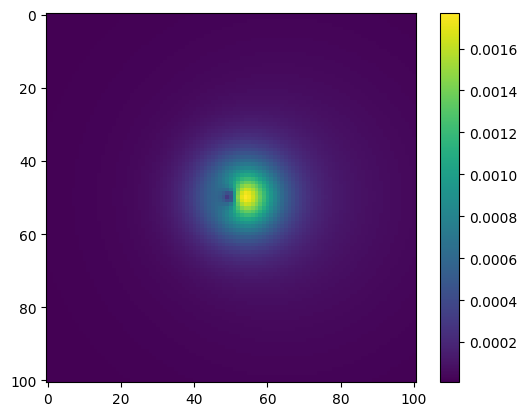

1.0000000000000002


In [44]:
# Create a bearing tensor (e.g., 0 radians) on the desired device
test_bearing = torch.tensor([[0.0]], device=device)

# Instantiate the Params_to_Grid_Block using the given parameters
movement_distribution_block = Params_to_Grid_Block(params)

# Define the parameters for the movement density
# These are the parameters that the model will learn to predict

# First Gamma distribution
gamma_shape1 = 2
gamma_scale1 = 100
gamma_weight1 = 1

# Second Gamma distribution
gamma_shape2 = 1.5
gamma_scale2 = 500
gamma_scale2 = gamma_scale2 / 500 # divide this by 500 (as this is what the model predicts)
gamma_weight2 = 0.01

# First von Mises distribution
vonmises_mu1 = 0.0
vonmises_kappa1 = 1.0
vonmises_weight1 = 0.75

# Second von Mises distribution
vonmises_mu2 = -np.pi
vonmises_kappa2 = 0.01
vonmises_weight2 = 0.25

# Provide parameters on a log-scale (since the block exponentiates them internally)
# Here, each group of three values represents a Gamma distribution's shape, scale, and weight, respectively.
movement_density = movement_distribution_block(
    torch.tensor(
        [[
            # Gamma 1
            np.log(gamma_shape1),   np.log(gamma_scale1),   gamma_weight1, # Gamma 1 shape, scale, and weight
            # Gamma 2
            np.log(gamma_shape2),   np.log(gamma_scale2),   gamma_weight2, # Gamma 2 shape, scale, and weight
            # von Mises 1
            vonmises_mu1,           np.log(vonmises_kappa1), vonmises_weight1, # von Mises 1 mu, kappa, and weight
            # von Mises 2
            vonmises_mu2,           np.log(vonmises_kappa2), vonmises_weight2 # von Mises 2 mu, kappa, and weight
        ]],
        device=device
    ),
    test_bearing
)

# Alternatively, if you had direct (non-log) values as the model sees them:
# movement_density = test_block(torch.tensor([[-.5, -.5, -.5, -.5]], device=device))

# print(movement_density)
print(movement_density.shape)

# Plot the resulting movement density as an image
plt.imshow(np.exp(movement_density.detach().cpu().numpy()[0]))
plt.colorbar()
plt.show()

print(np.sum(np.exp(movement_density.detach().cpu().numpy()[0])))

## Pull out some testing data

To test the other blocks, and the full model, we will need some data. We can pull that out from the training set.

In [45]:
# Number of samples in the train dataset
print("Number of samples in the train dataset: ", len(dataloader_train.dataset))
print('\n')

# Select an index from the test dataset to retrieve a sample, between 0 and number of samples
# We picked this fairly arbitrarily, but with some interesting environmental features to illustrate the model's predictions
iteration_index = 2700

# 2. Retrieve a single sample (features and label) from the test dataset at the specified index

# sample_spatial_covs is a sample of the spatial covariates for a single step
# sample_temporal_covs is a sample of the temporal covariates for a single step
# sample_prev_bearing is a sample bearing of the previous step
# sample_next_step is the target label (what we are trying to predict) for the next step

# We set these here and will also use them later in the script to check how the model's predictions look,
# and when we extract feature maps from the convolutional layers
sample_spatial_covs, sample_temporal_covs, sample_prev_bearing, sample_targets = dataloader_train.dataset[iteration_index]

# 3. Reshape data tensors to add a batch dimension (since the model expects batches)
sample_spatial_covs = sample_spatial_covs.unsqueeze(0).to(device)
sample_temporal_covs = sample_temporal_covs.unsqueeze(0).to(device)
sample_prev_bearing = sample_prev_bearing.unsqueeze(0).to(device)
sample_next_step = sample_targets[0].unsqueeze(0).to(device)
sample_step_length = sample_targets[1].unsqueeze(0).to(device)
sample_turn_angle = sample_targets[2].unsqueeze(0).to(device)

print(f'Shape of the sample spatial covariates:  {sample_spatial_covs.shape}')
print(f'Shape of the sample temporal covariates: {sample_temporal_covs.shape}')
print(f'Shape of the sample previous bearing:    {sample_prev_bearing.shape}')
print(f'Shape of the sample next step:           {sample_next_step.shape}')
print(f'Shape of the sample step length:         {sample_step_length.shape}')
print(f'Shape of the sample turning angle:       {sample_turn_angle.shape}')
print(f'Value of the step length:                {sample_step_length}')
print(f'Value of the turning angle:              {sample_turn_angle}')

Number of samples in the train dataset:  8083


Shape of the sample spatial covariates:  torch.Size([1, 4, 101, 101])
Shape of the sample temporal covariates: torch.Size([1, 4])
Shape of the sample previous bearing:    torch.Size([1, 1])
Shape of the sample next step:           torch.Size([1, 101, 101])
Shape of the sample step length:         torch.Size([1, 1])
Shape of the sample turning angle:       torch.Size([1, 1])
Value of the step length:                tensor([[5.4219]], device='cuda:0')
Value of the turning angle:              tensor([[3.0814]], device='cuda:0')


### For visualisation, we can return the scale of the covariates to their original values.

In [46]:
# 1. NDVI (Normalized Difference Vegetation Index)
ndvi_norm = sample_spatial_covs.detach().cpu()[0, 0, :, :]
ndvi_natural = (ndvi_norm * (ndvi_max - ndvi_min)) + ndvi_min

# 2. Canopy cover
canopy_norm = sample_spatial_covs.detach().cpu()[0, 1, :, :]
canopy_natural = (canopy_norm * (canopy_max - canopy_min)) + canopy_min

# 3. Herbaceous vegetation
herby_norm = sample_spatial_covs.detach().cpu()[0, 2, :, :]
herby_natural = (herby_norm * (herby_max - herby_min)) + herby_min

# 4. Slope
slope_norm = sample_spatial_covs.detach().cpu()[0, 3, :, :]
slope_natural = (slope_norm * (slope_max - slope_min)) + slope_min

### Pull out the scalar values

In [47]:
# Convert the PyTorch tensor x2 to a NumPy array:
#   1) Detach from the computation graph so no gradients are tracked.
#   2) Move to CPU memory.
#   3) Convert to NumPy.
# Then extract the first sample (index 0) and its respective channel for each variable:
hour_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 0]
hour_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 1]
hour_t2_sin2 = sample_temporal_covs.detach().cpu().numpy()[0, 2]
hour_t2_cos2 = sample_temporal_covs.detach().cpu().numpy()[0, 3]
# yday_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 4]
# yday_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 5]

# Convert x3 similarly and extract the bearing from the first sample and channel:
bearing = sample_prev_bearing.detach().cpu().numpy()[0, 0]

### Helper functions

To return the hour and day of the year to their original values, we can use the following functions.

In [48]:
def recover_hour(sin_term, cos_term):
    # Calculate the angle theta
    theta = np.arctan2(sin_term, cos_term)
    # Calculate hour_t2
    hour = (12 * theta) / np.pi % 24
    return hour

def recover_yday(sin_term, cos_term):
    # Calculate the angle theta
    theta = np.arctan2(sin_term, cos_term)
    # Calculate hour_t2
    yday = (365 * theta) / (2 * np.pi)  % 365
    return yday

### Calculate the hour, day of year and previous bearing of the test sample

In [49]:
hour_t2 = recover_hour(hour_t2_sin, hour_t2_cos)
hour_t2_integer = int(hour_t2)  # Convert to integer
print(f'Hour:               {hour_t2_integer}')

# yday_t2 = recover_yday(yday_t2_sin, yday_t2_cos)
# yday_t2_integer = int(yday_t2)  # Convert to integer
# print(f'Day of the year:    {yday_t2_integer}')

bearing_degrees = np.degrees(bearing) % 360
bearing_degrees = round(bearing_degrees, 1)  # Round to 2 decimal places
bearing_degrees = int(bearing_degrees)  # Convert to integer
print(f'Bearing (radians):  {bearing}')
print(f'Bearing (degrees):  {bearing_degrees}')

Hour:               23
Bearing (radians):  0.21987615525722504
Bearing (degrees):  12


### Grab the row and column of the observed next step (label or target)

In [50]:
# Find the coordinates of the element that is 1
target = sample_next_step.detach().cpu().numpy()[0,:,:]
coordinates = np.where(target == 1)
# Extract the coordinates
row, column = coordinates[0][0], coordinates[1][0]
print(f"The location of the next step is (row, column): ({row}, {column})")

The location of the next step is (row, column): (50, 49)


### Plot the sample covariates

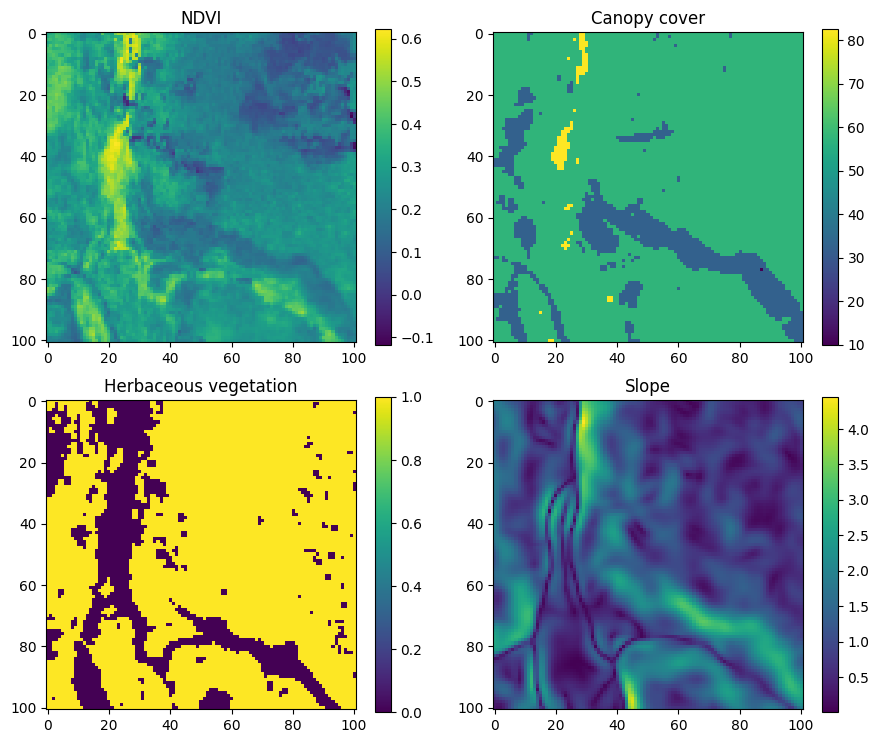

In [51]:
# Plot the covariates
fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

# Plot NDVI
im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
axs[0, 0].set_title('NDVI')
fig.colorbar(im1, ax=axs[0, 0])

# Plot Canopy cover
im2 = axs[0, 1].imshow(canopy_natural.numpy(), cmap='viridis')
axs[0, 1].set_title('Canopy cover')
fig.colorbar(im2, ax=axs[0, 1])

# Plot Herbaceous vegetation
im3 = axs[1, 0].imshow(herby_natural.numpy(), cmap='viridis')
axs[1, 0].set_title('Herbaceous vegetation')
fig.colorbar(im3, ax=axs[1, 0])

# Plot Slope
im4 = axs[1, 1].imshow(slope_natural.numpy(), cmap='viridis')
axs[1, 1].set_title('Slope')
fig.colorbar(im4, ax=axs[1, 1])

yday_t2_integer = 17

filename_covs = f'{output_dir}/covs_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'
plt.tight_layout()
plt.savefig(filename_covs, dpi=300, bbox_inches='tight') # if we want to save the figure
plt.show()
plt.close()  # Close the figure to free memory

## Plot the target (observed location of the next step)

The model is trying to maximise the probability at the location of the next step, which is the target.

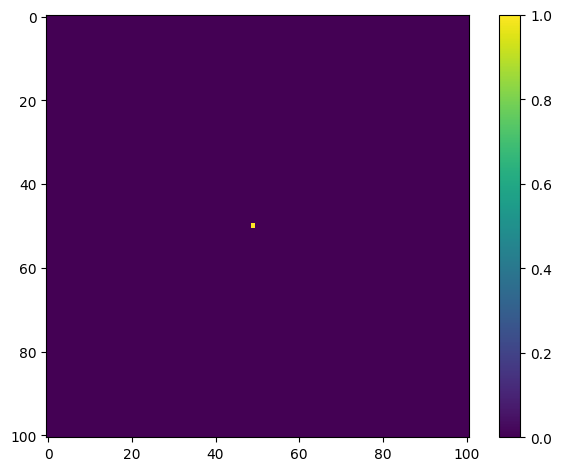

In [52]:
filename_target = f'{output_dir}/target_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'

plt.imshow(target)
plt.tight_layout()
plt.savefig(filename_target, dpi=300, bbox_inches='tight') # if we want to save the figure
plt.colorbar()
plt.show()

## Testing the scalar to grid function

This should just create a grid with the same value for all pixels.

torch.Size([1, 4])
tensor([-0.2538,  0.9673, -0.4909,  0.8712], device='cuda:0')
torch.Size([1, 4, 101, 101])


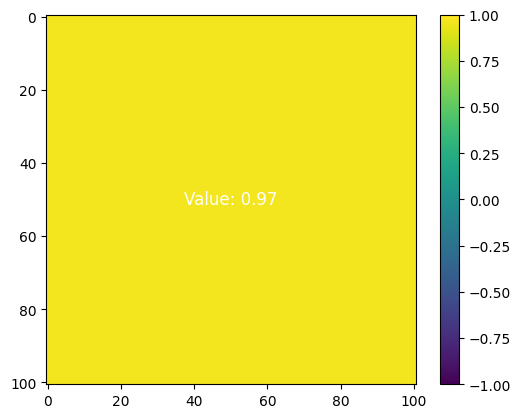

In [53]:
# x2 contains the scalar inputs
print(sample_temporal_covs.shape)  # Check the shape of the scalar input
print(sample_temporal_covs[0, :])  # Print out the first set of scalars

# Create an instance of the scalar-to-grid block using model parameters
test_block = Scalar_to_Grid_Block(params)

# Convert scalars into spatial grid representation
scalar_maps = test_block(sample_temporal_covs).detach().cpu()
# print(scalar_maps)  # Optionally, to inspect raw output
print(scalar_maps.shape)  # Check the shape of the generated spatial maps

# Visualize one channel of the first example's scalar map
# (Values are should be repeated across the grid for each scalar)
scalar_index = 1  # Change this index to visualize other scalar maps
plt.imshow(scalar_maps[0, scalar_index]) # change the second index to see the other scalar maps
plt.colorbar()
plt.clim(-1, 1) # Set the color limits to match the range of the scalar values (sine and cosine of temporal parameters)
plt.text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
         f'Value: {round(sample_temporal_covs[0, scalar_index].item(), 2)}',
         ha='center', va='center', color='white', fontsize=12)
plt.show()

# Test the full model

The model is initialised with random weights and hasn't been trained yet, so the output will not be meaningful. However, we can check that the model runs without errors and that the output is the correct shape.

In [54]:
# Put the model in evaluation mode (affects layers like dropout, batch norm, etc.)
model.eval()

# Pass the data through the model
habitat_predictions_test, movement_params_test, bearing_test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# Print the shape of the output
print(habitat_predictions_test.shape)

torch.Size([1, 101, 101])


## Habitat predictions

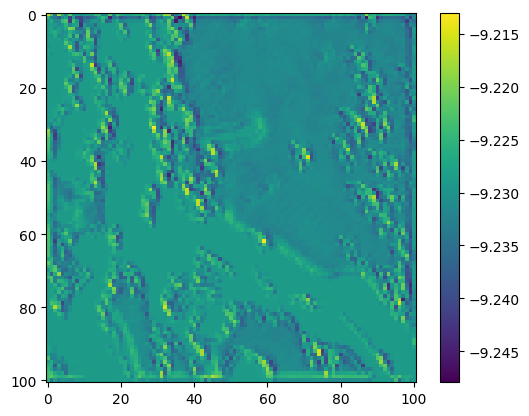

In [55]:
plt.imshow(habitat_predictions_test.detach().cpu().numpy()[0,:,:])
plt.colorbar()
plt.show()

## Movement predictions

Bearing (radians): 0.21987615525722504
Bearing (degrees): 12
torch.Size([1, 101, 101])


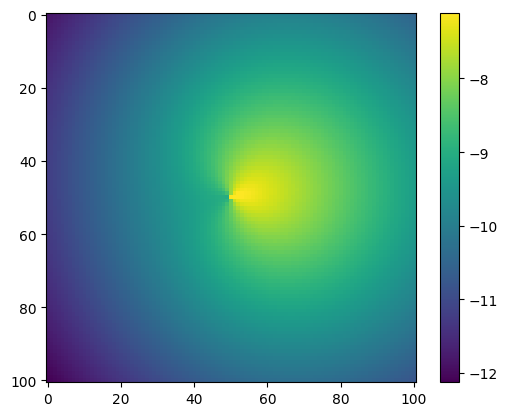

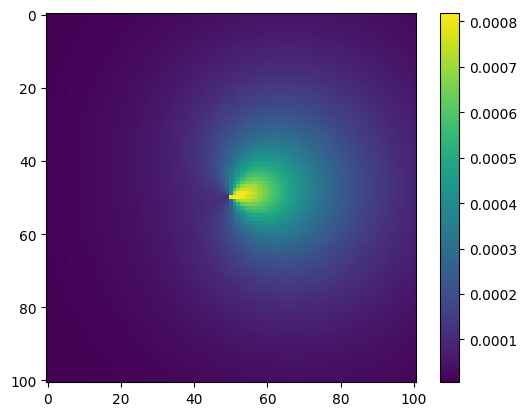

In [56]:
# Print input bearing
print(f'Bearing (radians): {bearing}')
print(f'Bearing (degrees): {bearing_degrees}')

movement_predictions_test = movement_distribution_block(movement_params_test, bearing_test)
print(movement_predictions_test.shape)

# Plot the movement density on the log-scale
plt.imshow(movement_predictions_test.detach().cpu().numpy()[0,:,:])
plt.colorbar()
plt.show()

# Plot the movement density on the natural scale
plt.imshow(np.exp(movement_predictions_test.detach().cpu().numpy()[0,:,:]))
plt.colorbar()
plt.show()

## Next-step probability distribution

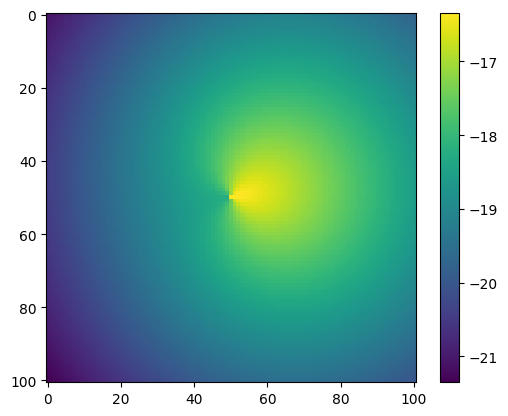

In [57]:
# Combine the habitat selection and the movement probabilities (unnormalised)
next_step = (habitat_predictions_test[:, :, :] + movement_predictions_test[:, :, :])

# Plot the combined output
plt.imshow(next_step.detach().cpu().numpy()[0,:,:])
plt.colorbar()
plt.show()

# Prepare for training

## Loss function

We use a custom negative log likelihood loss function. Essentially what this does is extracts the next-step log-probability at the location of the observed next step, and then takes the negative of this value. This is the loss that we want to minimise, as we want to maximise the probability of the observed next step.

We will also save this loss function in a script called `deepSSF_loss.py` so that we can import it into future scripts.

In [58]:
class negativeLogLikeLoss(nn.Module):
    """
    Custom negative log-likelihood loss that operates on a 4D prediction tensor
    (batch, height, width, channels). The forward pass:
    1. Sums across channel 3 (two log-densities, habitat selection and movement predictions) to obtain a combined log-density.
    2. Multiplies this log-density by the target, which is 0 everywhere except for at the location of the next step, effectively extracting that value,
    then multiplies by -1 such that the function can be minimised (and the probabilities maximised).
    3. Applies the user-specified reduction (mean, sum, or none).
    """

    def __init__(self, reduction='mean'):
        """
        Args:
            reduction (str): Specifies the reduction to apply to the output:
                             'mean', 'sum', or 'none'.
        """
        super(negativeLogLikeLoss, self).__init__()
        assert reduction in ['mean', 'sum', 'none'], \
            "reduction should be 'mean', 'sum', or 'none'"
        self.reduction = reduction

        # Initialize the density calculation block
        self.movement_density_block = Params_to_Density_Block(params)


    def forward(self, model_outputs, targets):
        """
        Forward pass of the negative log-likelihood loss.

        Args:
            model_outputs: Tuple of tensors (habitat_output, movement_params, bearing)
            targets: Tuple of tensors (habitat_target, step_length, turn_angle)

        Returns:
            Tensor: The computed (combined and possibly weighted) negative log-likelihood loss.
            Shape depends on the reduction method.
        """

        # Unpack model outputs
        habitat_output, movement_params, bearing = model_outputs

        # Unpack targets
        habitat_target, step_length, turn_angle = targets

        # Check for NaNs in the combined predictions
        if torch.isnan(habitat_target).any():
            print("NaNs detected in habitat_target")
            print("total_lass:", habitat_target)
            raise ValueError("NaNs detected in habitat_target")

        # Compute negative log-likelihood of the habitat by multiplying log-density with target
        # and then flipping the sign
        habitat_loss = -1 * (habitat_output * habitat_target)
        # print("habitat_loss shape:", habitat_loss.shape)
        habitat_loss = habitat_loss.sum(dim=(1, 2))
        # print("habitat_loss shape:", habitat_loss)

        # Calculate movement density (log-likelihood)
        movement_loss = -1 * self.movement_density_block(movement_params, step_length, turn_angle, bearing)
        # print("movement_loss shape:", movement_loss.shape)

        # Combine losses with weights
        # total_loss = self.habitat_loss_weight * habitat_loss # habitat-only loss
        # total_loss = self.movement_loss_weight * movement_loss # movement-only loss
        total_loss = habitat_loss + movement_loss

        # Check for NaNs in the combined predictions
        if torch.isnan(total_loss).any():
            print("NaNs detected in total_loss")
            print("total_lass:", total_loss)
            raise ValueError("NaNs detected in total_loss")

        # Apply the specified reduction
        if self.reduction == 'mean':
            return torch.mean(total_loss), torch.mean(habitat_loss), torch.mean(movement_loss)
        elif self.reduction == 'sum':
            return torch.sum(total_loss), torch.sum(habitat_loss), torch.sum(movement_loss)
        elif self.reduction == 'none':
            return total_loss, habitat_loss, movement_loss

        # Default return (though it should never reach here without hitting an if)
        return total_loss, habitat_loss, movement_loss


## Test the loss function

In [59]:
# Define the negative log-likelihood loss function with mean reduction
loss_fn = negativeLogLikeLoss(reduction='mean')

# Calculate the loss using the model outputs and the targets
total_loss, habitat_loss, movement_loss = loss_fn((habitat_predictions_test, movement_params_test, bearing_test), (sample_next_step, sample_step_length, sample_turn_angle))
print(f'Total loss:     {total_loss}')
print(f'Habitat loss:   {habitat_loss}')
print(f'Movement loss:  {movement_loss}')

Total loss:     18.16653060913086
Habitat loss:   9.231406211853027
Movement loss:  8.935125350952148


## Early stopping code

This code will be used to stop training if the validation loss does not improve after a certain number of epochs.

When the loss of the validation data (which is held out from the training data) decreases (i.e. the model improves), the model weights are saved. Each time the validation loss does not decrease, a counter is incremented. If the counter reaches the patience value, the training loop will break and the model will stop training. The 'final' model is then the model that had the lowest validation loss.

We have saved this code in a script called `deepSSF_early_stopping.py` so that we can import it into future scripts.

In [60]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 5
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):

        # takes the validation loss and the model as inputs
        score = -val_loss

        # save the model's weights if the validation loss decreases
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        # if the validation loss does not decrease, increment the counter
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## Set the learning rate

The learning rate is a hyperparameter that controls how much we are adjusting the weights of our network with respect to the loss gradient. A larger learning rate means that the optimiser will take larger steps, but it may overshoot the minimum. A smaller learning rate means that the optimiser will take smaller steps, but it may take a long time to converge.

We can therefore use an adaptive learning rate, which will adjust the learning rate during training. If the loss does not decrease after a certain number of epochs (also called the patience), the learning rate will be reduced by a factor of 10.

The patience of the learning rate should be less than the patience of the early stopping code, as we want to reduce the learning rate before we stop training.

In [61]:
learning_rate = 5e-5

### Path to save the model weights

In [62]:
path_save_weights = f'{output_dir}/checkpoint_deepSSF_polar_buffalo{buffalo_id}.pt'
print(path_save_weights)

/content/drive/MyDrive/GitHub/deepSSF/Python/outputs/model_training/id2005_polar_fcn_mixture_7_2025-05-01/checkpoint_deepSSF_polar_buffalo2005.pt


## Instantiate the loss function, optimiser, learning rate scheduler and early stopping code

In this chunk, we set up all the components needed for training and validating a neural network model:

1. Loss Function: Uses a negative log-likelihood loss (negativeLogLikeLoss) with mean reduction.
2. Optimizer: Implements the Adam optimization algorithm, updating model parameters based on the computed gradients and a specified learning rate.
3. Scheduler: Automatically reduces the learning rate when the monitored metric (e.g., validation loss) stops improving.
4. Early Stopping: Monitors validation performance and stops training if the metric fails to improve after a certain number of epochs (patience).

In [63]:
# Define the negative log-likelihood loss function with mean reduction
loss_fn = negativeLogLikeLoss(reduction='mean')

# Set up the Adam optimizer for updating the model's parameters
optimiser = optim.Adam(model.parameters(), lr=learning_rate)

# Create a learning rate scheduler that reduces the LR by a factor of 0.1
#    if validation loss has not improved for 'patience=5' epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,  # The optimizer whose learning rate will be adjusted
    mode='min', # The metric to be minimized (e.g., validation loss)
    factor=0.1, # Factor by which the learning rate will be reduced
    patience=5  # Number of epochs with no improvement before learning rate reduces
)

# EarlyStopping stops training after 'patience=10' epochs with no improvement,
#    optionally saving the best model weights
early_stopping = EarlyStopping(patience=25, verbose=True, path=path_save_weights)

## Training loop

This code defines the main training loop for a single epoch. It iterates over batches from the training dataloader, moves the data to the correct device (e.g., CPU or GPU), calculates the loss, and performs backpropagation to update the model parameters. It also prints periodic updates of the current loss.

In [64]:
def train_loop(dataloader_train, model, loss_fn, optimiser, skip_epoch0_training=False):
    """
    Runs the training process for one epoch using the given dataloader, model,
    loss function, and optimizer. Prints progress updates every few batches.
    """

    # 1. Total number of training examples
    num_train_batches = len(dataloader_train)
    size = len(dataloader_train.dataset)

    # 2. Put model in training mode (affects layers like dropout, batchnorm)
    model.train()

    # 3. Variable to accumulate the total loss over the epoch
    epoch_loss = 0.0

    # 4. Loop over batches in the training dataloader
    for batch, (x1, x2, x3, y) in enumerate(dataloader_train):

        # Move the batch of data to the specified device (CPU/GPU)
        x1 = x1.to(device)
        x2 = x2.to(device)
        x3 = x3.to(device)
        y = [item.to(device) for item in y]

        # Forward pass: compute the model output and loss
        with torch.set_grad_enabled(not skip_epoch0_training):
            outputs = model((x1, x2, x3))
            total_loss, habitat_loss, movement_loss = loss_fn(outputs, y)

        epoch_loss += total_loss.detach()  # Use detach to prevent memory leaks

        # Only perform optimization if not skipping training
        if not skip_epoch0_training:
            # Backpropagation: compute gradients and update parameters
            # Reset gradients before the next iteration
            optimiser.zero_grad()
            total_loss.backward()
            optimiser.step()

        # Print an update every 5 batches to keep track of training progress
        if batch % 10 == 0:
            loss_val = total_loss.item()
            current = batch * batch_size + len(x1)
            if skip_epoch0_training:
                print(f"[Observation only] loss: {loss_val:>15f}  [{current:>5d}/{size:>5d}]")
            else:
                print(f"loss: {loss_val:>15f}  [{current:>5d}/{size:>5d}]")

        torch.cuda.empty_cache()

    # Compute the average training loss and print it
    epoch_loss /= num_train_batches
    if skip_epoch0_training:
        print(f"\nAvg training loss (observation only): {epoch_loss:>15f}")
    else:
        print(f"\nAvg training loss:        {epoch_loss:>15f}")
    train_losses.append(epoch_loss.item())

## Test loop

The test loop is similar to the training loop, but it does not perform backpropagation. It calculates the loss on the test set and returns the average loss.

In [65]:
def test_loop(dataloader_test, model, loss_fn):
    """
    Evaluates the model on the provided test dataset by computing
    the average loss over all batches.
    No gradients are computed during this process (torch.no_grad()).
    """

    # 1. Set the model to evaluation mode (affects layers like dropout, batchnorm).
    model.eval()

    size = len(dataloader_test.dataset)
    num_batches = len(dataloader_test)

    test_loss = 0

    # 2. Disable gradient computation to speed up evaluation and reduce memory usage
    with torch.no_grad():
        # 3. Loop through each batch in the test dataloader
        for x1, x2, x3, y in dataloader_test:

            # Move the batch of data to the appropriate device (CPU/GPU)
            # x1, x2, x3 are the spatial covariates, temporal covariates, and bearing, respectively
            # y is the label (observed location of the next step)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = [item.to(device) for item in y]

            # Compute the loss on the test set (no backward pass needed)
            total_loss, habitat_loss, movement_loss = loss_fn(model((x1, x2, x3)), y)
            test_loss += total_loss

    # 4. Compute average test loss over all batches
    test_loss /= num_batches

    torch.cuda.empty_cache()

    # Print the average test loss
    print(f"Avg test loss:    {test_loss:>15f} \n")

# Train the model

Here we have the main training process that loops over multiple epochs. Each epoch involves:

1. Training the model on a training dataset.
2. Validating the model on a validation dataset to monitor its performance and adjust the learning rate (via scheduler).
3. Checking for early stopping conditions. If triggered, the best model weights are restored, and a test evaluation is performed.

Additionally, commented-out code at the end shows how you might visualise and save intermediate training results (such as predicted probability surfaces) for diagnostic or research purposes. The saved images can then be combined into an animation.

In [66]:
epochs = 120
train_losses = []  # Track training losses across epochs
val_losses = []   # Track validation losses across epochs
val_habitat_losses = []  # Track validation habitat losses across epochs
val_movement_losses = []  # Track validation movement losses across epochs

# Initialize the parameter container using the parameters defined in 'params_dict'
params = ModelParams(params_dict)
# Create an instance of the ConvJointModel using the parameters,
# and move the model to the specified device (e.g., CPU or GPU)
model = ConvJointModel(params).to(device)
# Print the model architecture
print(model)

# Define the negative log-likelihood loss function with mean reduction
loss_fn = negativeLogLikeLoss(reduction='mean') #, alpha=0.5
# Reinitialize optimizer for the new model
optimiser = torch.optim.Adam(model.parameters(), lr=1e-4)  # Adjust learning rate as needed
# Reinitialize scheduler for the new model
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, 'min', factor=0.1, patience=5)
# Reinitialise early stopping
early_stopping = EarlyStopping(patience=15, verbose=True, path=path_save_weights)

# Create directory for saving training images
os.makedirs(f'{output_dir}/training_images', exist_ok=True)

for t in range(epochs):

    # Initialise variables to store during training
    train_loss = 0.0
    num_train_batches = len(dataloader_train)

    val_loss = 0.0
    val_loss_habitat = 0.0
    val_loss_movement = 0.0
    num_batches = len(dataloader_val)

    print(f"Epoch {t+1}\n-------------------------------")

    # Skip training in the first epoch, but still calculate losses
    skip_training = (t == 0)

    # 1. Run the training loop for one epoch using the training dataloader
    train_loop(dataloader_train, model, loss_fn, optimiser, skip_epoch0_training=skip_training)

    # 2. Evaluate model performance on the validation dataset
    model.eval()  # Switch to evaluation mode for proper layer behavior
    with torch.no_grad():

        # Loop through each batch in the validation dataloader
        for x1, x2, x3, y in dataloader_val:
            # Move data to the chosen device (CPU/GPU)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = [item.to(device) for item in y]

            # Accumulate validation loss
            total_loss, habitat_loss, movement_loss = loss_fn(model((x1, x2, x3)), y)
            val_loss += total_loss.detach() # Use detach to prevent memory leaks
            val_loss_habitat += habitat_loss.detach()
            val_loss_movement += movement_loss.detach()

    # 3. Step the scheduler based on the validation loss (adjusts learning rate if needed)
    scheduler.step(val_loss)

    # 4. Compute the average validation loss and print it, along with the current learning rate
    val_loss /= num_batches
    val_loss_habitat /= num_batches
    val_loss_movement /= num_batches

    print(f"Avg validation loss:            {val_loss:>15f}")
    print(f"Avg validation habitat loss:    {val_loss_habitat:>15f}")
    print(f"Avg validation movement loss:   {val_loss_movement:>15f}")
    print(f"Learning rate: {scheduler.get_last_lr()}")

    # 5. Track the validation loss for plotting or monitoring
    val_losses.append(val_loss.item())
    val_habitat_losses.append(val_loss_habitat.item())
    val_movement_losses.append(val_loss_movement.item())

    # Memory management - add after validation but before early stopping check
    # torch.cuda.empty_cache()
    # gc.collect()

    # 6. Early stopping: if no improvement in validation loss for a set patience, stop training
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        # Restore the best model weights saved by EarlyStopping
        model.load_state_dict(torch.load(path_save_weights, weights_only=True, map_location=device))
        test_loop(dataloader_test, model, loss_fn)  # Evaluate on test set once training stops
        break
    else:
        model.eval()
        print("\n")

    torch.cuda.empty_cache()


    # ----------------------------------------------------
    # The following code demonstrates how
    # to optionally visualize or save intermediate results
    # (e.g., habitat probability surface, movement probability,
    # and next-step probability surfaces).

    # uncomment the code all in one go to run it (it should be inside the training loop)
    # ----------------------------------------------------

    # Extract training and validation losses for plotting

    # Convert the list of tensors to a single tensor
    val_losses_np = torch.tensor(val_losses).detach().cpu().numpy()
    train_losses_np = torch.tensor(train_losses).detach().cpu().numpy()
    # Number of epochs
    n_epochs = len(val_losses)

    # -----------------------------------------------------------
    # 1. Retrieve a single test example (covariates and labels)
    #    at the specified 'iteration_index' from the test dataset
    # -----------------------------------------------------------
    x1, x2, x3, targets = dataloader_train.dataset[iteration_index]

    # -----------------------------------------------------------
    # 2. Add a batch dimension and move tensors to the device
    #    for model inference
    # -----------------------------------------------------------
    x1 = x1.unsqueeze(0).to(device)
    x2 = x2.unsqueeze(0).to(device)
    x3 = x3.unsqueeze(0).to(device)

    # -----------------------------------------------------------
    # 3. Run the model on the single test example
    # -----------------------------------------------------------
    test = model((x1, x2, x3))
    habitat_predictions, movement_params, bearing = test

    # -----------------------------------------------------------
    # 4. Extract habitat and movement outputs;
    #    convert them to NumPy arrays for visualization
    # -----------------------------------------------------------
    hab_density = habitat_predictions.squeeze().detach().cpu().numpy()

    movement_density = movement_distribution_block(movement_params, bearing)
    movement_density = movement_density.squeeze().detach().cpu().numpy()

    # -----------------------------------------------------------
    # 5. Generate masks to exclude certain border cells for
    #    color scale reasons (setting them to -inf).
    # -----------------------------------------------------------
    x_mask = np.ones_like(hab_density)
    y_mask = np.ones_like(hab_density)

    # Mask out a few columns (0-2 and 98-end) and rows (0-2 and 98-end)
    x_mask[:, :3] = -np.inf
    x_mask[:, 98:] = -np.inf
    y_mask[:3, :] = -np.inf
    y_mask[98:, :] = -np.inf

    # Apply the masks to habitat density
    hab_density_mask = hab_density * x_mask * y_mask

    # Combine habitat and movement densities to represent
    # next-step probability
    step_density = hab_density + movement_density
    step_density_mask = step_density * x_mask * y_mask

    # Plot the covariates
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # # Plot NDVI
    # im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
    # axs[0, 0].set_title('NDVI')
    # fig.colorbar(im1, ax=axs[0, 0])

    # Plot Training and Validation Loss
    axs[0, 0].plot(range(n_epochs), train_losses_np, label='Training Loss', color='blue')
    axs[0, 0].plot(range(n_epochs), val_losses_np, label='Validation Loss', color='red')
    axs[0, 0].set_xlim(0, 120)
    axs[0, 0].set_title('Training and validation loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()

    # Plot habitat selection log-probability
    im2 = axs[0, 1].imshow(hab_density_mask, cmap='viridis')
    axs[0, 1].set_title('Habitat log-probability')
    fig.colorbar(im2, ax=axs[0, 1])

    # Plot movement log-probability
    im3 = axs[1, 0].imshow(movement_density, cmap='viridis')
    axs[1, 0].set_title('Movement log-probability')
    fig.colorbar(im3, ax=axs[1, 0])

    # Plot next-step log-probability
    im4 = axs[1, 1].imshow(step_density_mask, cmap='viridis')
    axs[1, 1].set_title('Next-step log-probability')
    fig.colorbar(im4, ax=axs[1, 1])

    filename_covs = f'{output_dir}/training_images/training_epoch{t}_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'
    plt.tight_layout()
    plt.savefig(filename_covs, dpi=300) # creates inconsistent image sizes >>> , bbox_inches='tight'
    plt.show()
    plt.close()  # Close the figure to free memory

print("Done!")

Output hidden; open in https://colab.research.google.com to view.

### Make a GIF of the training images

First, here's a function to call to make a gif from a given directory.

In [67]:
# Example sorting by the epoch number
def extract_epoch(filename):
    # Extract the epoch number from the filename
    # Adjust the extraction based on your naming pattern
    import re
    match = re.search(r'training_epoch(\d+)_', filename)
    if match:
        return int(match.group(1))
    return 0

def create_gif(image_folder, output_filename, fps=10):
    """
    Creates a GIF from a sequence of images in a folder.

    Parameters:
    - image_folder: Path to the folder containing images
    - output_filename: Name of the output GIF file
    - duration: Duration of each frame in seconds
    """
    # Get all png files in the specified folder, sorted by name
    images = sorted(glob.glob(os.path.join(image_folder, '*.png')), key=extract_epoch)

    # Check if any images were found
    if not images:
        print(f"No images found in {image_folder}")
        return

    # Read all images
    frames = [imageio.imread(image) for image in images]

    # Save as GIF
    imageio.mimsave(output_filename, frames, fps=fps, loop=0)

    display(Image(filename=output_filename))

    print(f"GIF created successfully: {output_filename}")


In [68]:
# Path to your images
image_folder =  f'{output_dir}/training_images'

# Output GIF filename
output_filename = f'{output_dir}/training_gif_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.gif'

# Create the GIF
create_gif(image_folder, output_filename, fps=10)

Output hidden; open in https://colab.research.google.com to view.

In [69]:
# to look at the parameters (weights and biases) of the model
# print(model.state_dict())

# Loading in previous models

As we've trained the model, the model parameters are already stored in the `model` object. But as we were training the model, we were saving it to file, and that, and other trained models can be loaded.

The model parameters that are being loaded must match the model object that has been defined above. If the model object has changed, the model parameters will not be able to be loaded.

In [70]:
path_save_weights

'/content/drive/MyDrive/GitHub/deepSSF/Python/outputs/model_training/id2005_polar_fcn_mixture_7_2025-05-01/checkpoint_deepSSF_polar_buffalo2005.pt'

### If loading a previously trained model

In [71]:
# to load previously saved weights
# path_save_weights = f'{output_dir}/checkpoint_deepSSF_buffalo2005_2025-04-01.pt'

model.load_state_dict(torch.load(path_save_weights,
                                 weights_only=True,
                                 map_location=torch.device('cpu')))

<All keys matched successfully>

# View model outputs

## Create a directory to save model outputs

### Save the validation loss as a dataframe

In [72]:
# Directory for saving the loss dataframe
filename_loss_csv = f'{output_dir}/deepSSF_val_loss_buffalo{buffalo_id}.csv'

# Check if val_losses is defined (which means a model has been trained in this session)
try:

    # Convert the list of tensors to a single tensor
    val_losses_tensor = torch.tensor(val_losses)

    print("val_losses has been defined - storing as csv\n")

    # Number of epochs
    n_epochs = len(val_losses)
    print(f'Number of epochs: {n_epochs}')

    val_losses_df = pd.DataFrame({
        "epoch": range(1, n_epochs + 1),
        "val_losses": val_losses_tensor.detach().cpu().numpy()
    })

    print(val_losses_df.head())

    # Save the validation losses to a CSV file
    val_losses_df.to_csv(filename_loss_csv, index=False)

# if val_losses hasn't been defined (for if you are loading model weights from a saved object)
except NameError:

    # This code runs if val_losses is not defined
    print("val_losses has not been defined - loading from saved csv\n")
    # Initialize it with a default value

    # Read the val_losses csv file
    val_losses_df = pd.read_csv(filename_loss_csv)
    print(val_losses_df.head())

    # Number of epochs
    n_epochs = len(val_losses_df)
    print(f'\nNumber of epochs: {n_epochs}')


val_losses has been defined - storing as csv

Number of epochs: 67
   epoch  val_losses
0      1   17.960249
1      2   16.972591
2      3   16.952330
3      4   16.918694
4      5   16.883892


In [73]:
# Directory for saving the loss dataframe
filename_train_loss_csv = f'{output_dir}/deepSSF_train_loss_buffalo{buffalo_id}.csv'

# Check if train_losses is defined (which means a model has been trained in this session)
try:

    # Convert the list of tensors to a single tensor
    train_losses_tensor = torch.tensor(train_losses)

    print("train_losses has been defined - storing as csv\n")

    train_losses_df = pd.DataFrame({
        "epoch": np.linspace(1, n_epochs, len(train_losses)),
        "train_losses": train_losses_tensor.detach().cpu().numpy()
    })

    # print(train_losses_df.head)

    # Save the train losses to a CSV file
    train_losses_df.to_csv(filename_train_loss_csv, index=False)

# if train_losses hasn't been defined (for if you are loading model weights from a saved object)
except NameError:

    # This code runs if train_losses is not defined
    print("train_losses has not been defined - loading from saved csv\n")
    # Initialize it with a default value

    # Read the train_losses csv file
    train_losses_df = pd.read_csv(filename_train_loss_csv)
    # print(train_losses_df.head())


train_losses has been defined - storing as csv



### Plot the validation loss

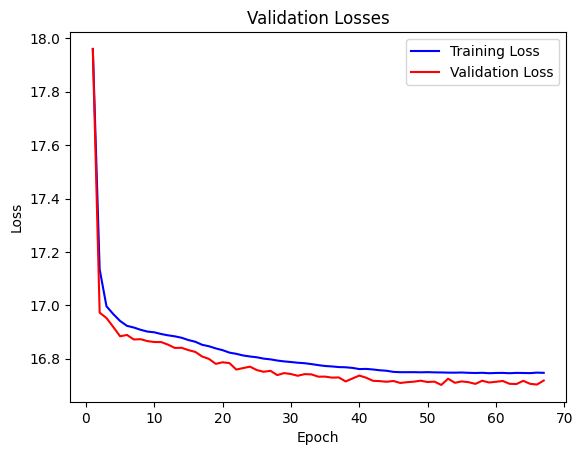

In [74]:
# Directory for saving the loss plots
filename_loss = f'{output_dir}/val_loss_buffalo{buffalo_id}.png'

# Plot the validation losses
plt.plot(train_losses_df['epoch'], train_losses_df['train_losses'], label='Training Loss', color='blue')  # Plot training loss in blue
plt.plot(val_losses_df['epoch'], val_losses_df['val_losses'], label='Validation Loss', color='red')  # Plot validation loss in red
plt.title('Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to distinguish lines
plt.savefig(filename_loss, dpi=300, bbox_inches='tight')
plt.show()

## Animation of model training

Here's what the images saved during training look like when combined into an animation (from an earlier model training).

We can see the habitat selection subnetwork starts to give probability weight to certain features as it learns their association to next-steps. We can see this quite clearly with the river feature, which progressively downweights (indicating avoidance) as the training progresses.

As the model fine-tunes, the habitat selection process becomes more defined in the next-step probabilities.


![](../figures/model_training.gif)

# Test the model on sample covariates

Use the same sample covariates as above (selected before training the model) from the *test* dataset, and then run the model on these covariates. To select a different sample, change the `iteration_index` in the code above and re-run those chunks.

Print the scalar values and plot the sample covariates

Hour:               23
Day of the year:    17
Bearing (radians):  tensor([[0.2199]], device='cuda:0')
Bearing (degrees):  12


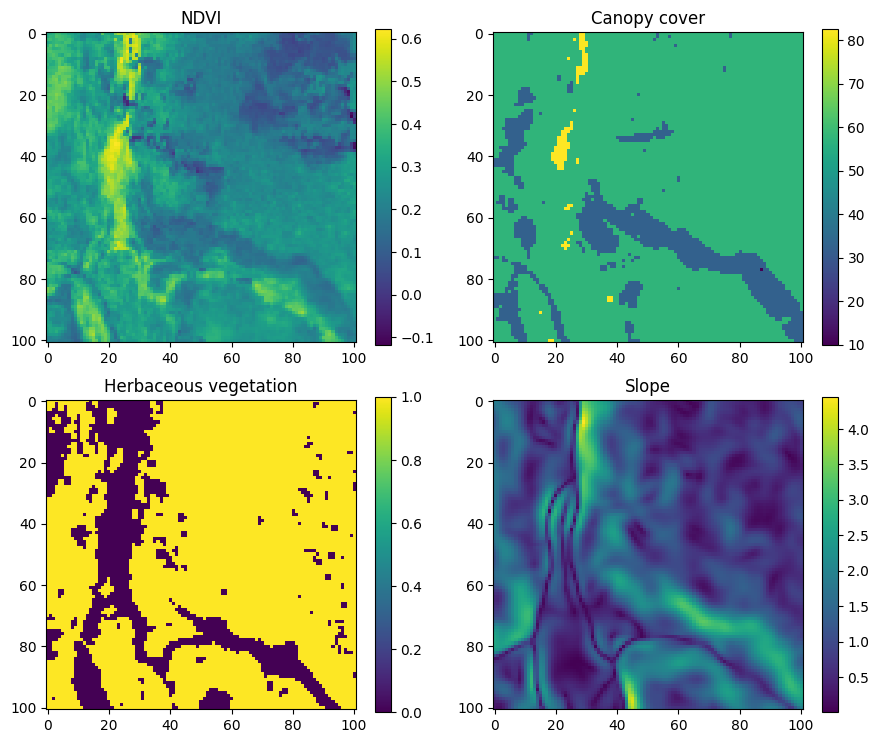

In [75]:
# Print relevant information about the current prediction context
# such as time of day, day of year, and bearing angles in both radians and degrees.
print(f'Hour:               {hour_t2_integer}')
print(f'Day of the year:    {yday_t2_integer}')
print(f'Bearing (radians):  {bearing}')
print(f'Bearing (degrees):  {bearing_degrees}')

# Plot the covariates
fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

# Plot NDVI
im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
axs[0, 0].set_title('NDVI')
fig.colorbar(im1, ax=axs[0, 0])

# Plot Canopy cover
im2 = axs[0, 1].imshow(canopy_natural.numpy(), cmap='viridis')
axs[0, 1].set_title('Canopy cover')
fig.colorbar(im2, ax=axs[0, 1])

# Plot Herbaceous vegetation
im3 = axs[1, 0].imshow(herby_natural.numpy(), cmap='viridis')
axs[1, 0].set_title('Herbaceous vegetation')
fig.colorbar(im3, ax=axs[1, 0])

# Plot Slope
im4 = axs[1, 1].imshow(slope_natural.numpy(), cmap='viridis')
axs[1, 1].set_title('Slope')
fig.colorbar(im4, ax=axs[1, 1])

filename_covs = f'{output_dir}/id{buffalo_id}_sample{iteration_index}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.png'
plt.tight_layout()
plt.savefig(filename_covs, dpi=300, bbox_inches='tight') # if we want to save the figure
plt.show()
plt.close()  # Close the figure to free memory

## Run the model on the sample covariates

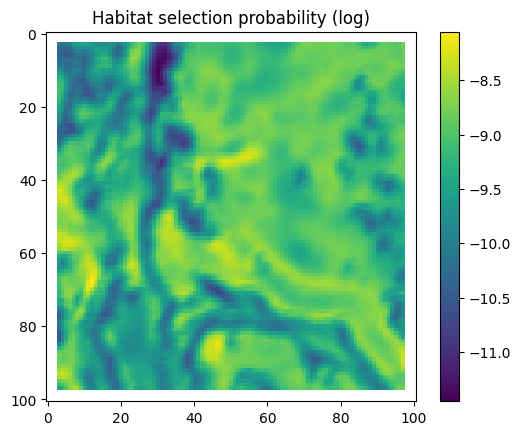

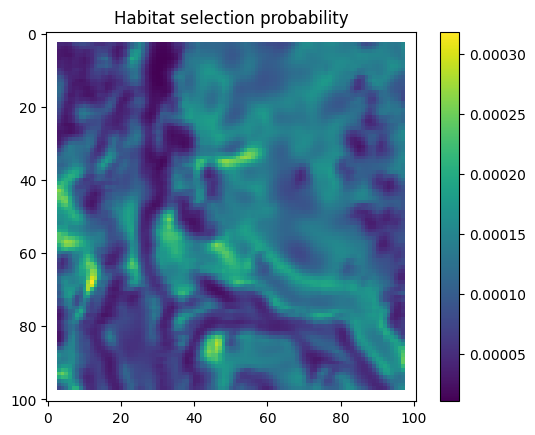

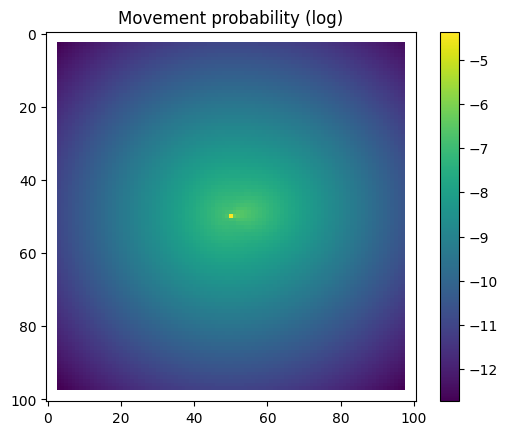

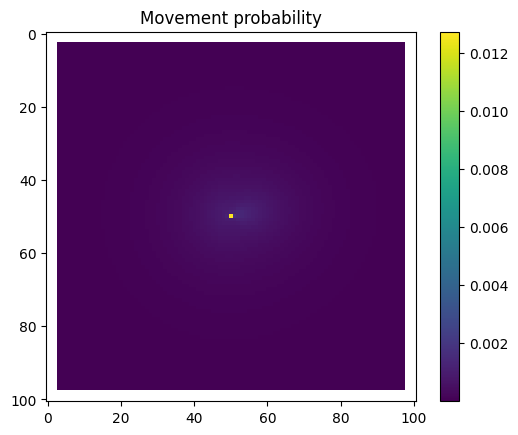

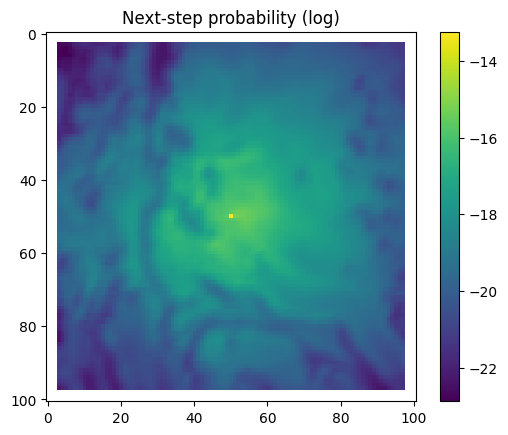

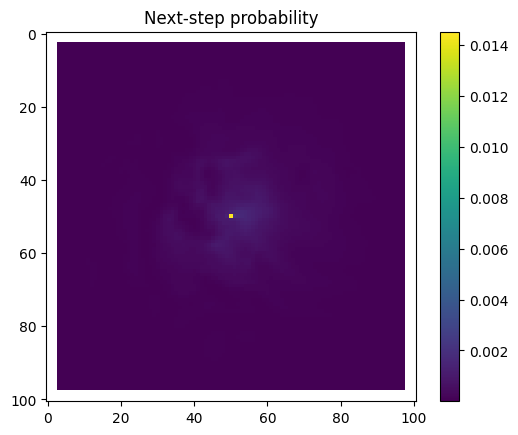

In [76]:
# -------------------------------------------------------------------------
# Switch the model to evaluation mode (e.g., disables dropout, etc.)
# -------------------------------------------------------------------------
model.eval()

# -------------------------------------------------------------------------
# Pass the inputs through the model; 'test' will have shape [batch, H, W, 2]
# -------------------------------------------------------------------------
habitat_predictions, movement_params, bearing = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))
# test = model((x1, x2, x3))
# print(test[0].shape)

# -------------------------------------------------------------------------
# Extract and exponentiate the habitat density channel
#    (at index 0 in the last dimension)
# -------------------------------------------------------------------------
hab_density = habitat_predictions.squeeze().detach().cpu().numpy()
hab_density_exp = np.exp(hab_density)
# print(np.sum(hab_density_exp))  # Debug: check the sum of exponentiated values

# -------------------------------------------------------------------------
# Create masks to remove unwanted edge cells from visualization
#    (setting them to -∞ affects the color scale in plots)
# -------------------------------------------------------------------------
x_mask = np.ones_like(hab_density)
y_mask = np.ones_like(hab_density)

x_mask[:, :3] = -np.inf
x_mask[:, 98:] = -np.inf
y_mask[:3, :] = -np.inf
y_mask[98:, :] = -np.inf

# -------------------------------------------------------------------------
# Apply the masks to the habitat density (log scale) and exponentiated version
# -------------------------------------------------------------------------
hab_density_mask = hab_density * x_mask * y_mask
hab_density_exp_mask = hab_density_exp * x_mask * y_mask

# -------------------------------------------------------------------------
# Plot and save the habitat density in log scale
# -------------------------------------------------------------------------
plt.imshow(hab_density_mask)
plt.colorbar()
plt.title('Habitat selection probability (log)')
plt.savefig(f'{output_dir}/hab_log_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the habitat density in probability (exponentiated) scale
# -------------------------------------------------------------------------
plt.imshow(hab_density_exp_mask)
plt.colorbar()
plt.title('Habitat selection probability')
plt.savefig(f'{output_dir}/hab_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Extract and exponentiate the movement density channel
#    (at index 1 in the last dimension)
# -------------------------------------------------------------------------
move_density = movement_distribution_block(movement_params, bearing)
move_density = move_density.squeeze().detach().cpu().numpy()
move_density_exp = np.exp(move_density)
# print(np.sum(move_density_exp))  # Debug: check the sum of exponentiated values

# -------------------------------------------------------------------------
# Apply the same masking strategy to movement densities
# -------------------------------------------------------------------------
move_density_mask = move_density * x_mask * y_mask
move_density_exp_mask = move_density_exp * x_mask * y_mask

# -------------------------------------------------------------------------
# Plot and save the movement density in log scale
# -------------------------------------------------------------------------
plt.imshow(move_density_mask)
plt.colorbar()
plt.title('Movement probability (log)')
plt.savefig(f'{output_dir}/move_log_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the movement density in probability (exponentiated) scale
# -------------------------------------------------------------------------
plt.imshow(move_density_exp_mask)
plt.colorbar()
plt.title('Movement probability')
plt.savefig(f'{output_dir}/move_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Compute the next-step density by adding habitat + movement (log-space)
#     Then exponentiate and normalize
# -------------------------------------------------------------------------
step_density = hab_density + move_density
step_density = step_density
step_density_exp = np.exp(step_density)
# print('Sum of step density exp = ', np.sum(step_density_exp))  # Debug

step_density_exp_norm = step_density_exp / np.sum(step_density_exp)
# print('Sum of step density exp norm = ', np.sum(step_density_exp_norm))  # Debug

# -------------------------------------------------------------------------
# Apply masks to the step densities (log and exponentiated + normalized)
# -------------------------------------------------------------------------
step_density_mask = step_density * x_mask * y_mask
step_density_exp_norm_mask = step_density_exp_norm * x_mask * y_mask

# -------------------------------------------------------------------------
# Plot and save the combined next-step probability surface in log scale
# -------------------------------------------------------------------------
plt.imshow(step_density_mask)
plt.colorbar()
plt.title('Next-step probability (log)')
plt.savefig(f'{output_dir}/step_log_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the combined next-step probability surface in probability scale
# -------------------------------------------------------------------------
plt.imshow(step_density_exp_norm_mask)
plt.colorbar()
plt.title('Next-step probability')
plt.savefig(f'{output_dir}/step_prob_id{buffalo_id}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Extracting convolution layer outputs

In the convolutional blocks, each convolutional layer learns a set of **filters** (kernels) that extract different features from the input data. In the habitat selection subnetwork, the convolution filters (and their associated bias parameters - not shown below) are the only parameters that are trained, and it is the filters that transform the set of input covariates into the habitat selection probabilities. They do this by maximising features of the inputs that correlate with observed next-steps.

For each convolutional layer, there are typically a number of filters. For the habitat selection subnetwork, we used 4 filters in the first two layers, and a single filter in the last layer. Each of these filters has a number of **channels** which correspond one-to-one with the input layers. The outputs of the filter channels are then combined to produce a feature map, with a single feature map produced for each filter. In successive layers, the feature maps become the input layers, and the filters operate on these layers. Because there are multiple filters in ech layer, they can 'specialise' in extracting different features from the input layers.

By visualizing and inspecting these filters, and the corresponding feature maps, we can:

- Gain interpretability: Understand what kind of features the network is detecting—e.g., edges, shapes, or textures.
- Debug: Check if the filters have meaningful patterns or if something went wrong (e.g., all zeros or random noise).
- Compare layers: See how early layers often learn low-level patterns while deeper layers learn more abstract features.

We will first set up some activation hooks for storing the feature maps. Activation hooks are placed at certain points within the model's forward pass and store intermediate results. We will also extract the convolution filters (which are weights of the model and as such don't require hooks - we can access them directly).

We will then run the sample covariates through the model and extract the feature maps from the habitat selection convolutional block, and plot them along with the covariates and convolution filters.

Note that there are also ReLU activation functions in the convolutional blocks, which are not shown below. These are applied to the feature maps, and set all negative values to zero. They are not learned parameters, but are part of the forward pass of the model.


## Convolutional layer 1

### Activation hook

In [77]:
# -----------------------------------------------------------
# Create a dictionary to store activation outputs
# -----------------------------------------------------------
activation = {}

def get_activation(name):
    """
    Returns a hook function that can be registered on a layer
    to capture its output (i.e., feature maps) after the forward pass.

    Args:
        name (str): The key under which the activation is stored in the 'activation' dict.
    """
    def hook(model, input, output):
        # Detach and save the layer's output in the dictionary
        activation[name] = output.detach()
    return hook

# -----------------------------------------------------------
# Register a forward hook on the first convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[0].register_forward_hook(get_activation("hab_conv1"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_prev))
habitat_predictions, movement_params, bearing = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps1 = activation["hab_conv1"].cpu()
print("Feature map shape:", feat_maps1.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps1_sample = feat_maps1[0]  # Shape: (out_channels, H, W)
num_maps1 = feat_maps1_sample.shape[0]
print("Number of feature maps:", num_maps1)



Feature map shape: torch.Size([1, 4, 101, 101])
Number of feature maps: 4


### Stack spatial and scalar (as grid) covariates

For plotting. Also create a vector of names to index over.

In [78]:
covariate_stack = torch.cat([sample_spatial_covs.detach().cpu(), scalar_maps], dim=1)
print(covariate_stack.shape)

covariate_names = ['NDVI', 'Canopy cover', 'Herbaceous vegetation', 'Slope',
                   'Hour sin1', 'Hour cos1', 'Hour sin2', 'Hour cos2', 'yday sin', 'yday cos']

torch.Size([1, 8, 101, 101])


### Extract filters and plot

Sequential(
  (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
Filters shape: torch.Size([4, 8, 3, 3])
8


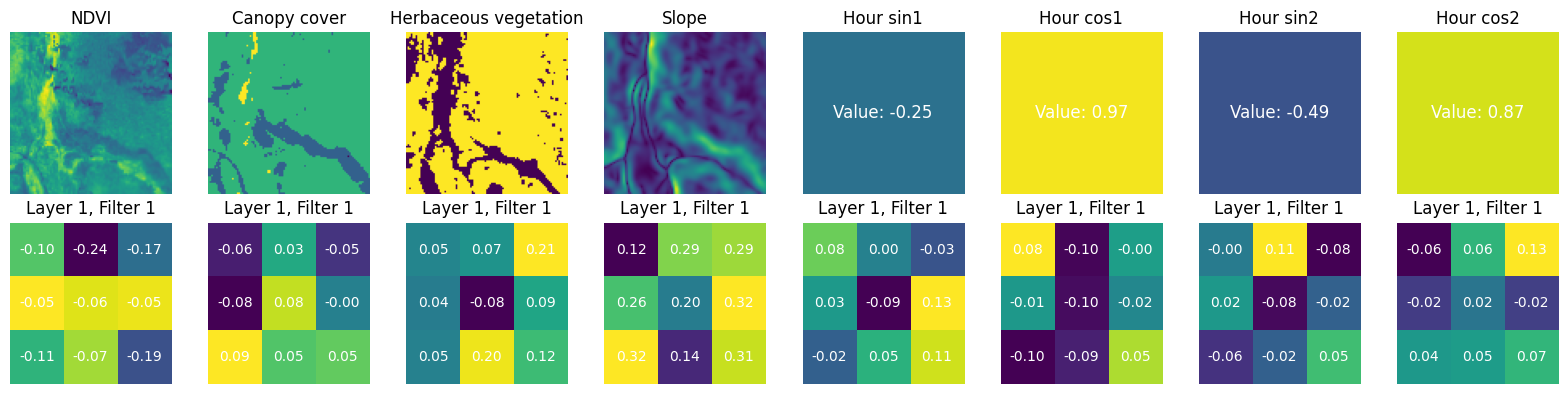

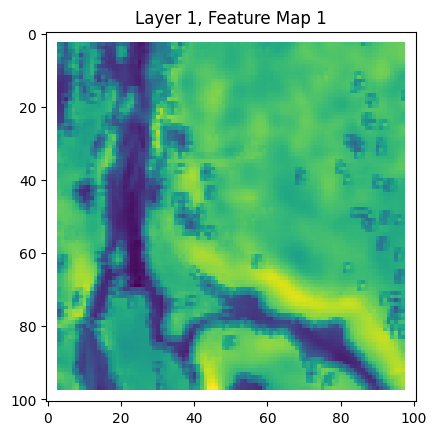

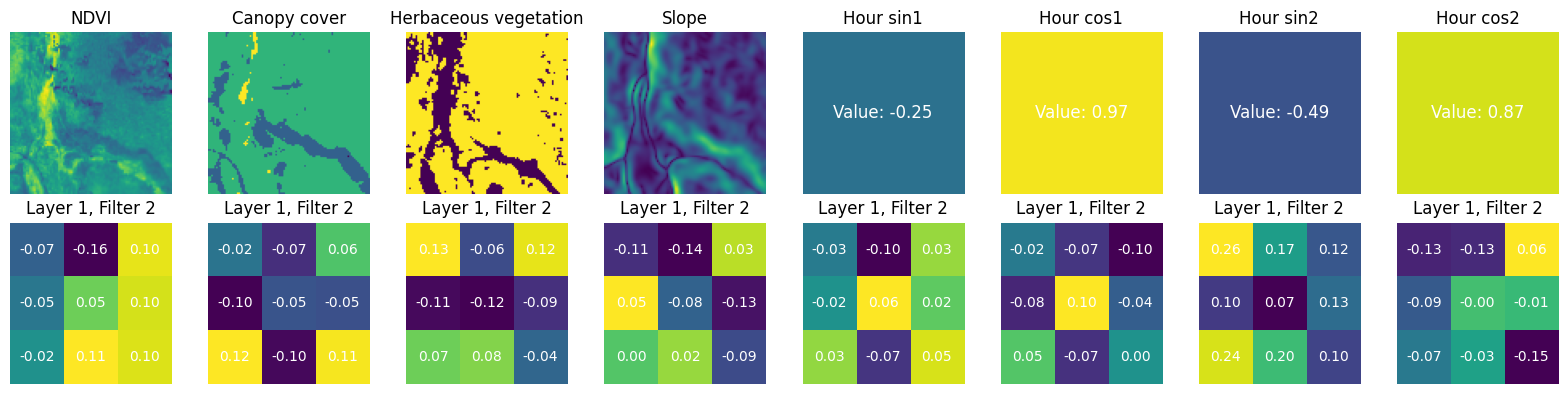

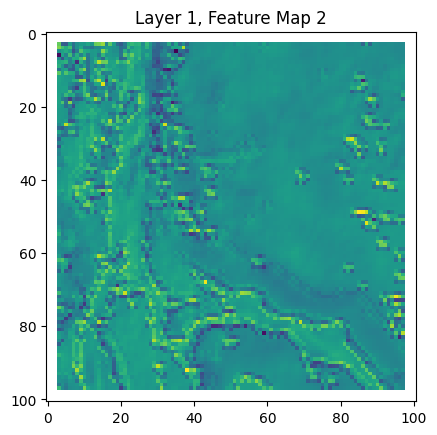

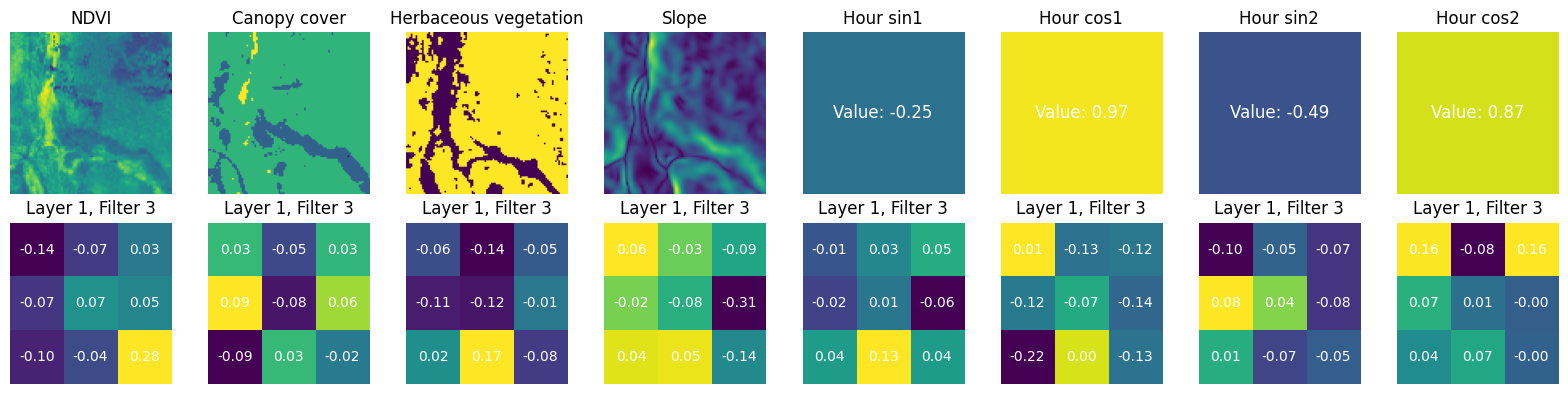

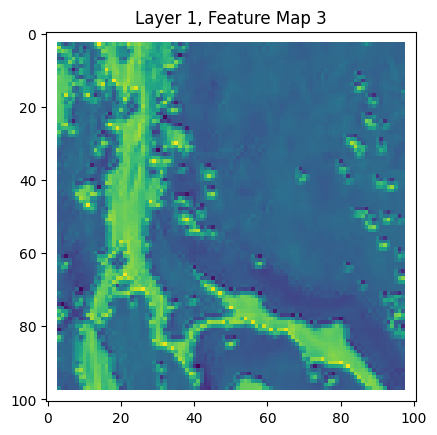

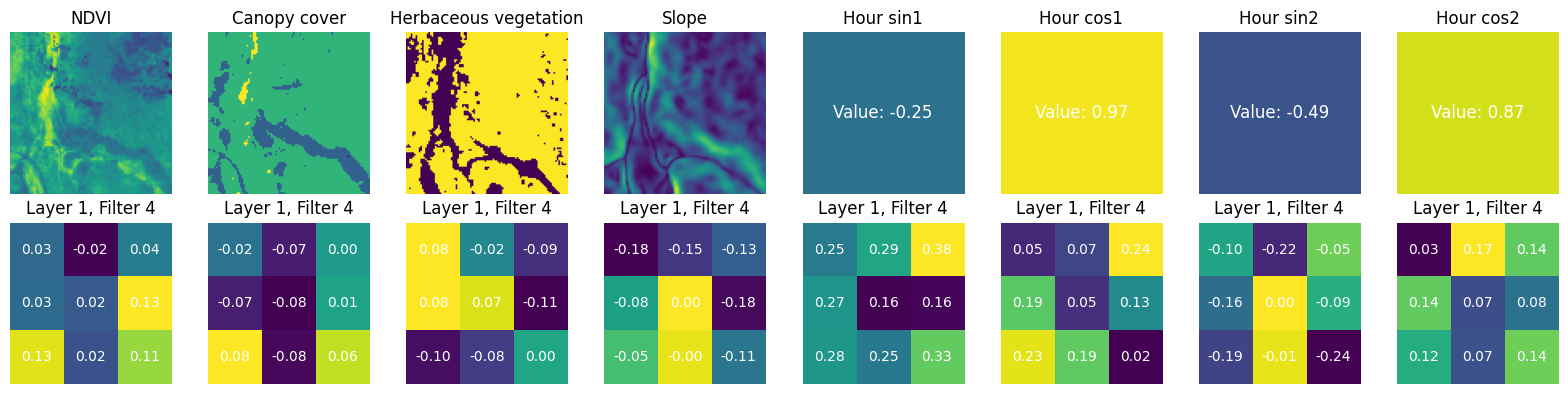

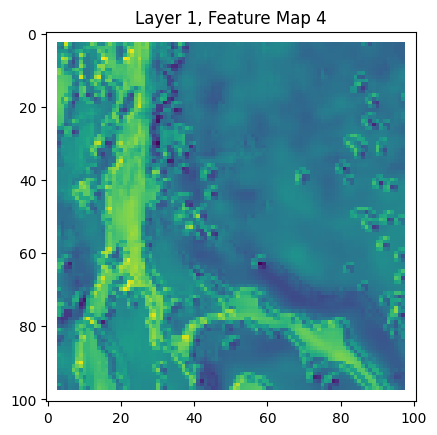

In [79]:
# -------------------------------------------------------------------------
# Check or print the convolution layer in conv_habitat (for debugging)
# -------------------------------------------------------------------------
print(model.conv_habitat.conv2d)

# -------------------------------------------------------------------------
# Set the model to evaluation mode (disables dropout, etc.)
# -------------------------------------------------------------------------
model.eval()

# -------------------------------------------------------------------------
# Extract the weights (filters) from the first convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c1 = model.conv_habitat.conv2d[0].weight.data.clone().cpu()
print("Filters shape:", filters_c1.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c1 = filters_c1.shape[1]
print(num_filters_c1)

for z in range(num_maps1):

    fig, axes = plt.subplots(2, num_filters_c1, figsize=(2*num_filters_c1, 4))
    for i in range(num_filters_c1):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f'{covariate_names[i]}')
        if i > 3:
            im1 = axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
            im1.set_clim(-1, 1)
            axes[0,i].text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
                f'Value: {round(sample_temporal_covs[0, i-4].item(), 2)}',
                ha='center', va='center', color='white', fontsize=12)

        kernel = filters_c1[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 1, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer1_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps1_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Layer 1, Feature Map {z+1}")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer1_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



## Convolutional layer 2

### Activation hook

In [80]:
# -----------------------------------------------------------
# Register a forward hook on the second convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[2].register_forward_hook(get_activation("hab_conv2"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_prev))
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps2 = activation["hab_conv2"].cpu()
print("Feature map shape:", feat_maps2.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps2_sample = feat_maps2[0]  # Shape: (out_channels, H, W)
num_maps2 = feat_maps2_sample.shape[0]
print("Number of feature maps:", num_maps2)



Feature map shape: torch.Size([1, 4, 101, 101])
Number of feature maps: 4


### Extract filters and plot

Filters shape: torch.Size([4, 4, 3, 3])
4


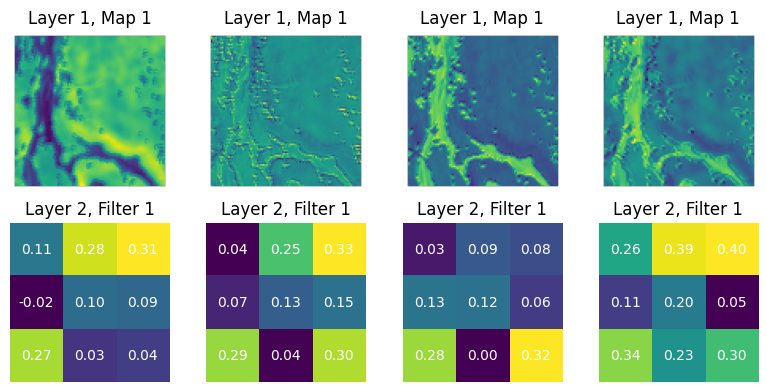

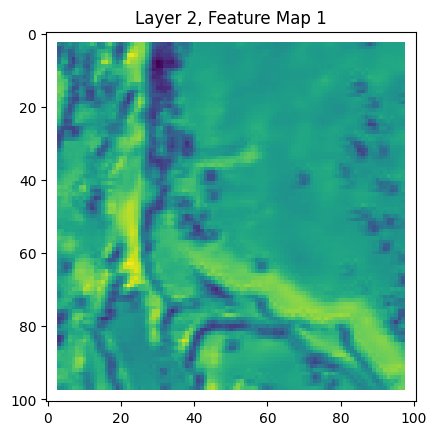

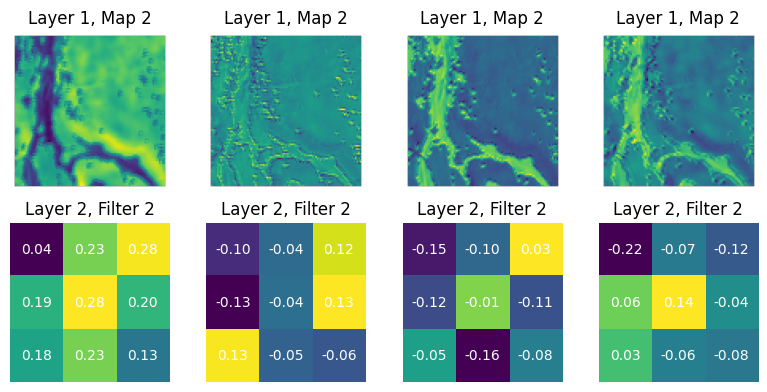

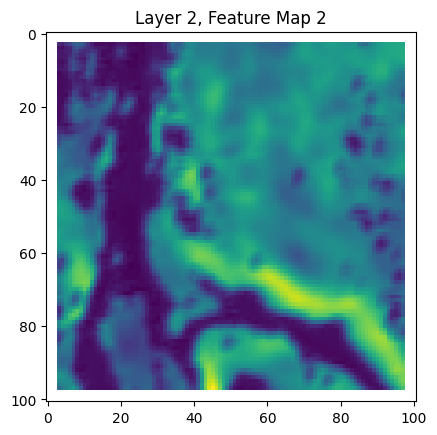

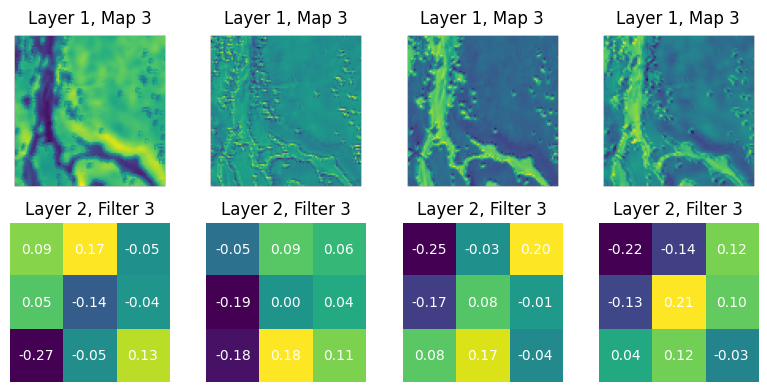

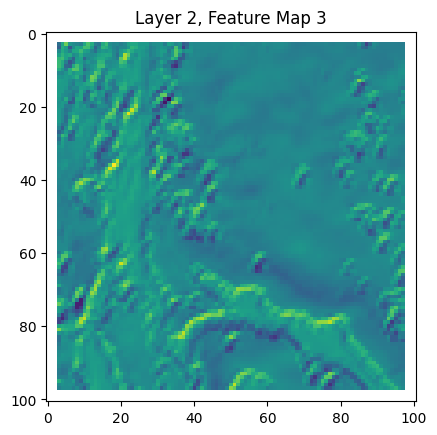

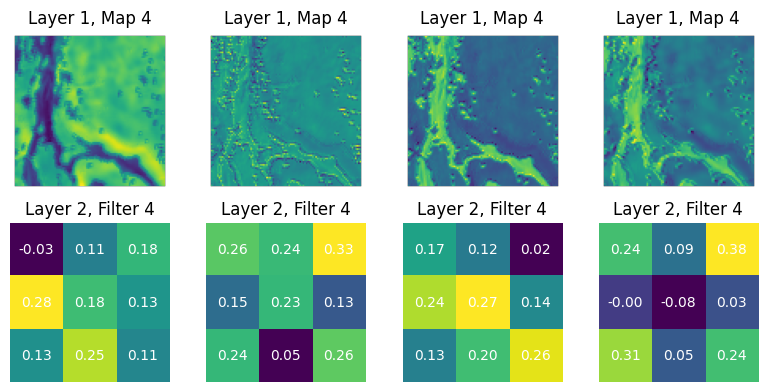

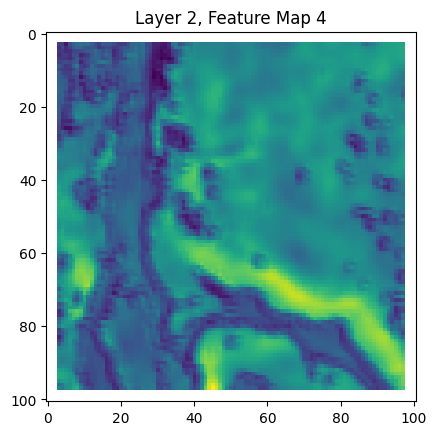

In [81]:
# -------------------------------------------------------------------------
# Extract the weights (filters) from the second convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c2 = model.conv_habitat.conv2d[2].weight.data.clone().cpu()
print("Filters shape:", filters_c2.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c2 = filters_c2.shape[1]
print(num_filters_c2)

for z in range(num_maps2):

    fig, axes = plt.subplots(2, num_filters_c2, figsize=(2*num_filters_c2, 4))
    for i in range(num_filters_c2):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(feat_maps1_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Layer 1, Map {z+1}")

        # if i > 3:
        #     im1 = axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
        #     im1.set_clim(-1, 1)
        #     axes[0,i].text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
        #         f'Value: {round(x2[0, i-4].item(), 2)}',
        #         ha='center', va='center', color='white', fontsize=12)

        kernel = filters_c2[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 2, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer2_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # 6. Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps2_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Layer 2, Feature Map {z+1}")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer2_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



## Convolutional layer 3

### Activation hook

In [82]:
# -----------------------------------------------------------
# Register a forward hook on the third convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[4].register_forward_hook(get_activation("hab_conv3"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_prev))
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps3 = activation["hab_conv3"].cpu()
print("Feature map shape:", feat_maps3.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps3_sample = feat_maps3[0]  # Shape: (out_channels, H, W)
num_maps3 = feat_maps3_sample.shape[0]
print("Number of feature maps:", num_maps3)



Feature map shape: torch.Size([1, 1, 101, 101])
Number of feature maps: 1


### Extract filters and plot

Filters shape: torch.Size([1, 4, 3, 3])
4


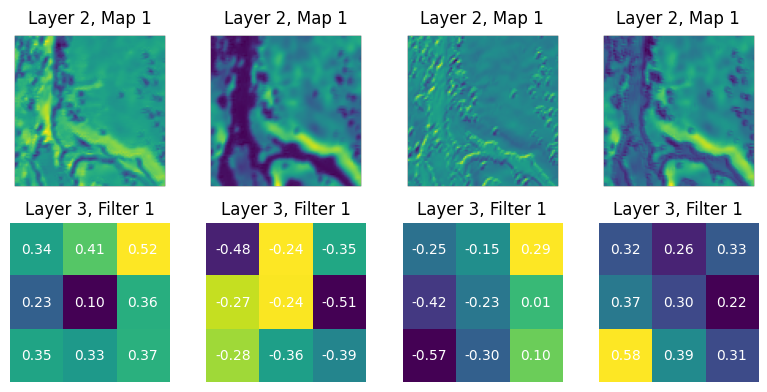

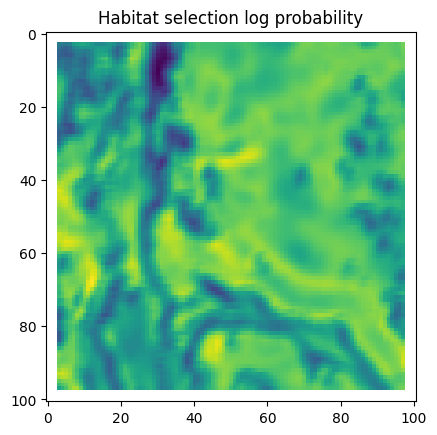

In [83]:
# -------------------------------------------------------------------------
# Extract the weights (filters) from the second convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c3 = model.conv_habitat.conv2d[4].weight.data.clone().cpu()
print("Filters shape:", filters_c3.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c3 = filters_c3.shape[1]
print(num_filters_c3)

for z in range(num_maps3):

    fig, axes = plt.subplots(2, num_filters_c3, figsize=(2*num_filters_c3, 4))
    for i in range(num_filters_c3):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(feat_maps2_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Layer 2, Map {z+1}")


        kernel = filters_c3[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 3, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer3_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # 6. Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps3_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Habitat selection log probability")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/id{buffalo_id}_conv_layer3_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



# Checking estimated movement parameters

Similarly to the convolutional layers, we can set hooks to extract the predicted movement parameters from the model, and assess how variable that is across samples.

In [84]:
torch.cuda.empty_cache()

# -------------------------------------------------------------------------
# Create a list to store the intermediate output from the fully connected
#    movement sub-network (fcn_movement_all)
# -------------------------------------------------------------------------
intermediate_output = []

def hook(module, input, output):
    """
    Hook function that captures the output of the specified layer
    (fcn_movement_all) during the forward pass.
    """
    intermediate_output.append(output)

# -------------------------------------------------------------------------
# Register the forward hook on 'fcn_movement_all', so its outputs
#    are recorded every time the model does a forward pass.
# -------------------------------------------------------------------------
hook_handle = model.fcn_movement_all.register_forward_hook(hook)

# -------------------------------------------------------------------------
# Perform a forward pass with the model in evaluation mode,
#    disabling gradient computation.
# -------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    final_output = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -------------------------------------------------------------------------
# Inspect the captured intermediate output
#    'intermediate_output[0]' corresponds to the first (and only) forward pass.
# -------------------------------------------------------------------------
print("Intermediate output shape:", intermediate_output[0].shape)
print("Intermediate output values:", intermediate_output[0][0])

# -------------------------------------------------------------------------
# Remove the hook to avoid repeated capturing in subsequent passes
# -------------------------------------------------------------------------
hook_handle.remove()

# -------------------------------------------------------------------------
# Unpack the parameters from the FCN output (assumes a specific ordering)
# -------------------------------------------------------------------------
gamma_shape1, gamma_scale1, gamma_weight1, \
gamma_shape2, gamma_scale2, gamma_weight2, \
vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
vonmises_mu2, vonmises_kappa2, vonmises_weight2 = intermediate_output[0][0]

# -------------------------------------------------------------------------
# Convert parameters from log-space (if applicable) and print them
#    Gamma and von Mises parameters
# -------------------------------------------------------------------------
# --- Gamma #1 ---
print("Gamma shape 1:", torch.exp(gamma_shape1))
print("Gamma scale 1:", torch.exp(gamma_scale1))
print("Gamma weight 1:",
      torch.exp(gamma_weight1) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

# --- Gamma #2 ---
print("Gamma shape 2:", torch.exp(gamma_shape2))
print("Gamma scale 2:", torch.exp(gamma_scale2) * 500)  # scale factor 500
print("Gamma weight 2:",
      torch.exp(gamma_weight2) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

# --- von Mises #1 ---
# % (2*np.pi) ensures the mu (angle) is wrapped within [0, 2π)
print("Von Mises mu 1:", vonmises_mu1 % (2*np.pi))
print("Von Mises kappa 1:", torch.exp(vonmises_kappa1))
print("Von Mises weight 1:",
      torch.exp(vonmises_weight1) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))

# --- von Mises #2 ---
print("Von Mises mu 2:", vonmises_mu2 % (2*np.pi))
print("Von Mises kappa 2:", torch.exp(vonmises_kappa2))
print("Von Mises weight 2:",
      torch.exp(vonmises_weight2) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))


Intermediate output shape: torch.Size([1, 12])
Intermediate output values: tensor([ 0.6969,  1.1650, -0.2842,  0.0380, -0.5987,  0.4884, -0.0571,  1.1895,
        -0.7519,  2.5368, -2.2078,  0.9091], device='cuda:0')
Gamma shape 1: tensor(2.0075, device='cuda:0')
Gamma scale 1: tensor(3.2058, device='cuda:0')
Gamma weight 1: tensor(0.3159, device='cuda:0')
Gamma shape 2: tensor(1.0387, device='cuda:0')
Gamma scale 2: tensor(274.7555, device='cuda:0')
Gamma weight 2: tensor(0.6841, device='cuda:0')
Von Mises mu 1: tensor(6.2261, device='cuda:0')
Von Mises kappa 1: tensor(3.2855, device='cuda:0')
Von Mises weight 1: tensor(0.1596, device='cuda:0')
Von Mises mu 2: tensor(2.5368, device='cuda:0')
Von Mises kappa 2: tensor(0.1099, device='cuda:0')
Von Mises weight 2: tensor(0.8404, device='cuda:0')


## Plot the movement distributions

We can use the movement parameters to plot the step length and turning angle distributions for the sample covariates.

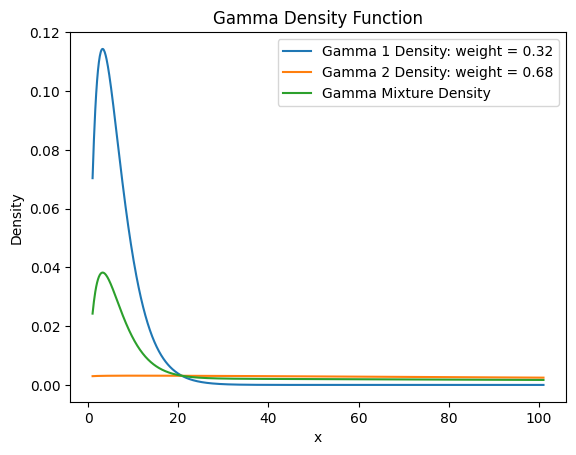

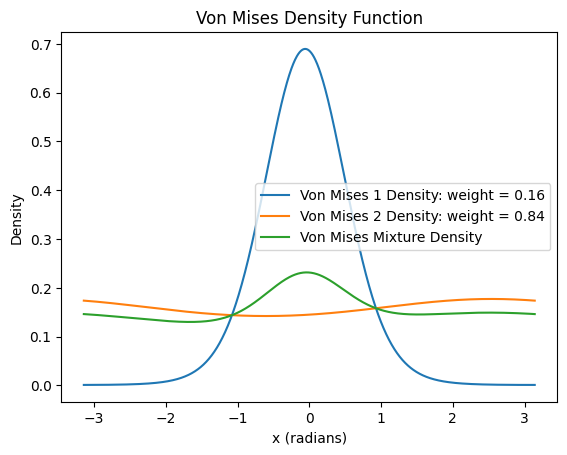

In [85]:
# -------------------------------------------------------------------------
# Define helper functions for calculating Gamma and von Mises log-densities
# -------------------------------------------------------------------------
def gamma_density(x, shape, scale):
    """
    Computes the log of the Gamma density for each value in x.

    Args:
      x (Tensor): Input values for which to compute the density.
      shape (float): Gamma shape parameter
      scale (float): Gamma scale parameter

    Returns:
      Tensor: The log of the Gamma probability density at each x.
    """
    return -1*torch.lgamma(shape) - shape*torch.log(scale) \
           + (shape - 1)*torch.log(x) - x/scale

def vonmises_density(x, kappa, vm_mu):
    """
    Computes the log of the von Mises density for each value in x.

    Args:
      x (Tensor): Input angles in radians.
      kappa (float): Concentration parameter (kappa)
      vm_mu (float): Mean direction parameter (mu)

    Returns:
      Tensor: The log of the von Mises probability density at each x.
    """
    return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


# -------------------------------------------------------------------------
# Round and display the mixture weights for the Gamma distributions
# -------------------------------------------------------------------------
gamma_weight1_recovered = torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
rounded_gamma_weight1 = round(gamma_weight1_recovered.item(), 2)

gamma_weight2_recovered = torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
rounded_gamma_weight2 = round(gamma_weight2_recovered.item(), 2)

# -------------------------------------------------------------------------
# Round and display the mixture weights for the von Mises distributions
# -------------------------------------------------------------------------
vonmises_weight1_recovered = torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
rounded_vm_weight1 = round(vonmises_weight1_recovered.item(), 2)

vonmises_weight2_recovered = torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
rounded_vm_weight2 = round(vonmises_weight2_recovered.item(), 2)


# -------------------------------------------------------------------------
# 1. Plotting the Gamma mixture distribution
#    a) Generate x values
#    b) Compute individual Gamma log densities
#    c) Exponentiate and combine using recovered weights
# -------------------------------------------------------------------------
x_values = torch.linspace(1, 101, 1000).to(device)
gamma1_density = gamma_density(x_values, torch.exp(gamma_shape1), torch.exp(gamma_scale1))
gamma2_density = gamma_density(x_values, torch.exp(gamma_shape2), torch.exp(gamma_scale2)*500)
gamma_mixture_density = gamma_weight1_recovered*torch.exp(gamma1_density) \
                        + gamma_weight2_recovered*torch.exp(gamma2_density)

# Move results to CPU and convert to NumPy for plotting
x_values_np = x_values.cpu().numpy()
gamma1_density_np = np.exp(gamma1_density.cpu().numpy())
gamma2_density_np = np.exp(gamma2_density.cpu().numpy())
gamma_mixture_density_np = gamma_mixture_density.cpu().numpy()

# -------------------------------------------------------------------------
# 2. Plot the Gamma distributions and their mixture
# -------------------------------------------------------------------------
filename_gamma_distributions = f'{output_dir}/id{buffalo_id}_gamma_distributions.png'

plt.plot(x_values_np, gamma1_density_np, label=f'Gamma 1 Density: weight = {rounded_gamma_weight1}')
plt.plot(x_values_np, gamma2_density_np, label=f'Gamma 2 Density: weight = {rounded_gamma_weight2}')
plt.plot(x_values_np, gamma_mixture_density_np, label='Gamma Mixture Density')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gamma Density Function')
plt.legend()
plt.savefig(filename_gamma_distributions, dpi=300, bbox_inches='tight')
plt.show()


# -------------------------------------------------------------------------
# 3. Plotting the von Mises mixture distribution
#    a) Generate x values from -π to π
#    b) Compute individual von Mises log densities
#    c) Exponentiate and combine using recovered weights
# -------------------------------------------------------------------------
x_values = torch.linspace(-np.pi, np.pi, 1000).to(device)
vonmises1_density = vonmises_density(x_values, torch.exp(vonmises_kappa1), vonmises_mu1)
vonmises2_density = vonmises_density(x_values, torch.exp(vonmises_kappa2), vonmises_mu2)
vonmises_mixture_density = vonmises_weight1_recovered*torch.exp(vonmises1_density) \
                           + vonmises_weight2_recovered*torch.exp(vonmises2_density)

# Move results to CPU and convert to NumPy for plotting
x_values_np = x_values.cpu().numpy()
vonmises1_density_np = np.exp(vonmises1_density.cpu().numpy())
vonmises2_density_np = np.exp(vonmises2_density.cpu().numpy())
vonmises_mixture_density_np = vonmises_mixture_density.cpu().numpy()

# -------------------------------------------------------------------------
# 4. Plot the von Mises distributions and their mixture
# -------------------------------------------------------------------------
filename_vonmises_distributions = f'{output_dir}/id{buffalo_id}_vonmises_distributions.png'

plt.plot(x_values_np, vonmises1_density_np, label=f'Von Mises 1 Density: weight = {rounded_vm_weight1}')
plt.plot(x_values_np, vonmises2_density_np, label=f'Von Mises 2 Density: weight = {rounded_vm_weight2}')
plt.plot(x_values_np, vonmises_mixture_density_np, label='Von Mises Mixture Density')
plt.xlabel('x (radians)')
plt.ylabel('Density')
plt.title('Von Mises Density Function')
# plt.ylim(0, 0.5)  # Set a limit for the y-axis
plt.legend()
plt.savefig(filename_vonmises_distributions, dpi=300, bbox_inches='tight')
plt.show()


## Generate a distribution of movement parameters

To see how variable the movement parameters are across samples, we can generate a distribution of movement parameters from a batch of samples.

We take the code from above that we used to create the DataLoader for the test data and increase the batch size (to get more samples to create the distribution from).

As we're not using the test dataset any more, we'll just put all of the samples in the same batch, and generate movement parameters for all of them.

In [86]:
# To use all of the test samples
print(f'There are {len(dataset_test)} samples in the test dataset')
bs = len(dataset_test) # batch size
dataloader_test = DataLoader(dataset=dataset_test, batch_size=bs, shuffle=True)

torch.cuda.empty_cache()

There are 1010 samples in the test dataset


Take all of the samples from the test dataset and put them in a single batch.

In [87]:
# -----------------------------------------------------------
# Fetch a batch of data from the training dataloader
# -----------------------------------------------------------
x1_batch, x2_batch, x3_batch, labels = next(iter(dataloader_test))

# Move the input batches to the same device as the model
x1_batch = x1_batch.to(device)
x2_batch = x2_batch.to(device)
x3_batch = x3_batch.to(device)

# -----------------------------------------------------------
# Register a forward hook to capture the outputs
#    from 'fcn_movement_all' during the forward pass
# -----------------------------------------------------------
hook_handle = model.fcn_movement_all.register_forward_hook(hook)

# -----------------------------------------------------------
# Perform a forward pass in evaluation mode to generate
#    and capture the sub-network's outputs in 'intermediate_output'
# -----------------------------------------------------------
model.eval()  # Disables certain layers like dropout

# Pass the batch through the model
final_output = model((x1_batch, x2_batch, x3_batch))

# -----------------------------------------------------------
# Prepare lists to store the distribution parameters
#    for each sample in the batch
# -----------------------------------------------------------
gamma_shape1_list = []
gamma_scale1_list = []
gamma_weight1_list = []
gamma_shape2_list = []
gamma_scale2_list = []
gamma_weight2_list = []
vonmises_mu1_list = []
vonmises_kappa1_list = []
vonmises_weight1_list = []
vonmises_mu2_list = []
vonmises_kappa2_list = []
vonmises_weight2_list = []

# -----------------------------------------------------------
# Extract parameters from 'intermediate_output'
#    for every sample in the batch
# -----------------------------------------------------------
for batch_output in intermediate_output:
    # Each 'batch_output' corresponds to one forward pass;
    # it might contain multiple samples if the batch size > 1
    for sample_output in batch_output:
        # Unpack the 12 parameters of the Gamma and von Mises mixtures
        gamma_shape1, gamma_scale1, gamma_weight1, \
        gamma_shape2, gamma_scale2, gamma_weight2, \
        vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
        vonmises_mu2, vonmises_kappa2, vonmises_weight2 = sample_output

        # Convert log-space parameters to real space, then store
        gamma_shape1_list.append(torch.exp(gamma_shape1).item())
        gamma_scale1_list.append(torch.exp(gamma_scale1).item())
        gamma_weight1_list.append(
            (torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
        )
        gamma_shape2_list.append(torch.exp(gamma_shape2).item())
        gamma_scale2_list.append((torch.exp(gamma_scale2)*500).item())  # scale factor 500
        gamma_weight2_list.append(
            (torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
        )
        vonmises_mu1_list.append((vonmises_mu1 % (2*np.pi)).item())
        vonmises_kappa1_list.append(torch.exp(vonmises_kappa1).item())
        vonmises_weight1_list.append(
            (torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
        )
        vonmises_mu2_list.append((vonmises_mu2 % (2*np.pi)).item())
        vonmises_kappa2_list.append(torch.exp(vonmises_kappa2).item())
        vonmises_weight2_list.append(
            (torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
        )


### Plot the distribution of movement parameters

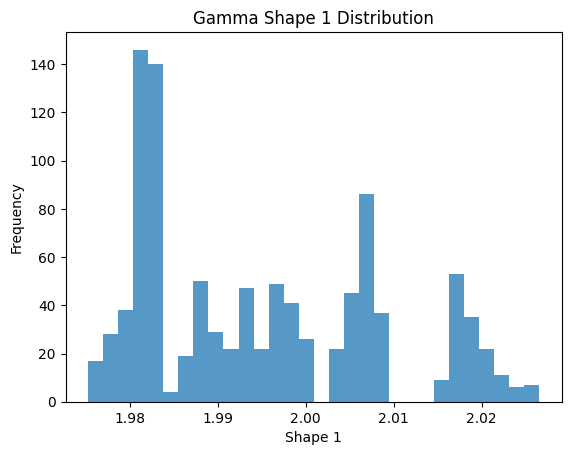

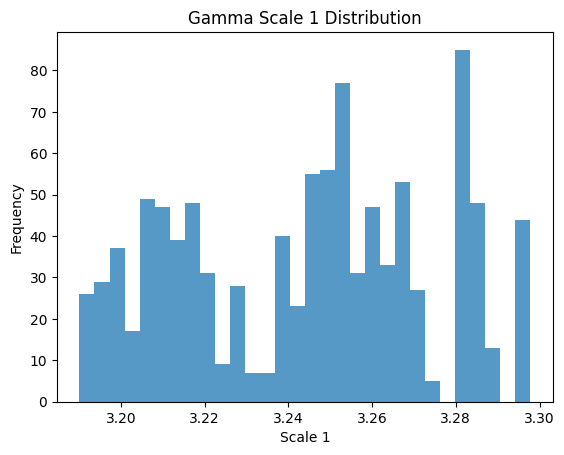

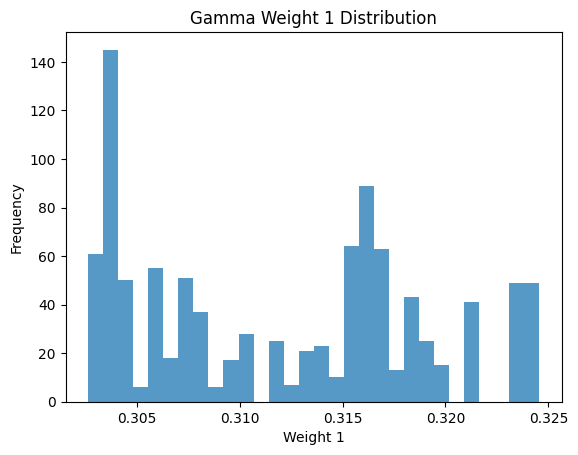

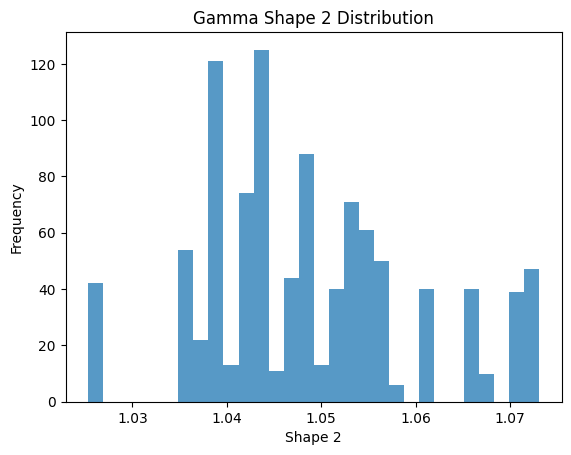

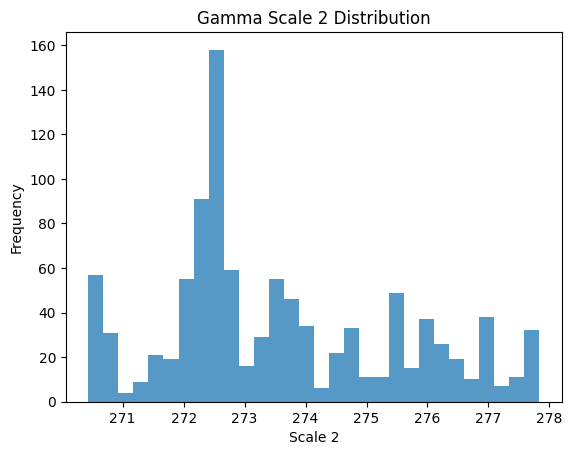

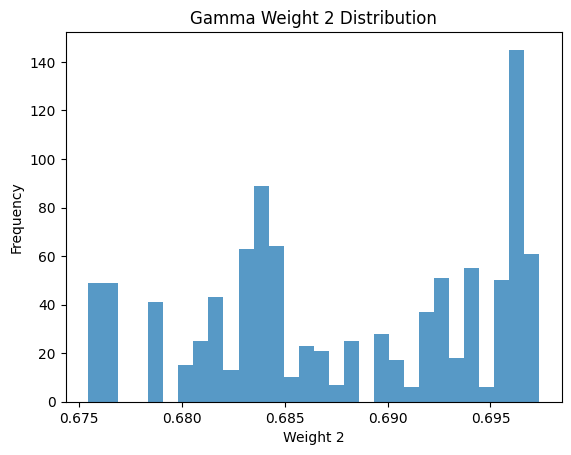

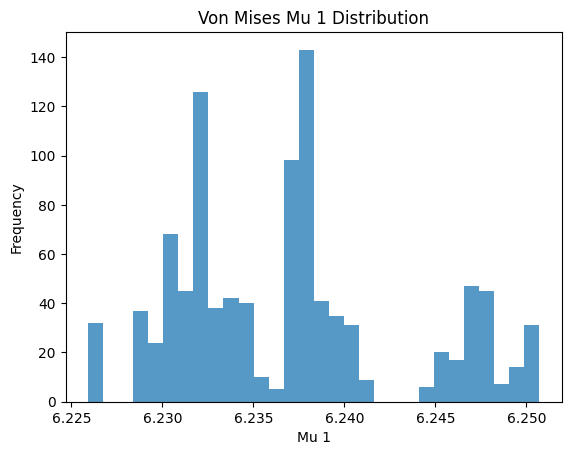

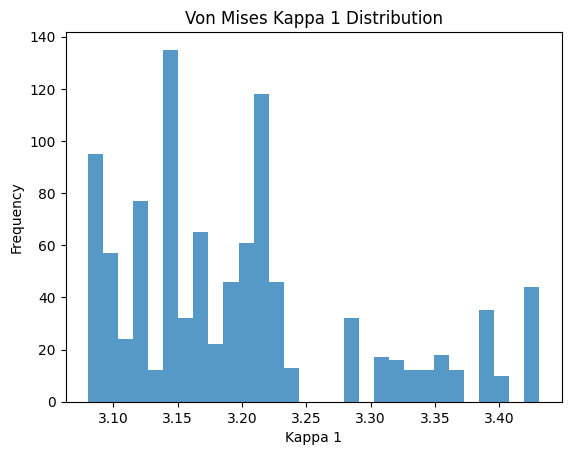

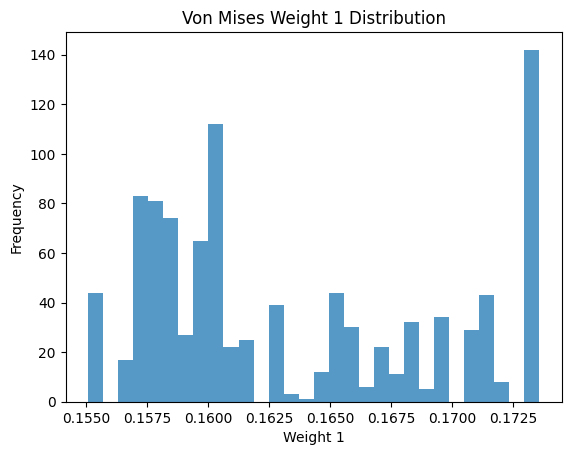

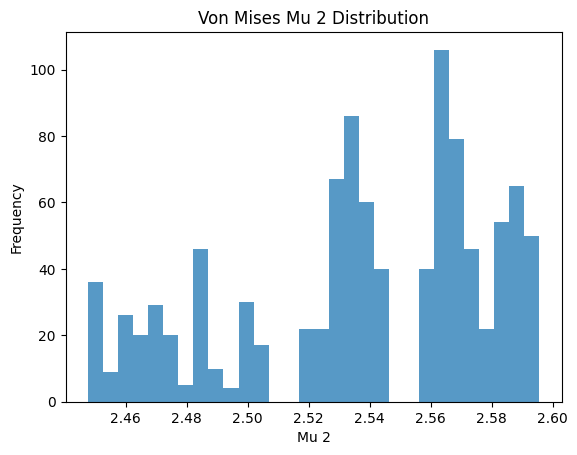

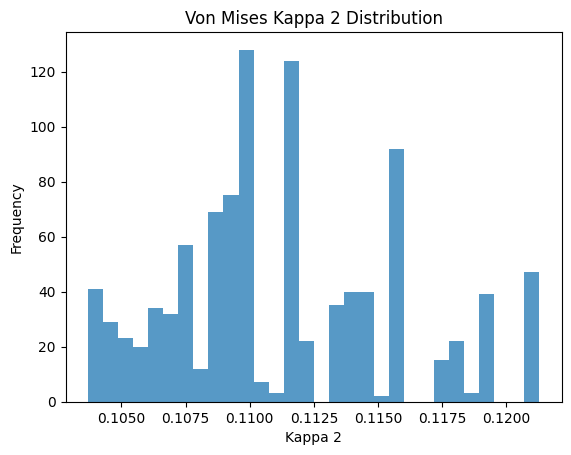

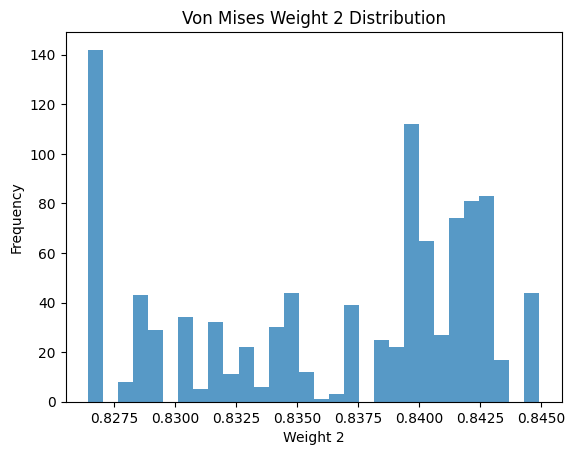

In [88]:
# -----------------------------------------------------------
# Define a helper function to plot histograms
#    for the collected parameters
# -----------------------------------------------------------
def plot_histogram(data, title, xlabel):
    """
    Plots a histogram of the provided data.

    Args:
        data (list): Data points to plot in a histogram.
        title (str): Title of the histogram plot.
        xlabel (str): X-axis label.
    """
    plt.figure()
    plt.hist(data, bins=30, alpha=0.75)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')

    # Generate a filename from the title (replace spaces with underscores)
    filename = title.replace(' ', '_') + '.png'
    filepath = os.path.join(output_dir, filename)

    # Save the figure
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()  # Close the figure to free memory

# -----------------------------------------------------------
# Plot histograms for each parameter distribution
# -----------------------------------------------------------
plot_histogram(gamma_shape1_list, 'Gamma Shape 1 Distribution', 'Shape 1')
plot_histogram(gamma_scale1_list, 'Gamma Scale 1 Distribution', 'Scale 1')
plot_histogram(gamma_weight1_list, 'Gamma Weight 1 Distribution', 'Weight 1')
plot_histogram(gamma_shape2_list, 'Gamma Shape 2 Distribution', 'Shape 2')
plot_histogram(gamma_scale2_list, 'Gamma Scale 2 Distribution', 'Scale 2')
plot_histogram(gamma_weight2_list, 'Gamma Weight 2 Distribution', 'Weight 2')
plot_histogram(vonmises_mu1_list, 'Von Mises Mu 1 Distribution', 'Mu 1')
plot_histogram(vonmises_kappa1_list, 'Von Mises Kappa 1 Distribution', 'Kappa 1')
plot_histogram(vonmises_weight1_list, 'Von Mises Weight 1 Distribution', 'Weight 1')
plot_histogram(vonmises_mu2_list, 'Von Mises Mu 2 Distribution', 'Mu 2')
plot_histogram(vonmises_kappa2_list, 'Von Mises Kappa 2 Distribution', 'Kappa 2')
plot_histogram(vonmises_weight2_list, 'Von Mises Weight 2 Distribution', 'Weight 2')

# -----------------------------------------------------------
# Remove the hook to stop capturing outputs
#    in subsequent forward passes
# -----------------------------------------------------------
hook_handle.remove()

# Validate the predictions from the model

We want to assess how well the model is generating movement, habitat selection and next-step probabilities, so we will extract those probabilities at the location of each observed step.

## Importing spatial data

Instead of importing the stacks of local layers (one for each step), here we want to import the spatial covariates for the extent we want to simulate over. We use an extent that covers all of the observed locations, which refer to as the 'landscape'.

## NDVI

We have monthly NDVI layers for 2018 and 2019, which we import as a stack. The files don't import with a time component, so we will use a function further down that indexes them correctly.

In [89]:
# for monthly NDVI
file_path = f'{base_path}/mapping/cropped rasters/ndvi_monthly.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    ndvi_landscape = src.read([i for i in range(1, src.count + 1)])
    # Get the metadata of the raster
    ndvi_meta = src.meta
    raster_transform = src.transform

    # Print the metadata to check for time component
    print("Metadata:", ndvi_meta)

    # Check for specific time-related metadata
    if 'TIFFTAG_DATETIME' in src.tags():
        print("Time component found:", src.tags()['TIFFTAG_DATETIME'])
    else:
        print("No explicit time component found in metadata.")

# the rasters don't contain a time component, so we will use a function later to index the layers correctly

Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}
No explicit time component found in metadata.


### Prepare the NDVI data

There are a few things we need to do to prepare the landscape layers.

First, we need to ensure that there are no NA values in the data. For NDVI we will replace any NA values with -1 (which denotes water), as in our case that is typically why they were set to NA.

Secondly, the model expects the covariates to on *the same scale as the training data*. We will therefore scale the NDVI data using the same max and min scaling parameters as the training data. To get these, there are some min and max print statements in the `deepSSF_train.ipynb` script. When we plot the NDVI data below we will see that the values will no longer range from 0 to 1, which is because there are values in the landscape layers that are outside of the range of the training data.

NDVI metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Affine transformation parameters:
| 25.00, 0.00, 0.00|
| 0.00,-25.00,-1406000.00|
| 0.00, 0.00, 1.00|


Shap

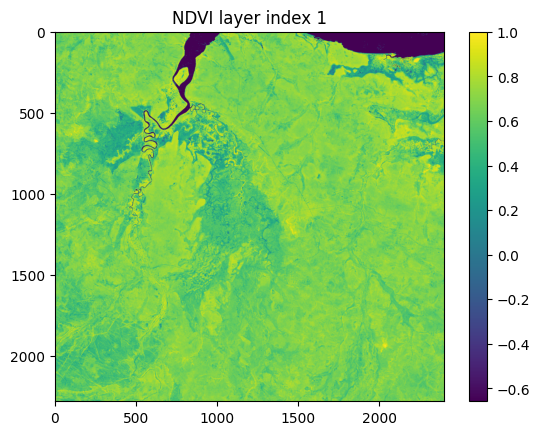

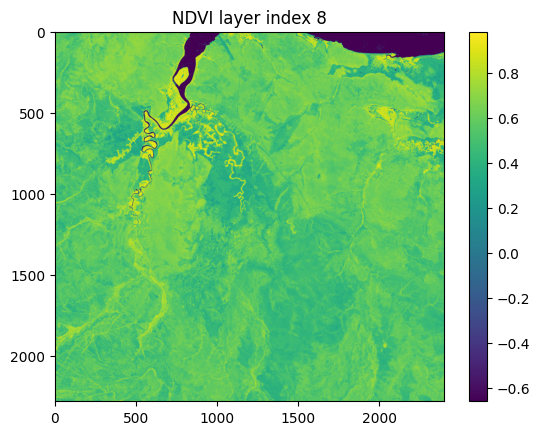

In [90]:
# Check the coordinate reference system
print("NDVI metadata:")
print(ndvi_meta)
print("\n")

# Have a look at the affine transformation parameters that are used to convert pixel
# coordinates to geographic coordinates and vice versa
print("Affine transformation parameters:")
print(raster_transform)
print("\n")

# Check the shape (layers, row, columns) of the raster
print("Shape of the raster:")
print(ndvi_landscape.shape)

# Replace NaNs in the original array with -1, which represents water
ndvi_landscape = np.nan_to_num(ndvi_landscape, nan=-1.0)

# from the stack of local layers (training data)
ndvi_max = 0.8220
ndvi_min = -0.2772

# Convert the numpy array to a PyTorch tensor
ndvi_landscape_tens = torch.from_numpy(ndvi_landscape)

# Normalizing the data
ndvi_landscape_norm = (ndvi_landscape_tens - ndvi_min) / (ndvi_max - ndvi_min)

# Show two example layers of the scaled NDVI data
layer_index = 1
plt.imshow(ndvi_landscape_norm[layer_index,:,:].numpy())
plt.colorbar()
plt.title(f'NDVI layer index {layer_index}')
plt.show()

layer_index = 8
plt.imshow(ndvi_landscape_norm[layer_index,:,:].numpy())
plt.colorbar()
plt.title(f'NDVI layer index {layer_index}')
plt.show()

## Canopy cover

Canopy cover is just a single static layer.

In [91]:
# Path to the canopy cover raster file
file_path = f'{base_path}/mapping/cropped rasters/canopy_cover.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    canopy_landscape = src.read(1)
    # Get the metadata of the raster
    canopy_meta = src.meta

### Prepare the canopy cover data

As with the NDVI data, we need to ensure that there are no NA values in the data.

As the canopy cover values in the landscape layer are within the same range as the training data, we see that the values range from 0 to 1.

Canopy metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of canopy raster:
(2280, 2400)


Number of NA values in the canopy raster:
0


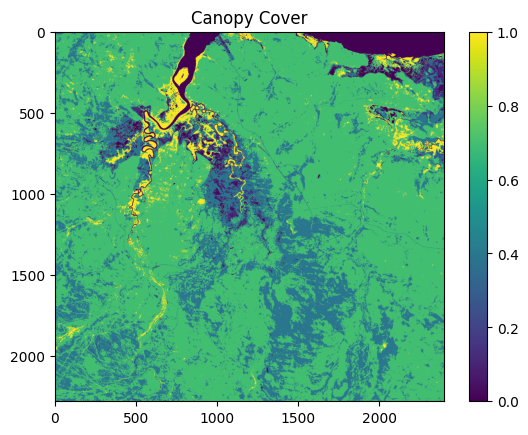

In [92]:
# Check the canopy metadata:
print("Canopy metadata:")
print(canopy_meta)
print("\n")

# Check the shape (rows, columns) of the canopy raster:
print("Shape of canopy raster:")
print(canopy_landscape.shape)
print("\n")

# Check for NA values in the canopy raster:
print("Number of NA values in the canopy raster:")
print(np.isnan(canopy_landscape).sum())

# Define the maximum and minimum canopy values from the stack of local layers:
canopy_max = 82.5000
canopy_min = 0.0

# Convert the canopy data from a NumPy array to a PyTorch tensor:
canopy_landscape_tens = torch.from_numpy(canopy_landscape)

# Normalise the canopy data:
canopy_landscape_norm = (canopy_landscape_tens - canopy_min) / (canopy_max - canopy_min)

# Visualise the normalised canopy cover:
plt.imshow(canopy_landscape_norm.numpy())
plt.colorbar()
plt.title('Canopy Cover')
plt.show()


## Herbaceous vegetation

In [93]:
# Path to the herbaceous vegetation raster file
file_path = f'{base_path}/mapping/cropped rasters/veg_herby.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    herby_landscape = src.read(1)
    # Get the metadata of the raster
    herby_meta = src.meta

Herbaceous metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of herbaceous raster:
(2280, 2400)


Number of NA values in the herbaceous ve

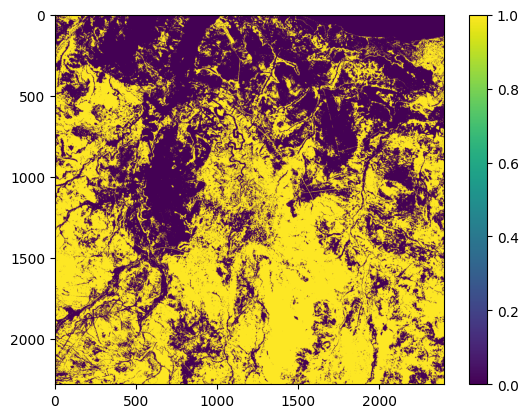

In [94]:
# Check the herbaceous metadata:
print("Herbaceous metadata:")
print(herby_meta)
print("\n")

# Check the shape (rows, columns) of the herbaceous raster:
print("Shape of herbaceous raster:")
print(herby_landscape.shape)
print("\n")

# Check for NA values in the herby raster:
print("Number of NA values in the herbaceous vegetation raster:")
print(np.isnan(herby_landscape).sum())

# Define the maximum and minimum herbaceous values from the stack of local layers:
herby_max = 1.0
herby_min = 0.0

# Convert the herbaceous data from a NumPy array to a PyTorch tensor:
herby_landscape_tens = torch.from_numpy(herby_landscape)

# Normalize the herbaceous data:
herby_landscape_norm = (herby_landscape_tens - herby_min) / (herby_max - herby_min)

# Visualize the normalised herbaceous cover:
plt.imshow(herby_landscape_norm.numpy())
plt.colorbar()
plt.show()


## Slope

In [95]:
# Path to the slope raster file
file_path = f'{base_path}/mapping/cropped rasters/slope.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    slope_landscape = src.read(1)
    # Get the metadata of the raster
    slope_meta = src.meta

Slope metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of slope landscape raster:
(2280, 2400)


Number of NA values in the slope raster:
9356


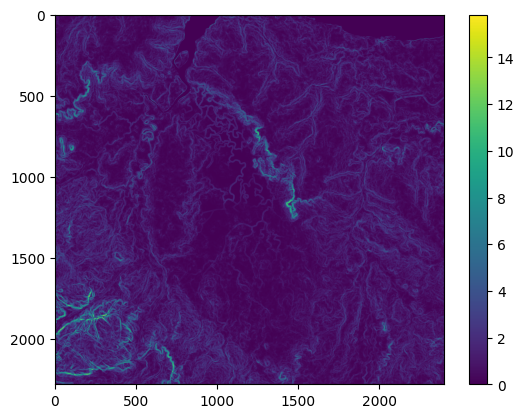

In [96]:
# Check the slope metadata:
print("Slope metadata:")
print(slope_meta)
print("\n")

# Check the shape (rows, columns) of the slope landscape raster:
print("Shape of slope landscape raster:")
print(slope_landscape.shape)
print("\n")

# Check for NA values in the slope raster:
print("Number of NA values in the slope raster:")
print(np.isnan(slope_landscape).sum())

# Replace NaNs in the slope array with 0.0:
slope_landscape = np.nan_to_num(slope_landscape, nan=0.0)

# Define the maximum and minimum slope values from the stack of local layers:
slope_max = 12.2981
slope_min = 0.0006

# Convert the slope landscape data from a NumPy array to a PyTorch tensor:
slope_landscape_tens = torch.from_numpy(slope_landscape)

# Normalize the slope landscape data:
slope_landscape_norm = (slope_landscape_tens - slope_min) / (slope_max - slope_min)

# Visualize the slope landscape (note: displaying the original tensor, not the normalised data):
plt.imshow(slope_landscape_tens.numpy())
plt.colorbar()
plt.show()


# Subset function (with padding)

Now that we have our landscape layers imported, we need a way to crop out the local layers that can be fed into the deepSSF model as covariates.

We will use the same subset function as in the simulation script, which we stored in the `deepSSF_utils.py` script. This function will take the landscape layers and a set of coordinates, and return the local layers for those coordinates.

This function also has padding for if the simulated individual was to go off the edge of the landscape, which we retain here (although we won't need that functionality).

In [97]:
subset_raster = deepSSF_utils.subset_raster_with_padding_torch

### Testing the subset function

Use the subset function to crop out the local layers for all covariates. Try different locations using the x and y coordinates, which are in geographic coordinates (x = easting/longitude, y = northing/latitude).

Text(0.5, 1.0, 'Slope Subset')

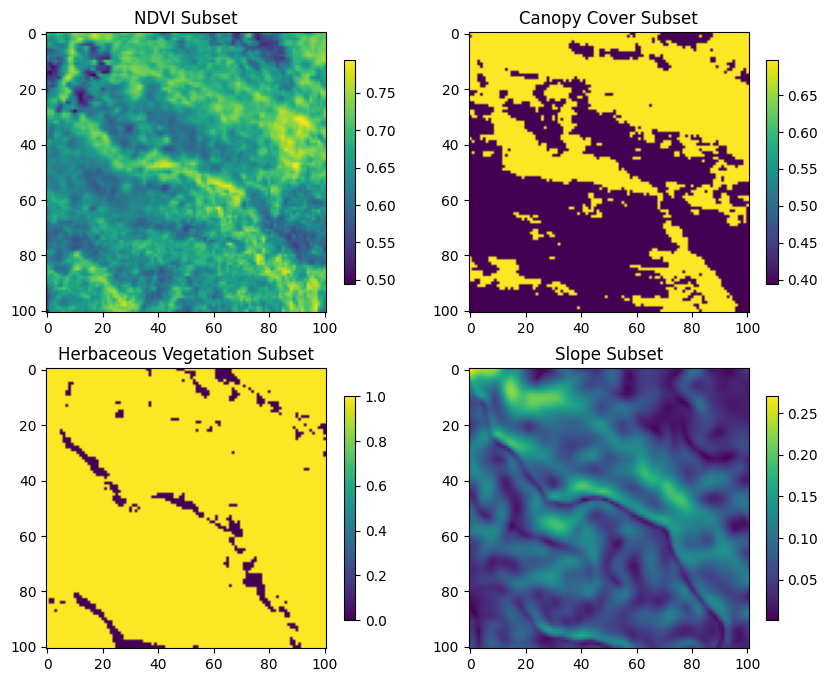

In [98]:
# Pick a location (x, y) from the buffalo DataFrame
x = buffalo_df['x1_'].iloc[0]
y = buffalo_df['y1_'].iloc[0]

# Define the size of the window to extract
window_size = 101

# Select the NDVI layer index
which_ndvi = 1

# Extract subsets from various raster layers using the custom function.
# Each call centres the window at the specified (x, y) location and applies padding where necessary.
ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[which_ndvi, :, :],
                                                x, y, window_size, raster_transform)
canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm,
                                                  x, y, window_size, raster_transform)
herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm,
                                                 x, y, window_size, raster_transform)
slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm,
                                                 x, y, window_size, raster_transform)

# Create a 2x2 grid of subplots with a fixed figure size.
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot the NDVI subset.
im0 = axs[0, 0].imshow(ndvi_subset.numpy(), cmap='viridis')
fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)
axs[0, 0].set_title('NDVI Subset')

# Plot the Canopy Cover subset.
im1 = axs[0, 1].imshow(canopy_subset.numpy(), cmap='viridis')
fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)
axs[0, 1].set_title('Canopy Cover Subset')

# Plot the Herbaceous Vegetation subset.
im2 = axs[1, 0].imshow(herby_subset.numpy(), cmap='viridis')
fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)
axs[1, 0].set_title('Herbaceous Vegetation Subset')

# Plot the Slope subset.
im3 = axs[1, 1].imshow(slope_subset.numpy(), cmap='viridis')
fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)
axs[1, 1].set_title('Slope Subset')

## Create a mask for edge cells

Due to the padding at the edges of the covariates, convolutional layers create artifacts that can affect the colour scale of the predictions when plotting. To avoid this, we will create a mask that we can apply to the predictions to remove the edge cells.

In [99]:
# Create a mask to remove the edge values for plotting
# (as it affects the colour scale)
x_mask = np.ones_like(ndvi_subset)
y_mask = np.ones_like(ndvi_subset)

# Mask out bordering cells
x_mask[:, :3] = -np.inf
x_mask[:, 98:] = -np.inf
y_mask[:3, :] = -np.inf
y_mask[98:, :] = -np.inf

# Setup simulation parameters

To get the simulation running we need a few extra functions.

Firstly, we need to index the NDVI layers correctly, based on the time of the simulated location. We'll do this by creating a function that takes day of the year of the simulated location and returns the correct index for the NDVI layers.

Recall that Python indexes from 0, so when the month_index is equal to 2 for instance, this will index the third layer, which is for March.

In [100]:
# Create a mapping from day of the year to month index
def day_to_month_index(day_of_year):
    # Calculate the year and the day within that year
    base_date = datetime(2018, 1, 1) # base date for the calculation, which is when the NDVI layers start
    date = base_date + timedelta(days=int(day_of_year) - 1)
    year_diff = date.year - base_date.year
    month_index = (date.month - 1) + (year_diff * 12)  # month index (0-based, accounting for year change)
    return month_index

yday = 70 # day of the year, which is March 11th
month_index = day_to_month_index(yday)
print(month_index)

2


# Next-step probability values

We can now calculate the next-step probabilities for each observed step. As we generate habitat selection, movement and next-step probability surfaces, we can get the predicted probability values for each one, which can be compared to the respective process in the SSF.

The process for generating the next-step probabilities is as follows:

1. Get the current location of the individual
2. Crop out the local layers for the current location
3. Run the model of the local layers to get the habitat selection, movement and next-step probability surfaces
4. Get the predicted probability values at the location of the next step
5. Store the predicted probability values and export them as a csv for comparison with the SSF

First, select the data to generate prediction values for. For testing the function we can select a subset.

In [101]:
# To select a subset of samples to test the function
# test_data = buffalo_df.iloc[0:10]

# To select all of the data
test_data = buffalo_df

# Get the number of samples in the test data
n_samples = len(test_data)
print(f'Number of samples: {n_samples}')

# Create empty vectors to store the predicted probabilities
habitat_probs = np.repeat(0., n_samples)
move_probs = np.repeat(0., n_samples)
next_step_probs = np.repeat(0., n_samples)


Number of samples: 10103


### Instantiate the movement density function

In [102]:
movement_density_block = Params_to_Density_Block(params).to(device)

## Loop over each step

In [103]:
# Create directory for saving prediction images
os.makedirs(f'{output_dir}/prediction_images', exist_ok=True)

# Start at 1 so the bearing at t - 1 is available
for i in range(1, n_samples):
# for i in range(1, 4):

  sample = test_data.iloc[i]

  # Current location (x1, y1)
  x = sample['x1_']
  y = sample['y1_']

  # Convert geographic coordinates to pixel coordinates
  px, py = ~raster_transform * (x, y)
  # print('px and py are ', px, py) # Debugging

  # Next step location (x2, y2)
  x2 = sample['x2_']
  y2 = sample['y2_']

  # Convert geographic coordinates to pixel coordinates
  px2, py2 = ~raster_transform * (x2, y2)
  # print('px2 and py2 are ', px2, py2) # Debugging

  # The difference in x and y coordinates
  d_x = x2 - x
  d_y = y2 - y
  # print('d_x and d_y are ', d_x, d_y) # Debugging

  # The difference in pixel coordinates
  d_px = px2 - px
  d_py = py2 - py
  # print('d_px and d_py are ', d_px, d_py) # Debugging

  # Temporal covariates
  hour_t2_sin1 = sample['hour_t2_sin1']
  hour_t2_cos1 = sample['hour_t2_cos1']
  hour_t2_sin2 = sample['hour_t2_sin2']
  hour_t2_cos2 = sample['hour_t2_cos2']
  yday_t2_sin = sample['yday_t2_sin']
  yday_t2_cos = sample['yday_t2_cos']

  # Step length and turning angle
  step_length = torch.tensor(sample['sl']).float()
  turn_angle = torch.tensor(sample['ta']).float()

  # Bearing of previous step (t - 1)
  bearing = sample['bearing_tm1']

  # Hour of the day (for saving the plot)
  hour_t2 = sample['hour_t2']

  # Day of the year
  yday = sample['yday_t2']

  # Convert day of the year to month index
  month_index = day_to_month_index(yday)
  # print(month_index)

  # Extract the subset of the covariates at the location of x1, y1
  # NDVI
  ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[month_index,:,:],
                                                  x, y,
                                                  window_size,
                                                  raster_transform)

  # Canopy cover
  canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm,
                                                    x, y,
                                                    window_size,
                                                    raster_transform)

  # Herbaceous vegetation
  herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm,
                                                   x, y,
                                                   window_size,
                                                   raster_transform)

  # Slope
  slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm,
                                                   x, y,
                                                   window_size,
                                                   raster_transform)

  # Location of the current step in local pixel coordinates
  px_subset = px - origin_x
  py_subset = py - origin_y
  # print('px_subset and py_subset are ', px_subset, py_subset) # Debugging

  # Location of the next step in local pixel coordinates
  px2_subset = px2 - origin_x
  py2_subset = py2 - origin_y
  # print('px2_subset and py2_subset are ', px2_subset, py2_subset, '\n') # Debugging

  # print(int(py2_subset), int(px2_subset))

  # Location of the next step in local pixel coordinates
  px2_subset_corrected = (px2 - px) + (px - origin_x)
  py2_subset_corrected = (py2 - py) + (py - origin_y)
  # print('px2_subset_corrected and py2_subset_corrected are ', px2_subset_corrected, py2_subset_corrected, '\n') # Debugging

  # Extract the value of the covariates at the location of x2, y2
  # value = ndvi_subset.detach().cpu().numpy()[(int(py2_subset), int(px2_subset))]

  # Stack the channels along a new axis
  x1 = torch.stack([ndvi_subset, canopy_subset, herby_subset, slope_subset], dim=0)

  # Add a batch dimension (required to be the correct dimension for the model)
  x1 = x1.unsqueeze(0).to(device)
  # print(x1.shape)

  # Convert lists to PyTorch tensors
  hour_t2_sin1_tensor = torch.tensor(hour_t2_sin1).float()
  hour_t2_cos1_tensor = torch.tensor(hour_t2_cos1).float()
  hour_t2_sin2_tensor = torch.tensor(hour_t2_sin2).float()
  hour_t2_cos2_tensor = torch.tensor(hour_t2_cos2).float()
  yday_t2_sin_tensor = torch.tensor(yday_t2_sin).float()
  yday_t2_cos_tensor = torch.tensor(yday_t2_cos).float()

  # # Stack tensors
  # x2 = torch.stack((hour_t2_sin1_tensor.unsqueeze(0),
  #                   hour_t2_cos1_tensor.unsqueeze(0),
  #                   hour_t2_sin2_tensor.unsqueeze(0),
  #                   hour_t2_cos2_tensor.unsqueeze(0),
  #                   yday_t2_sin_tensor.unsqueeze(0),
  #                   yday_t2_cos_tensor.unsqueeze(0)),
  #                   dim=1)

  # Stack tensors
  x2 = torch.stack((hour_t2_sin1_tensor.unsqueeze(0),
                    hour_t2_cos1_tensor.unsqueeze(0),
                    hour_t2_sin2_tensor.unsqueeze(0),
                    hour_t2_cos2_tensor.unsqueeze(0)),
                    dim=1)

  # print(x2)
  # print(x2.shape)
  x2 = x2.to(device)

  # Put bearing in the correct dimension (batch_size, 1)
  bearing = torch.tensor(bearing).float().unsqueeze(0).unsqueeze(0)
  # print(bearing)
  # print(bearing.shape)
  bearing = bearing.to(device)


  # -------------------------------------------------------------------------
  # Run the model
  # -------------------------------------------------------------------------
  habitat_predictions, movement_params, bearing = model((x1, x2, bearing))

  # -------------------------------------------------------------------------
  # Habitat selection probability
  # -------------------------------------------------------------------------
  habitat_distribution = habitat_predictions[0,:,:].detach().cpu().numpy()
  habitat_distribution_exp = np.exp(habitat_distribution)

  # Normalise the probability surface to sum to 1
  habitat_distribution_exp_norm = habitat_distribution_exp / np.sum(habitat_distribution_exp)
  # print('Sum of habitat density exp norm = ', np.sum(habitat_distribution_exp_norm)) # Should be 1

  # Store the probability of habitat selection at the location of x2, y2
  habitat_probs[i] = habitat_distribution_exp_norm[(int(py2_subset), int(px2_subset))]
  # print(f'Habitat probability value =     {habitat_probs[i]}')

  # -------------------------------------------------------------------------
  # Movement probability
  # -------------------------------------------------------------------------

  # # Using the density functions in polar coordinates to calculate the movement probability
  # move_density_polar = movement_density_block(movement_params, step_length, turn_angle, bearing)
  # move_density_polar = move_density_polar.squeeze().detach().cpu().numpy()
  # move_probs[i] = np.exp(move_density_polar)
  # # print(f'Movement probability value =    {move_probs[i]}') # Debugging

  # # Using the distribution functions in discretised Cartesian coordinates to calculate the movement probability
  move_distribution = movement_distribution_block(movement_params, bearing) # use the Params_to_Grid_Block class
  move_distribution = move_distribution.squeeze().detach().cpu().numpy()
  move_distribution_exp = np.exp(move_distribution)
  move_distribution_exp_norm = move_distribution_exp / np.sum(move_distribution_exp)
  # print('Sum of move density exp norm = ', np.sum(move_distribution_exp_norm)) # Should be 1
  # Store the probability of habitat selection at the location of x2, y2
  move_probs[i] = move_distribution_exp_norm[(int(py2_subset), int(px2_subset))]
  # print(f'Movement probability value =    {move_probs[i]}') # Debugging

  # -------------------------------------------------------------------------
  # Next step probability
  # -------------------------------------------------------------------------

  # # For when the movement density is in polar coordinates - adding two scalars
  # next_step_probs[i] = np.exp(np.log(habitat_probs[i]) + np.log(move_probs[i]))
  # # print(f'Next-step probability value =   {next_step_probs[i]}\n')

  # For when the movement density is in discretised Cartesian coordinates - adding two log-probability surfaces
  # step_density = habitat_distribution + move_distribution
  step_density = np.log(habitat_distribution_exp_norm) + np.log(move_distribution_exp_norm)
  step_density_exp = np.exp(step_density)
  step_density_exp_norm = step_density_exp / np.sum(step_density_exp)
  # print('Sum of step density exp norm = ', np.sum(step_density_exp_norm)) # Should be 1
  # Extract the value of the covariates at the location of x2, y2
  next_step_probs[i] = step_density_exp_norm[(int(py2_subset), int(px2_subset))]
  # print(f'Next-step probability value =   {next_step_probs[i]}')


  # -------------------------------------------------------------------------
  # Plot the next-step predictions
  # -------------------------------------------------------------------------

  # Plot the first few probability surfaces - change the condition to i < n_steps to plot all
  if i < 51:

    # Mask out bordering cells
    hab_density_mask = np.log(habitat_distribution_exp_norm) * x_mask * y_mask
    move_density_mask = np.log(move_distribution_exp_norm) * x_mask * y_mask
    step_density_mask = np.log(step_density_exp_norm) * x_mask * y_mask

    # Create a mask for the next step
    next_step_mask = np.ones_like(habitat_distribution)
    next_step_mask[int(py2_subset), int(px2_subset)] = -np.inf

    # Plot the outputs
    fig_out, axs_out = plt.subplots(2, 2, figsize=(10, 8))

    # Plot NDVI
    im1 = axs_out[0, 0].imshow(ndvi_subset.numpy(), cmap='viridis')
    axs_out[0, 0].set_title(f'NDVI - Hour {hour_t2}')
    fig_out.colorbar(im1, ax=axs_out[0, 0], shrink=0.7)

    # Plot normalised habitat selection log-probability
    im2 = axs_out[0, 1].imshow(hab_density_mask * next_step_mask, cmap='viridis')
    axs_out[0, 1].set_title('Habitat selection log-probability')
    fig_out.colorbar(im2, ax=axs_out[0, 1], shrink=0.7)

    # Movement density log-probability
    im3 = axs_out[1, 0].imshow(move_density_mask * next_step_mask, cmap='viridis')
    axs_out[1, 0].set_title('Movement log-probability')
    fig_out.colorbar(im3, ax=axs_out[1, 0], shrink=0.7)

    # Next-step probability
    im4 = axs_out[1, 1].imshow(step_density_mask * next_step_mask, cmap='viridis')
    axs_out[1, 1].set_title('Next-step log-probability')
    fig_out.colorbar(im4, ax=axs_out[1, 1], shrink=0.7)

    filename_covs = f'{output_dir}/prediction_images/id{buffalo_id}_step{i+1}_yday{yday}_hour{hour_t2}.png'
    plt.tight_layout()
    plt.savefig(filename_covs, dpi=300)
    plt.show()
    plt.close()  # Close the figure to free memory


Output hidden; open in https://colab.research.google.com to view.

In [104]:
print(next_step_probs)

[0.         0.0017393  0.00150014 ... 0.01620357 0.00047501 0.00050047]


### Create gif of next-step predictions against the observed data

In [105]:
# Path to your images
image_folder =  f'{output_dir}/prediction_images'

# Output GIF filename
output_filename = f'{output_dir}/prediction_gif_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}_next_r{row}_c{column}.gif'

# Create the GIF
create_gif(image_folder, output_filename, fps=5)

Output hidden; open in https://colab.research.google.com to view.

## Calculate the null probabilities

As each cell has a probability values, we can calculate what the probability would be if the model provided no information at all, and each cell was equally likely to be the next step. This is just 1 divided by the total number of cells.

In [106]:
null_prob = 1 / (window_size ** 2)
print(f'Null probability: {null_prob:.3e}')

Null probability: 9.803e-05


## Compute the rolling average of the probabilities

In [107]:
rolling_window_size = 100 # Rolling window size

# Convert to pandas Series and compute rolling mean
rolling_mean_habitat = pd.Series(habitat_probs).rolling(window=window_size, center=True).mean()
rolling_mean_movement = pd.Series(move_probs).rolling(window=window_size, center=True).mean()
rolling_mean_next_step = pd.Series(next_step_probs).rolling(window=window_size, center=True).mean()

# Plot the probabilities

We can get an idea of how variable the probabilities are for the habitat selection and movement surfaces, and for the next-step probabilities, by plotting them across the trajectory

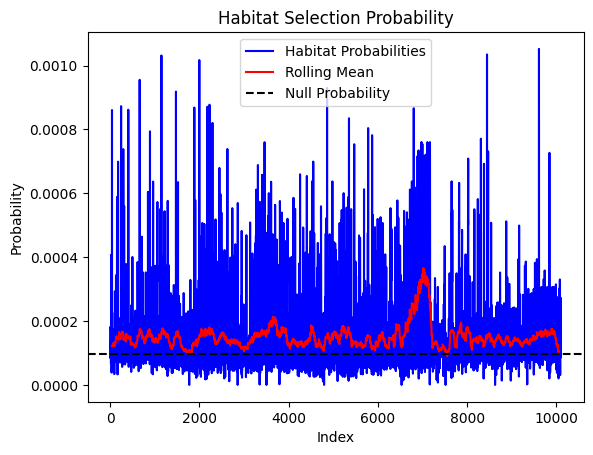

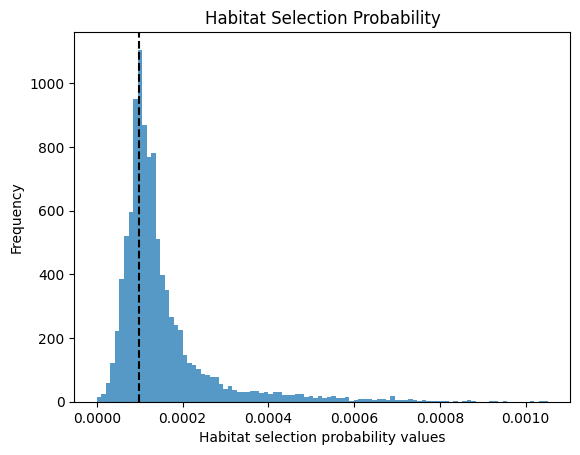

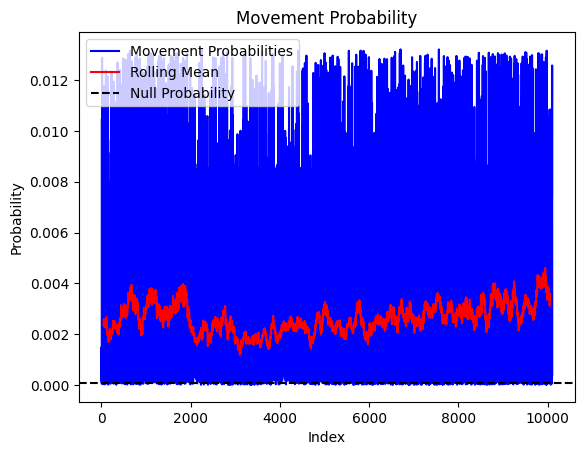

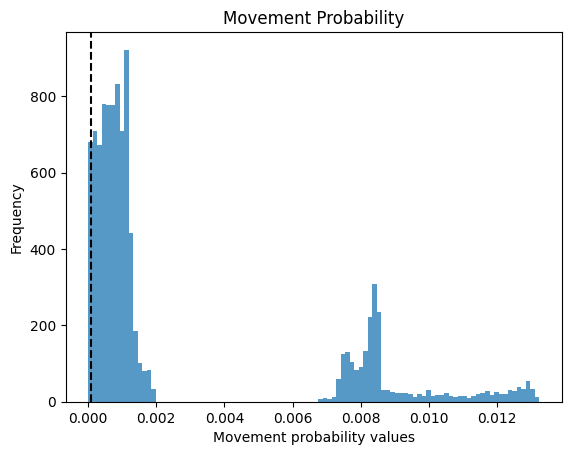

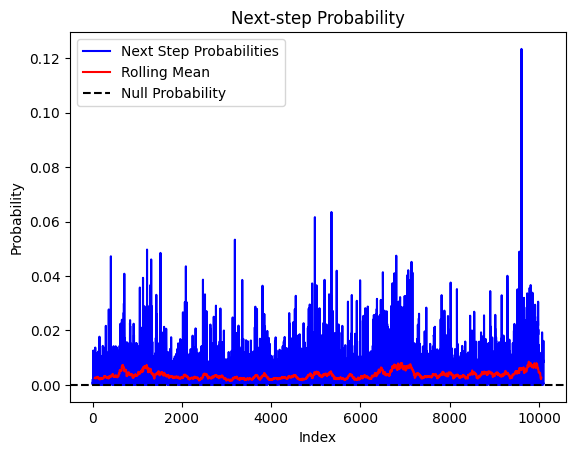

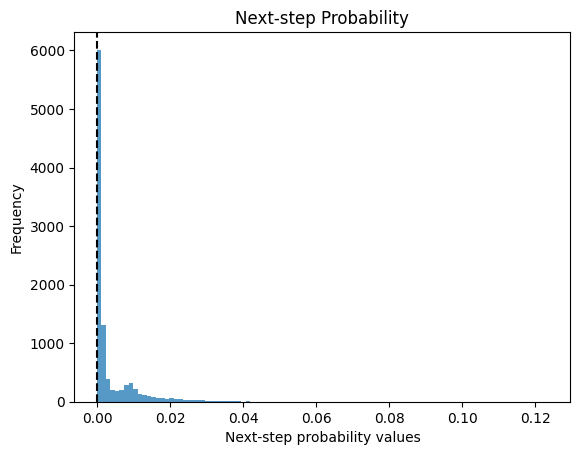

In [108]:
# Plot the habitat probs through time as a line graph
plt.plot(habitat_probs[habitat_probs > 0], color='blue', label='Habitat Probabilities')
plt.plot(rolling_mean_habitat[rolling_mean_habitat > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Habitat Selection Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_habitat_probs.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.hist(habitat_probs[habitat_probs > 0], bins=100, alpha=0.75)
plt.axvline(x=null_prob, color='black', linestyle='--', label='Null Probability')
plt.title('Habitat Selection Probability')
plt.xlabel('Habitat selection probability values')
plt.ylabel('Frequency')
plt.show()
plt.savefig(f'{output_dir}/id{buffalo_id}_habitat_probs_hist.png', dpi=300, bbox_inches='tight')
plt.close()  # Close the figure to free memory

# Plot the movement probs through time as a line graph
plt.plot(move_probs[move_probs > 0], color='blue', label='Movement Probabilities')
plt.plot(rolling_mean_movement[rolling_mean_movement > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Movement Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_movement_probs.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.hist(move_probs[move_probs > 0], bins=100, alpha=0.75)
plt.axvline(x=null_prob, color='black', linestyle='--', label='Null Probability')
plt.title('Movement Probability')
plt.xlabel('Movement probability values')
plt.ylabel('Frequency')
plt.show()
plt.savefig(f'{output_dir}/id{buffalo_id}_movement_probs_hist.png', dpi=300, bbox_inches='tight')
plt.close()  # Close the figure to free memory

# Plot the next step probs through time as a line graph
plt.plot(next_step_probs[next_step_probs > 0], color='blue', label='Next Step Probabilities')
plt.plot(rolling_mean_next_step[rolling_mean_next_step > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Next-step Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_next_step_probs.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.hist(next_step_probs[next_step_probs > 0], bins=100, alpha=0.75)
plt.axvline(x=null_prob, color='black', linestyle='--', label='Null Probability')
plt.title('Next-step Probability')
plt.xlabel('Next-step probability values')
plt.ylabel('Frequency')
plt.show()
plt.savefig(f'{output_dir}/id{buffalo_id}_next_step_probs_hist.png', dpi=300, bbox_inches='tight')
plt.close()  # Close the figure to free memory

# Save the probabilities

We can save the probabilities to a csv file to compare with the SSF probabilities.

In [109]:
# Append the probabilities to the dataframe
buffalo_df['habitat_probs'] = habitat_probs
buffalo_df['move_probs'] = move_probs
buffalo_df['next_step_probs'] = next_step_probs

csv_filename = f'{output_dir}/deepSSF_id{buffalo_id}_n{len(test_data)}_{today_date}.csv'
print(csv_filename)
buffalo_df.to_csv(csv_filename, index=True)

/content/drive/MyDrive/GitHub/deepSSF/Python/outputs/model_training/id2005_polar_fcn_mixture_7_2025-05-01/deepSSF_id2005_n10103_2025-05-01.csv
